# Olympics

This is a historical dataset on the modern Olympic Games, from Athens 1896 to Rio 2016. Each row consists of an individual athlete competing in an Olympic event and which medal was won (if any).

## Data Dictionary

|Column   |Explanation                   |
| ------- | ---------------------------- |
|id       |Unique number for each athlete |
|name     |Athlete's name                 |
|sex      |Female (F) or Male (M)                         |
|age      |Age of the athlete (years)                        |
|height   |In centimeters                 |
|weight   |In kilograms                   |
|team     |Team name                    |
|noc      |National Olympic Committee 3 (abbreviation)   |
|games    |Which Olympic Games by Year and Season                |
|year     |Year                       |
|season   |Summer or Winter               |
|city     |Host city                      |
|sport    |Sport                          |
|event    |Event                          |
|medal    |Gold, Silver, Bronze, or NA    |

[Source](https://www.kaggle.com/heesoo37/120-years-of-olympic-history-athletes-and-results) and [license](https://creativecommons.org/publicdomain/zero/1.0/) of the dataset.
The dataset is a consolidated version of data from www.sports-reference.com.

## Don't know where to start?

**Challenges are brief tasks designed to help you practice specific skills:**

- 🗺️ **Explore**: In which year and city did the Netherlands win the highest number of medals in their history?
- 📊 **Visualize**: Create a plot visualizing the relationship between the number of athletes countries send to an event and the number of medals they receive.
- 🔎 **Analyze**: In which sports does the height of an athlete increase their chances of earning a medal?

**Scenarios are broader questions to help you develop an end-to-end project for your portfolio:**

You are working as a data analyst for an international judo club. The owner of the club is looking for new ways to leverage data for competition. One idea they have had is to use past competition data to estimate the threat of future opponents. They have provided you with a dataset of past Olympic data and want to know whether you can use information such as the height, weight, age, and national origin of a judo competitor to estimate the probability that they will earn a medal.

You will need to prepare a report that is accessible to a broad audience. It should outline your steps, findings, and conclusions.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statistics
import math
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import re
import itertools
from scipy import stats
from collections import Counter
from matplotlib.lines import Line2D
from datetime import date, timedelta, datetime
from matplotlib.patches import Ellipse
from matplotlib.text import OffsetFrom


from sklearn import linear_model
from sklearn import model_selection
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
#import statsmodels.formula.api from smf

import warnings
warnings.filterwarnings('ignore')

#get a color palette
#seaborn_palette = sns.color_palette()

This extensive dataset contains a plethora of information with a wide variety of values. The range of time in which this data accounts for implies that various characteristics of the Olympic Games will have evolved greatly. Therefore, some characteristics seen in the early 1900s may not be prevalent in the early 2000s, & vice versa. This could make certain analyses difficult if there are only a handful of values for certain columns. 

Additionally, standards & regulations surrounding the Games may have changed. For example, an age limit may have been imposed at a certain time. Different games may have changed due to safety precautions or desires to alter how it is played expressed from the athletes & others involved.

All this to say, there are important considerations to weigh depending on what sorts of analyses are ultimately performed. How does the evolution of the Olympic Games & surrounding circumstances influence how various parameters change over the time range of the dataset? Such a question emphasizes how various analyses may be multifaceted.

# Cleaning & Inspecting Data

In [2]:
orig_df = pd.read_csv("athlete_events.csv.gz")
#pd.read_csv("athlete_events.csv")
display(orig_df.shape)
display(orig_df.head(100))


(271116, 15)

,id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,32,Olav Augunson Aarnes,M,23.0,NaN,NaN,Norway,NOR,1912 Summer,1912,Summer,Stockholm,Athletics,Athletics Men's High Jump,NaN
96,33,Mika Lauri Aarnikka,M,24.0,187.0,76.0,Finland,FIN,1992 Summer,1992,Summer,Barcelona,Sailing,Sailing Men's Two Person Dinghy,NaN
97,33,Mika Lauri Aarnikka,M,28.0,187.0,76.0,Finland,FIN,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Men's Two Person Dinghy,NaN
98,34,Jamale (Djamel-) Aarrass (Ahrass-),M,30.0,187.0,76.0,France,FRA,2012 Summer,2012,Summer,London,Athletics,"Athletics Men's 1,500 metres",NaN


This dataset has 271,116 rows & 15 columns. Note that there are 271,116 observations rather than 271,116 different athletes.

In [3]:
#get data types & # null values of each column
display(orig_df.info())
orig_df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      271116 non-null  int64  
 1   name    271116 non-null  object 
 2   sex     271116 non-null  object 
 3   age     261642 non-null  float64
 4   height  210945 non-null  float64
 5   weight  208241 non-null  float64
 6   team    271116 non-null  object 
 7   noc     271116 non-null  object 
 8   games   271116 non-null  object 
 9   year    271116 non-null  int64  
 10  season  271116 non-null  object 
 11  city    271116 non-null  object 
 12  sport   271116 non-null  object 
 13  event   271116 non-null  object 
 14  medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


None

id             0
name           0
sex            0
age         9474
height     60171
weight     62875
team           0
noc            0
games          0
year           0
season         0
city           0
sport          0
event          0
medal     231333
dtype: int64

Four different columns have null values. For the 'medal' column, these null values simply indicate that no medal was awarded to that specific athlete assuming that there were no errors when this dataset was constructed. Of the 271,116 observations, 231,333 (about 85%) did not win a medal. 
For the 'age,' 'height,' & 'weight' columns, there are several null values that are missing. For 'age,' 9,474 observations (~ 3.5%) do not have an age. For 'height,' 60,171 observations (~ 22%) do not have a height. For 'weight,' 62,875 observations (23%) do not have a weight. Of course, these missing values are inconvenient but they can be worked around for the most part. For example, the null values of each of these columns can be imputed with the mean or median value of their respective column.

The data type of multiple columns can be changed to more appropriate types. For example, 'age,' 'height,' & 'weight' could possibly be converted to integers; however, this cannot be done if there are null (or other) values that cannot inherently be changed to a numerical data type (e.g. the value "unknown" cannot be changed to a numerical data type because it is not inherently tied to any numerical value). Other non-numerical columns that don't have many unique values could be converted to categorical features, such as sex, team, season, medal, or others.

The original dataset has a memory usage of 31.0+ MB.

In [4]:
#check some numerical columns to see if any values do not end in 0 -- are not whole numbers
display(orig_df[[str(orig_df['weight'][x])[-1] != '0' for x in orig_df.index]].dropna(subset=['weight']))


,id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal
30,11,Jorma Ilmari Aalto,M,22.0,182.0,76.5,Finland,FIN,1980 Winter,1980,Winter,Lake Placid,Cross Country Skiing,Cross Country Skiing Men's 30 kilometres,NaN
32,13,Minna Maarit Aalto,F,30.0,159.0,55.5,Finland,FIN,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,NaN
33,13,Minna Maarit Aalto,F,34.0,159.0,55.5,Finland,FIN,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,NaN
507,282,Hadi Abdul Jabbar,M,30.0,180.0,117.5,Iraq,IRQ,1960 Summer,1960,Summer,Roma,Weightlifting,Weightlifting Men's Heavyweight,NaN
508,282,Hadi Abdul Jabbar,M,34.0,180.0,117.5,Iraq,IRQ,1964 Summer,1964,Summer,Tokyo,Weightlifting,Weightlifting Men's Heavyweight,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268685,134418,Zhan Xugang,M,30.0,170.0,72.5,China,CHN,2004 Summer,2004,Summer,Athina,Weightlifting,Weightlifting Men's Middleweight,NaN
269678,134951,Marian Zieliski,M,26.0,160.0,63.5,Poland,POL,1956 Summer,1956,Summer,Melbourne,Weightlifting,Weightlifting Men's Featherweight,Bronze
269679,134951,Marian Zieliski,M,30.0,160.0,63.5,Poland,POL,1960 Summer,1960,Summer,Roma,Weightlifting,Weightlifting Men's Lightweight,NaN
269680,134951,Marian Zieliski,M,34.0,160.0,63.5,Poland,POL,1964 Summer,1964,Summer,Tokyo,Weightlifting,Weightlifting Men's Lightweight,Bronze


The cell above indicated that the columns 'age' & 'height' do not have any non-whole numbers. Therefore, these columns can be converted from floats to integers. On the other hand, for the 'weight' column, there are instances in which there are non-whole numbers, specifically half-kilograms (e.g. 72.5 kg). As such, 'weight' should remain as a float.
Unfortunately, given that there are null values across these three columns, it prevents them from being converted to an integer data type.

In [5]:
#check to see if 'id' has duplicates to determine if athletes have multiple observations -- YES
    #display(orig_df[orig_df.duplicated(subset=['id'])])
#determine # unique athletes in dataset
    #display(len(orig_df['id'].unique()))


There are several athletes who each account for multiple rows in the dataset. There are 135,571 unique athletes in the dataset.

In [6]:
#understand ranges & distributions of values for each parameter;
    #skip 'id' because it is just an identifier for each individual
    #skip 'name' bc it is not useful here -- obviously, there will be many unique observations in the dataset
for i in orig_df.columns[2:]:
    display(orig_df[i].value_counts(dropna=False).sort_index())

sex
F     74522
M    196594
Name: count, dtype: int64

age
10.0       1
11.0      13
12.0      39
13.0     187
14.0     837
        ... 
84.0       1
88.0       3
96.0       1
97.0       1
NaN     9474
Name: count, Length: 75, dtype: int64

height
127.0        7
128.0        1
130.0        2
131.0        2
132.0        9
         ...  
220.0        6
221.0        4
223.0        4
226.0        3
NaN      60171
Name: count, Length: 96, dtype: int64

weight
25.0         6
28.0        14
30.0        42
31.0        23
32.0        41
         ...  
182.0        2
190.0        1
198.0        1
214.0        2
NaN      62875
Name: count, Length: 221, dtype: int64

team
30. Februar                2
A North American Team      4
Acipactli                  3
Acturus                    2
Afghanistan              126
                        ... 
Zambia                   183
Zefyros                    2
Zimbabwe                 309
Zut                        3
rn-2                       5
Name: count, Length: 1184, dtype: int64

...

season
Summer    222552
Winter     48564
Name: count, dtype: int64

city
Albertville                3436
Amsterdam                  4992
Antwerpen                  4292
Athina                    15556
Atlanta                   13780
Barcelona                 12977
Beijing                   13602
Berlin                     6506
Calgary                    2639
Chamonix                    460
Cortina d'Ampezzo          1307
Garmisch-Partenkirchen      895
Grenoble                   1891
Helsinki                   8270
Innsbruck                  3639
Lake Placid                2098
Lillehammer                3160
London                    22426
Los Angeles               12423
Melbourne                  4829
Mexico City                8588
Montreal                   8641
Moskva                     7191
Munich                    10304
Nagano                     3605
Oslo                       1088
Paris                      7169
Rio de Janeiro            13688
Roma                       8119
Salt Lake City             4109
Sankt Moritz               1657
Sap

sport
Aeronautics            1
Alpine Skiing       8829
Alpinism              25
Archery             2334
Art Competitions    3578
                    ... 
Tug-Of-War           170
Volleyball          3404
Water Polo          3846
Weightlifting       3937
Wrestling           7154
Name: count, Length: 66, dtype: int64

event
Aeronautics Mixed Aeronautics                        1
Alpine Skiing Men's Combined                       569
Alpine Skiing Men's Downhill                      1164
Alpine Skiing Men's Giant Slalom                  1535
Alpine Skiing Men's Slalom                        1593
                                                  ... 
Wrestling Women's Flyweight, Freestyle              68
Wrestling Women's Heavyweight, Freestyle            64
Wrestling Women's Light-Heavyweight, Freestyle      18
Wrestling Women's Lightweight, Freestyle            67
Wrestling Women's Middleweight, Freestyle           68
Name: count, Length: 765, dtype: int64

medal
Bronze     13295
Gold       13372
Silver     13116
NaN       231333
Name: count, dtype: int64

In [7]:
#Check some interesting/strange/unusual values
#display(orig_df[orig_df['team'] == 'rn-2'])
#display(orig_df[(orig_df.noc == 'FIN') & (orig_df['games'] == '1912 Summer')].sort_values(by='team'))
#display(orig_df[orig_df['noc'] == 'AHO'])

It appears that the 'sport' & 'event' columns are semantically related in that the value of 'event' begins with the corresponding 'sport' for each row. It doesn't seem necessary to change the former by removing the 'sport' element, but it is interesting to point out.

The 'team' & 'noc' columns are often related but do not have the exact same meaning. For example, some athlete may have a 'team' value indicating a specific country, & their 'noc' value is the abbreviation for said country. On the other hand, an athlete's 'team' value doesn't relate in any way to their 'noc' value. 
For example, two Austrian athletes who participated in the 1952 Olympic Games are from the "30. Februar" team; however, 236 other Austrian athletes who competed in the same Games are from the "Austria" team. There doesn't seem to be any additional information that indicates the reasoning behind these differences.

There are several 'team' values that do not make any intuitive sense nor do they relate to their corresponding 'noc' value, including "30. Februar," "rn-2," "Acipactli," to name a few. With such data points, it makes it more difficult to discern if any data points are any kind of error or mistake. The length of the dataset makes searching for such errors more time consuming as well.

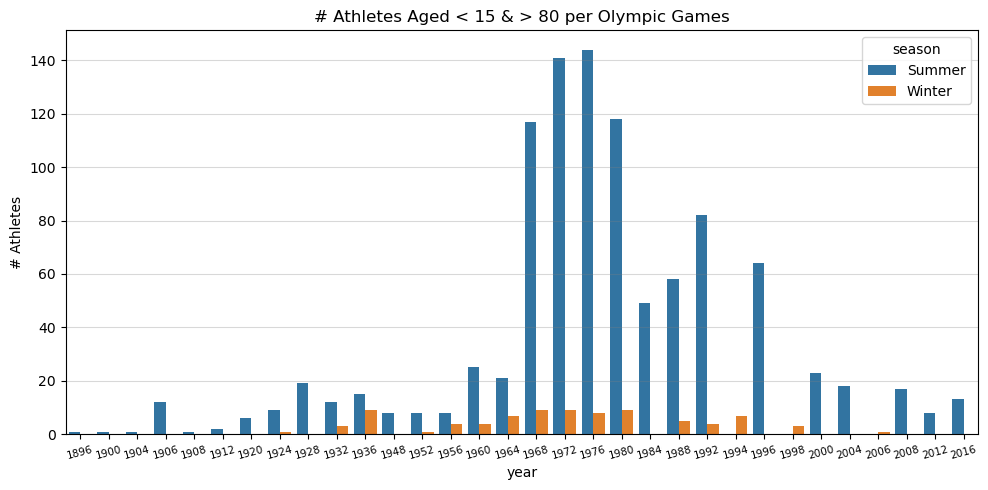

In [8]:
#Check some interesting/strange/unusual values

#display(orig_df[(orig_df['age'] < 15) | (orig_df['age'] > 80)]['year'].value_counts(dropna=False).sort_index())
plt.figure(figsize=(10,5))
sns.countplot(data=orig_df[(orig_df['age'] < 15) | (orig_df['age'] > 80)], x='year', hue='season')
plt.xticks(fontsize=7.5, rotation=15)
plt.ylabel('# Athletes')
plt.title('# Athletes Aged < 15 & > 80 per Olympic Games')
plt.grid(axis='y',alpha=0.3,color='gray')
plt.tight_layout();


Note that in the plot above, the ticks along the horizontal axes--representing the year--are not evenly spaced; they do not always follow the same pattern. Sometimes they skip two years, four years, or some other difference. For example, this dataset does not have any data between 1946 & 1948, likely because of World War II.

Other interesting values based on this brief information includes some striking ages. Particularly, there are some individuals who participated in the Games at the ages of 10, 96, & 97. Intuitively, modern athletes seem incredibly unlikely to participate in the Olympics at such ages, so these athletes probably competed longer ago. This mindset would hypothesize that the distribution of 'age' likely thins over time. 
Upon investigating this hypothesis, it was contradicted. The plot above displays the number of athletes, aged either less than 15 or more than 80, who participated in the Games. The data is partitioned by the two seasons. These unusual ages are considerably more present in the summer games than in the winter games. Rather than participating in the earlier years of the dataset, most of these people in these age ranges participated in the years between 1960-1996, which is closer to the most recent data than the oldest data. Such a finding could serve as motivation for further research as to why this is the case.

10.0

97.0

25.454776204227084

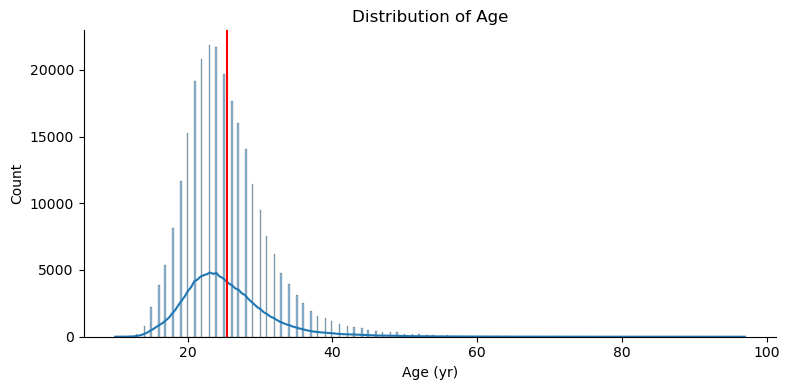

In [9]:
#FOR NULLS, need to figure out if distributions of ['age','height','weight'] are skewed bc it will determine if nulls are...
    # imputed with mean/median
    #For each of these 3 parameters, swap out when computing code below.

data_nulls_not_duped = orig_df.drop_duplicates(keep="first").reset_index(drop=True)[['age','height','weight']]
data_nulls_not_duped_melted = data_nulls_not_duped.melt(value_vars=['age','height','weight'])

#get the min, max, & mean value of the parameter
display(data_nulls_not_duped['age'].min(), data_nulls_not_duped['age'].max(), data_nulls_not_duped['age'].mean())
#plot the distribution of the parameter
ax1 = sns.displot(data=data_nulls_not_duped, x='age', kde=True, height=4, aspect=2)
#make a vertical line indicating the mean value of the parameter
plt.axvline(data_nulls_not_duped['age'].mean(), color='red')

#edit plot details
plt.title(f"Distribution of Age")
plt.xlabel('Age (yr)')
plt.tight_layout();


Regarding the 'age,' 'height,' & 'weight' columns, which have null values, the solution involved imputing the missing values with either the mean or median value of the respective column. Ultimately, the mean is the better statistic when the distribution of the data (or that parameter) is normal--evenly distributed--whereas the median is more appropriate when the distribution of the data is skewed. Skewness is the tendency for the values to be more popular at either the lower or upper two ends of the horizontal axis. The cell above explored the distributions of these three variables to determine if they are skewed or are normally distributed. The vertical red line indicates the mean value of the respective parameter. The data used for these distributions does not include duplicate observations.

For 'age,' the data is considerably distributed towards the lower end of the horizontal axis (positively skewed). Also, the mean 'age' is greater than the age of the peak of the 'age' distribution. For 'height,' the data has a fairly normal distribution & the mean is very close to the middle of the distribution. For 'weight,' the data is considerably distributed towards the lower end of the horizontal axis (positively skewed). The mean is very close to the weight of the peak of the 'weight' distribution, maybe slightly greater than the peak value.

So, for 'age' & 'weight,' the median should be used when imputing for their null values. For height, the mean should be used. Given that there are duplicate observations in the dataset, these imputations should wait until after the duplicate instances are dealt with.

In [10]:
#Change data types of some columns
#make a copy of the original dataset so as not to modify it
duped_data = orig_df.copy()

#DEAL WITH NON-NUMERICAL COLUMNS
#convert the 'sex' column to a categorical data type
duped_data['sex'] = duped_data['sex'].astype('category')
#convert the 'noc' column to a categorical data type
duped_data['noc'] = duped_data['noc'].astype('category')
#convert the 'games' column to a categorical data type
duped_data['games'] = duped_data['games'].astype('category')
#convert the 'season' column to a categorical data type
duped_data['season'] = duped_data['season'].astype('category')
#convert the 'city' column to a categorical data type
duped_data['city'] = duped_data['city'].astype('category')
#convert the 'sport' column to a categorical data type
duped_data['sport'] = duped_data['sport'].astype('category')
#convert the 'event' column to a categorical data type
duped_data['event'] = duped_data['event'].astype('category')

#for the 'medal' column, first impute null values w/"None"
duped_data['medal'] = duped_data['medal'].fillna('None')
#convert the 'medal' column to a categorical data type
duped_data['medal'] = pd.Categorical(duped_data['medal'], categories=['Gold','Silver','Bronze','None'], ordered=True)

display(duped_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype   
---  ------  --------------   -----   
 0   id      271116 non-null  int64   
 1   name    271116 non-null  object  
 2   sex     271116 non-null  category
 3   age     261642 non-null  float64 
 4   height  210945 non-null  float64 
 5   weight  208241 non-null  float64 
 6   team    271116 non-null  object  
 7   noc     271116 non-null  category
 8   games   271116 non-null  category
 9   year    271116 non-null  int64   
 10  season  271116 non-null  category
 11  city    271116 non-null  category
 12  sport   271116 non-null  category
 13  event   271116 non-null  category
 14  medal   271116 non-null  category
dtypes: category(8), float64(3), int64(2), object(2)
memory usage: 17.1+ MB


None

Multiple columns, both numerical & non-numerical, were modified in the cell above. First, the original dataset was copied to ensure that it would not be modified. 
For the non-numerical columns:
- Converting the 'sex' column from an object to a category changed the memory usage of the dataset from 31.0+ MB to 29.2+ MB. - - Converting the 'noc' column from an object to a category changed the memory usage of the dataset from 29.2+ MB to 27.7+ MB. - - Converting the 'games' column from an object to a category changed the memory usage of the dataset from 27.7+ MB to 25.9+ MB. - Converting the 'season' column from an object to a category changed the memory usage of the dataset from 25.9+ MB to 24.1+ MB. - Converting the 'city' column from an object to a category changed the memory usage of the dataset from 24.1+ MB to 22.2+ MB. - - Converting the 'sport' column from an object to a category changed the memory usage of the dataset from 22.2+ MB to 20.4+ MB. - Converting the 'event' column from an object to a category changed the memory usage of the dataset from 20.4+ MB to 18.9+ MB. - For the 'medal' column, the null values were first imputed with the value "None." Then, the column was converted from an object to a category, changing the memory usage of the dataset from 18.9+ MB to 17.1+ MB.

The memory usage of the modified dataset is 17.1+ MB. The 'age,' 'height,' & 'weight' columns still have missing/null values that need to be resolved.

In [11]:
#Search for duplicates
#collect athletes with duplicate (any kind of duplicate) entries
duplicate_athletes = duped_data[duped_data.duplicated(keep=False)]['name'].value_counts(dropna=False)
    #display(duplicate_athletes)

#drop true duplicates -- entries that have the same value across every parameter
data = duped_data.drop_duplicates(keep="first").reset_index(drop=True)
    #display(data)

#collect athletes with duplicate entries (now without true duplicates)
non_duped_athletes = data[data.duplicated(subset=['id'], keep=False)]
display(non_duped_athletes['name'].value_counts(dropna=False))

#impute median for missing values of 'age', & change data type to 'int'
data['age'] = data['age'].fillna(data['age'].median()).astype('int')
#impute mean for missing values of 'height', & change data type to 'int'
data['height'] = data['height'].fillna(data['height'].mean()).astype('int')
#impute median for missing values of 'weight'
data['weight'] = data['weight'].fillna(data['weight'].median())

#check memory usage of modified dataset
    #display(data.info())

name
Heikki Ilmari Savolainen     39
Joseph "Josy" Stoffel        38
Ioannis Theofilakis          36
Takashi Ono                  32
Alexandros Theofilakis       32
                             ..
Jalal Khan                    2
Lawrence G. "Laurie" Khan     2
Mirza Khan                    2
Mohammad Mohammad Khan        2
Tomasz Ireneusz ya            2
Name: count, Length: 57230, dtype: int64

When searching for duplicate data points, there are several possibilities that certain parameters have the same value, but such instances are not relevant for these purposes. For example, if an athlete has multiple entries where the only parameter that differs is 'sport,' those entries are not true duplicates. A true duplicate would be when multiple entries have the same value for every parameter.

There are 515 unique athletes that have true duplicate entries in the original dataset, & they totaled 1997 true duplicates. After dropping true duplicates, the number of rows decreases from 271,116 to 269,731. 
In this modified dataset, there are 57,230 unique athletes that have at least one duplicate entry (non-true duplicates), totalling 191,556 duplicate observations. Note that in the original dataset, there are 135,571 unique athletes, implying that about 42% of them account for multiple entries. Most of these duplicate entries can be attributed to athletes participating in multiple Olympic Games &/or participating in multiple different events.

After duplicates were removed, the null values in the 'age,' 'height,' & 'weight' columns were imputed with either the mean or median value of each column. The data type of the 'age' & 'height' columns was changed from floats to integers, reducing the memory usage of this modified dataset to 15.0+ MB. With true duplicates eliminated, the dataset can be properly analyzed.

# Analysis I
In which year and city did the Netherlands win the highest number of medals in their history?

Before going about answering this question, it important to understand how the dataset relates to these specified quantities. Firstly, there are two variables that can possibly refer to the Netherlands: 'team' & 'noc'; however, there are multiple different teams and national olympic committees that are associated with the Netherlands, so it is important to search for & include any such observations. Of course, the analysis for this prompt could simply search only for the "Netherlands" team, but including others that are also associated with the Netherlands could provide additional insight as to the Olympic-Games successes of this country & its people.

Additionally, it is important to point out that in modern times, the Olympics take place every two years, alternating between the Winter & Summer games; each occurs every fourth year. In the past, both Games sometimes occurred in the same year. As such, the response to this prompt could be biased towards years in which both of the two Olympic Games took place. Of course, the number of events also influences the opportunities for medals to be won. 
A better solution could involve answering this prompt with respect to the season &/or whether or not both Games (seasons) took place in the same year. For example, the response could involve a result for the entire dataset, for years in which only one of the Games took place, for years in which both Games took place, & for years where only one of the Summer/Winter Games took place.

Reference [_Wikipedia_](https://en.wikipedia.org/wiki/List_of_Olympic_Games_host_cities) for a clear picture of when each Olympic Game occurred.

In [12]:
#check to see how many Games took place each year
year_games_city = data[['year','season','city']].drop_duplicates().reset_index(drop=True).sort_values(['year','season','city'])
num_games_yr = year_games_city['year'].value_counts().reset_index().rename(columns={'count':'# Games'})

#change 1956 to have 2 Games -- initially comes up as three because the Summer Games were held in 2 different venues
num_games_yr.loc[num_games_yr['year'] == 1956, '# Games'] = 2
num_games_yr = num_games_yr.sort_values(['# Games','year'], ascending=[False,True]).reset_index(drop=True)

display(num_games_yr)


,year,# Games
0,1924,2
1,1928,2
2,1932,2
3,1936,2
4,1948,2
5,1952,2
6,1956,2
7,1960,2
8,1964,2
9,1968,2


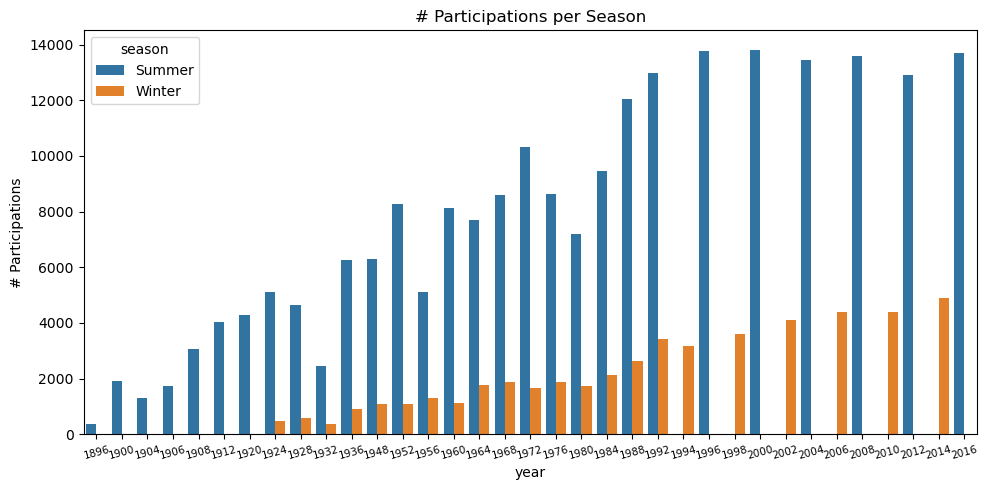

In [13]:
#Make a plot to illustrate what years both seasonal Games took place (or did not)

plt.figure(figsize=(10,5))
sns.countplot(data=data, x='year', hue='season')
plt.xticks(fontsize=7.5, rotation=15)
plt.ylabel('# Participations')
plt.title('# Participations per Season')
plt.tight_layout();

The Winter Olympics did not start until 1924. From 1924 through 1992, both the Summer & Winter Olympics occurred in the same year (16 times). Afterwards, they occurred separately. Note that in 1956, the Summer Olympics were held in two locations, resulting in three separate Olympic venues. There are several instances & periods in which the Olympics did not take place due to international conflicts or issues, such as the World Wars.

'There are 28 unique Olympic teams associated with the Netherlands in the dataset.'

'There are 5860 unique entries associated with the Netherlands in the dataset.'

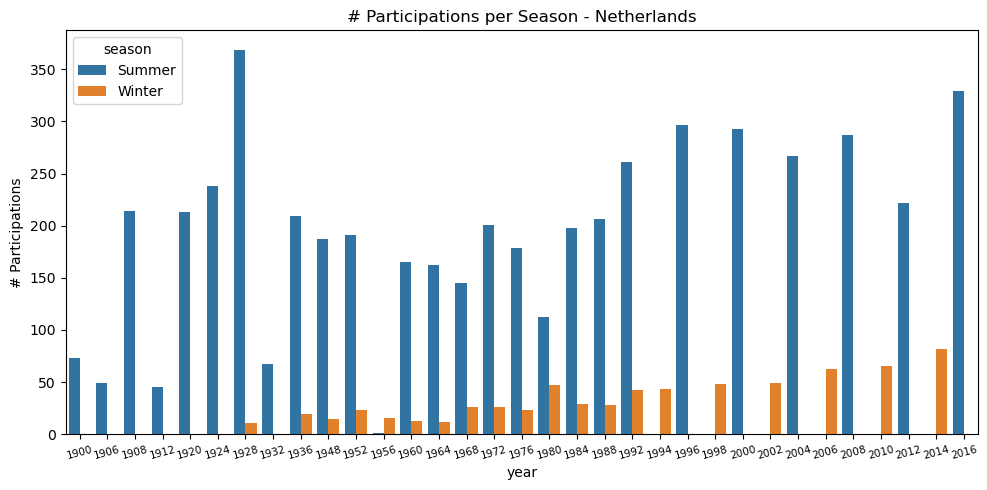

In [14]:
#Search for any & all things "Netherlands"

#get data associated w/'team's containing "Netherlands" or w/'noc' = 'NED'
Netherlands_data = data[(data['team'].str.contains('Netherland')) | (data['noc'] == 'NED')]
#display(Netherlands_data)
    #returns 5860 results
#get associated teams
Netherlands_NED_teams = Netherlands_data['team'].value_counts(dropna=False)
display(f'There are {len(Netherlands_NED_teams)} unique Olympic teams associated with the Netherlands in the dataset.')
display(f'There are {Netherlands_NED_teams.sum()} unique entries associated with the Netherlands in the dataset.')

#check to see what other 'noc' values are associated with this data
    #display(Netherlands_data['noc'].value_counts(dropna=False))

#make a plot to illustrate what years both seasonal Games took place (or did not) for the Netherlands data
plt.figure(figsize=(10,5))
sns.countplot(data=Netherlands_data, x='year', hue='season')
plt.xticks(fontsize=7.5, rotation=15)
plt.ylabel('# Participations')
plt.title('# Participations per Season - Netherlands')
plt.tight_layout();

When filtering for the Netherlands, there are many different teams & national olympic committees that are associated with this country.
- In this dataset, the three-digit ISO code ('noc') for the Netherlands is "NED."
- The only other 'noc' value associated with the Netherlands is "AHO," which corresponds to the Netherlands Antilles 'team' -- a constituent country of the Kingdom of the Netherlands consisting of several island territories located in the Caribbean Sea.
- There are 28 unique Olympic teams associated with the Netherlands which total 5860 unique entries in the dataset. One team, "Univ. of Brussels," corresponds to 11 unique entries in the dataset, only one of which is associated with the Netherlands data.

From the figure above, there were 33 distinct years in which these athletes participated in the Olympics of the 35 listed in the dataset. The Summer & Winter Olympics took place in 27 & 20 of these years respectively.

In [15]:
#Identify what years athletes associated with the Netherlands competed in the Olympics & did not
Netherlands_years = set(Netherlands_data['year'])
    #display(Netherlands_years)

print("Of the {} different years in which the Olympics occurred in this dataset--between {} & {}--the Netherlands have no \nathletes associated with the years: {}.".format(
            len(set(data['year'])), min(set(data['year'])), max(set(data['year'])), 
            set(data['year']).symmetric_difference(Netherlands_years)))


Of the 35 different years in which the Olympics occurred in this dataset--between 1896 & 2016--the Netherlands have no 
athletes associated with the years: {1896, 1904}.


In [16]:
#Count number of medals won per year in Netherlands data. Include column indicating number of possible opportunities a medal...
    #could've been won to help as a normalizer.

#By each 'medal' value:
#groupby year & medal, & count
yearly_NED_med_count = Netherlands_data.groupby(['year','medal']).count().iloc[:,0].reset_index()
#rename columns
yearly_NED_med_count = yearly_NED_med_count.rename(columns={'id':'# Medals'})
#add column indicating # times athletes participated in each year (# possible opportunities for a medal)
yearly_NED_med_count['# Participations'] = [i for i in yearly_NED_med_count.groupby('year')['# Medals'].sum().values for 
                                            j in range(0,4)]
#rearrange the dataframe
yearly_NED_med_count = yearly_NED_med_count.pivot(index=['year','# Participations'], columns='medal', values='# Medals').reset_index()

#sum total # medals won each year
yearly_NED_med_count['Total Medals'] = yearly_NED_med_count['Gold'] + yearly_NED_med_count['Silver'] + yearly_NED_med_count['Bronze']

#reorganize columns
yearly_NED_med_count = yearly_NED_med_count[['year','Gold','Silver','Bronze','None','Total Medals','# Participations']]


In [17]:
#Make medal-to-participation ratios, indicating how many participations it takes for a medal to be won per year
    #of course, since participations are a discrete variable, these ratios should theoretically be rounded up to the nearest integer
    #need to account for years where there were zero participations -- had to apply calculation in specific conditions to avoid...
        #calculating x/0 ~ inf.

for i in yearly_NED_med_count.index:

    #for years without any medal
    if yearly_NED_med_count.loc[i,'Total Medals'] == 0:
        #for any medal
        yearly_NED_med_count.loc[i,'Medal:Participation Ratio'] = '---'
        #for Gold medals
        yearly_NED_med_count.loc[i,'Gold Medal:Participation Ratio'] = '---'
        #for Silver medals
        yearly_NED_med_count.loc[i,'Silver Medal:Participation Ratio'] = '---'
        #for Bronze medals
        yearly_NED_med_count.loc[i,'Bronze Medal:Participation Ratio'] = '---'

    #for years without Gold medals
    elif yearly_NED_med_count.loc[i,'Gold'] == 0 and yearly_NED_med_count.loc[i,'Silver'] != 0 and yearly_NED_med_count.loc[i,'Bronze'] != 0:
        #for Gold medals
        yearly_NED_med_count.loc[i,'Gold Medal:Participation Ratio'] = '---'
        #for Silver medals
        yearly_NED_med_count.loc[i, 'Silver Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Silver']).round(2))
        #for Bronze medals
        yearly_NED_med_count.loc[i, 'Bronze Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Bronze']).round(2))
        #for any medal
        yearly_NED_med_count.loc[i, 'Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Total Medals']).round(2))
      
    #for years without Silver medals
    elif yearly_NED_med_count.loc[i,'Silver'] == 0 and yearly_NED_med_count.loc[i,'Gold'] != 0 and yearly_NED_med_count.loc[i,'Bronze'] != 0:
        #for Silver medals
        yearly_NED_med_count.loc[i,'Silver Medal:Participation Ratio'] = '---'
        #for Gold medals
        yearly_NED_med_count.loc[i, 'Gold Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Gold']).round(2))
        #for Bronze medals
        yearly_NED_med_count.loc[i, 'Bronze Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Bronze']).round(2))
        #for any medal
        yearly_NED_med_count.loc[i, 'Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Total Medals']).round(2))
        
    #for years without Bronze medals
    elif yearly_NED_med_count.loc[i,'Bronze'] == 0 and yearly_NED_med_count.loc[i,'Gold'] != 0 and yearly_NED_med_count.loc[i,'Silver'] != 0:
        #for Bronze medals
        yearly_NED_med_count.loc[i,'Bronze Medal:Participation Ratio'] = '---'
        #for Gold medals
        yearly_NED_med_count.loc[i, 'Gold Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Gold']).round(2))
        #for Silver medals
        yearly_NED_med_count.loc[i, 'Silver Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Silver']).round(2))
        #for any medal
        yearly_NED_med_count.loc[i, 'Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Total Medals']).round(2))
    
    #for years without Gold, Silver medals
    elif yearly_NED_med_count.loc[i,'Gold'] == 0 and yearly_NED_med_count.loc[i,'Silver'] == 0:
        #for Gold medals
        yearly_NED_med_count.loc[i,'Gold Medal:Participation Ratio'] = '---'
        #for Silver medals
        yearly_NED_med_count.loc[i,'Silver Medal:Participation Ratio'] = '---'
        #for Bronze medals
        yearly_NED_med_count.loc[i, 'Bronze Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Bronze']).round(2))
        #for any medal
        yearly_NED_med_count.loc[i, 'Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Total Medals']).round(2))
    
    #for years without Gold, Bronze medals
    elif yearly_NED_med_count.loc[i,'Gold'] == 0 and yearly_NED_med_count.loc[i,'Bronze'] == 0:
        #for Gold medals
        yearly_NED_med_count.loc[i,'Gold Medal:Participation Ratio'] = '---'
        #for Bronze medals
        yearly_NED_med_count.loc[i,'Bronze Medal:Participation Ratio'] = '---'
        #for Silver medals
        yearly_NED_med_count.loc[i, 'Silver Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Silver']).round(2))
        #for any medal
        yearly_NED_med_count.loc[i, 'Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Total Medals']).round(2))

    #for years without Silver, Bronze medals
    elif yearly_NED_med_count.loc[i,'Silver'] == 0 and yearly_NED_med_count.loc[i,'Bronze'] == 0:
        #for Silver medals
        yearly_NED_med_count.loc[i,'Silver Medal:Participation Ratio'] = '---'
        #for Bronze medals
        yearly_NED_med_count.loc[i,'Bronze Medal:Participation Ratio'] = '---'
        #for Gold medals
        yearly_NED_med_count.loc[i, 'Gold Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Gold']).round(2))
        #for any medal
        yearly_NED_med_count.loc[i, 'Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Total Medals']).round(2))

    #for years with at least 1 of every medal
    else:
        #for any medal
        yearly_NED_med_count.loc[i, 'Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Total Medals']).round(2))
        #for Gold medals
        yearly_NED_med_count.loc[i, 'Gold Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Gold']).round(2))
        #for Silver medals
        yearly_NED_med_count.loc[i, 'Silver Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Silver']).round(2))
        #for Bronze medals
        yearly_NED_med_count.loc[i, 'Bronze Medal:Participation Ratio'] = "1:~ {}".format(
            (yearly_NED_med_count.loc[i,'# Participations'] / yearly_NED_med_count.loc[i,'Bronze']).round(2))


In [18]:
display(yearly_NED_med_count)

medal,year,Gold,Silver,Bronze,None,Total Medals,# Participations,Medal:Participation Ratio,Gold Medal:Participation Ratio,Silver Medal:Participation Ratio,Bronze Medal:Participation Ratio
0,1900,3,8,16,46,27,73,1:~ 2.7,1:~ 24.33,1:~ 9.12,1:~ 4.56
1,1906,0,1,5,43,6,49,1:~ 8.17,---,1:~ 49.0,1:~ 9.8
2,1908,0,0,16,198,16,214,1:~ 13.38,---,---,1:~ 13.38
3,1912,0,0,26,19,26,45,1:~ 1.73,---,---,1:~ 1.73
4,1920,15,10,25,163,50,213,1:~ 4.26,1:~ 14.2,1:~ 21.3,1:~ 8.52
5,1924,8,1,18,211,27,238,1:~ 8.81,1:~ 29.75,1:~ 238.0,1:~ 13.22
6,1928,20,29,8,323,57,380,1:~ 6.67,1:~ 19.0,1:~ 13.1,1:~ 47.5
7,1932,2,10,1,54,13,67,1:~ 5.15,1:~ 33.5,1:~ 6.7,1:~ 67.0
8,1936,9,7,21,191,37,228,1:~ 6.16,1:~ 25.33,1:~ 32.57,1:~ 10.86
9,1948,8,2,32,160,42,202,1:~ 4.81,1:~ 25.25,1:~ 101.0,1:~ 6.31


The dataframe "yearly_NED_med_count" has various columns that indicate the Olympic success of athletes associated with the Netherlands in terms of winning medals. The 'Gold,' 'Silver,' 'Bronze,' & 'None' columns indicate the number of corresponding medals that were won (or not won) of these athletes each year. The 'Total Medals' sums the number of medals earned. The '# Participations' column indicates how many opportunities these athletes had to possibly win a medal each year.

The last four columns indicate how often a medal (or specific medal) was won by relating it to how many participations there were for each year. For example, in 1900: a medal was won by one of these athletes for approximately every three event participations, a gold medal was won for approximately every 25 event participations, a silver medal was won for approximately every 10 event participations, & a bronze medal was won for approximately eery five event participations. These last four columns offer another metric of Olympic success of these athletes other than simply summing the number of medals won each year.

Figures were made below to illustrate these different measures of Olympic success.

'Olympics in which most medals were won by athletes associated with the Netherlands:'

,games,city
31,2000 Summer,Sydney


'Olympics in which least medals were won by athletes associated with the Netherlands:'

,games,city
111,1956 Winter,Cortina d'Ampezzo
128,1956 Summer,Melbourne
6186,1956 Summer,Stockholm


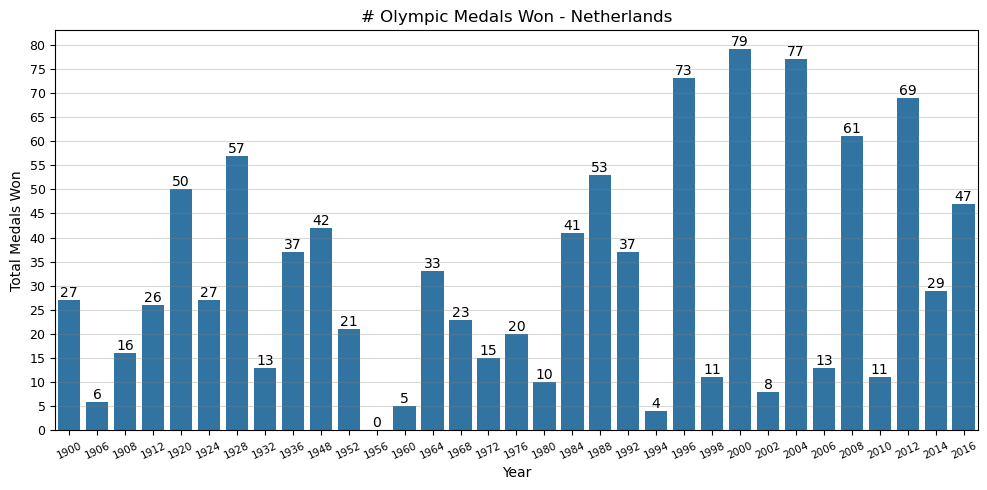

In [19]:
#Make figures illustrating the Olympic success of these athletes associated w/the Netherlands

fig, ax = plt.subplots(figsize=(10,5))
#illustrate # medals won per year
ax1 = sns.barplot(data=yearly_NED_med_count, x='year', y='Total Medals', color=sns.color_palette()[0], ax=ax)
#label each bar w/# medals won
ax1.bar_label(ax1.containers[-1], labels=[f'{num}' for num in yearly_NED_med_count['Total Medals']])

#edit plot details
plt.title('# Olympic Medals Won - Netherlands')
plt.xlabel('Year')
plt.xticks(fontsize=7.5, rotation=25)
plt.ylabel('Total Medals Won')
plt.yticks(ticks=range(0,81,5), fontsize=9)
plt.grid(axis='y', alpha=0.3, color='gray')
plt.tight_layout();

#get the venue & seasons of Olympics in which most & least medals were won
display("Olympics in which most medals were won by athletes associated with the Netherlands:")
display(data[data['year'] == yearly_NED_med_count[yearly_NED_med_count['Total Medals'] == yearly_NED_med_count['Total Medals'].max()]['year'].values[0]][['games','city']].drop_duplicates())

display("Olympics in which least medals were won by athletes associated with the Netherlands:")
display(data[data['year'] == yearly_NED_med_count[yearly_NED_med_count['Total Medals'] == yearly_NED_med_count['Total Medals'].min()]['year'].values[0]][['games','city']].drop_duplicates())


The figure above indicates the number of Olympic medals that these athletes associated with the Netherlands won each year. 1956 was the only year in which these athletes did not win a medal. Funnily enough, 1956 was the only year in which the Olympics were held three times -- the Winter Olympics were held in Cortina, d'Ampezzo, Italy, & the Summer Olympics were held in Melbourne, Australia & Stockholm, Sweden. The most medals were won in 2000 at the Summer Olympics in Sydney, Australia.

Of these 33 years, at least 10 medals were won in all but five (1906, 1956, 1960, 1994, 2002). Note that these figures are not completely impartial because both the Summer & Winter Olympics sometimes occurred for some years, but in other years, only one of the Games took place.

'Olympics in which most medals were won in relation to event participations by athletes associated with the Netherlands:'

,games,city
35,1912 Summer,Stockholm


'Olympics in which least medals were won in relation to event participations by athletes associated with the Netherlands:'

,games,city
111,1956 Winter,Cortina d'Ampezzo
128,1956 Summer,Melbourne
6186,1956 Summer,Stockholm


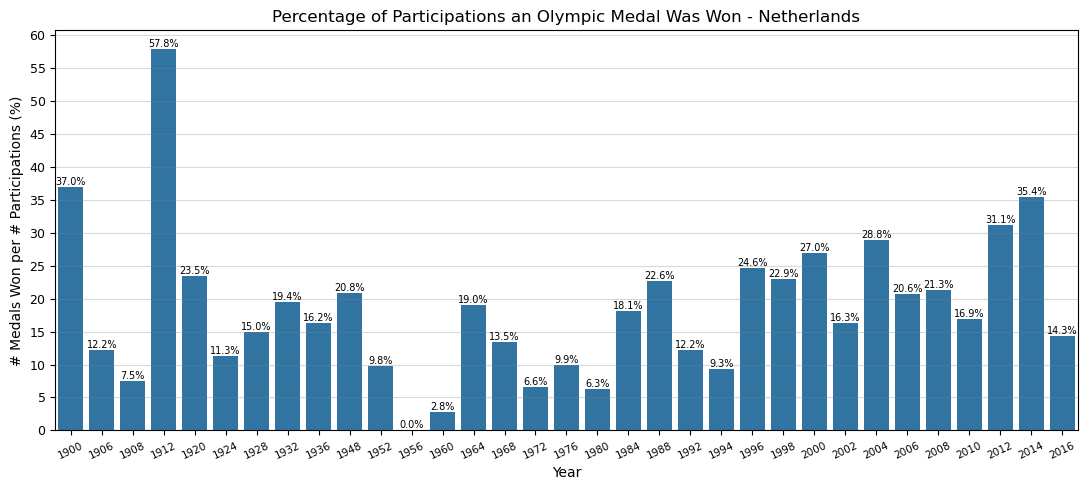

In [20]:
#illustrate medal-to-participation ratio per year
fig, ax = plt.subplots(figsize=(11,5))
sns.barplot(data=yearly_NED_med_count, x='year', y=yearly_NED_med_count['Total Medals'] /  yearly_NED_med_count['# Participations'], 
            color=sns.color_palette()[0], ax=ax)
#label each bar w/# medals won
ax.bar_label(ax.containers[-1], fontsize=7,
             labels=[f'{np.round(perc*100,1)}%' for perc in yearly_NED_med_count['Total Medals'] /  yearly_NED_med_count['# Participations']])
#edit plot details
plt.title('Percentage of Participations an Olympic Medal Was Won - Netherlands')
plt.xlabel('Year')
plt.xticks(fontsize=7.5, rotation=25)
plt.ylabel('# Medals Won per # Participations (%)')
plt.yticks(ticks=np.arange(0.0,0.61,0.05), labels=range(0,61,5), fontsize=9)
plt.grid(axis='y', alpha=0.3, color='gray')
plt.tight_layout();

#get the venue & seasons of Olympics in which most & least medals were won in relation to event participations (1912, 1956)
display("Olympics in which most medals were won in relation to event participations by athletes associated with the Netherlands:")
display(data[data['year'] == 1912][['games','city']].drop_duplicates())

display("Olympics in which least medals were won in relation to event participations by athletes associated with the Netherlands:")
display(data[data['year'] == 1956][['games','city']].drop_duplicates())



This figure displays how many medals were won by these Dutch athletes in relation to the number of participations (opportunities to win a medal) they had. For example, these athletes won 27 medals in 73 participations (~ 37%), which equates to a medal-to-participation ratio of about 1:2.7; a medal was won for approximately every 3 participations. As such, the results of this plot differ significantly to those in the previous plot which displayed how many medals these athletes won each year. This plot supplies a metric more indicative of these athletes' success in terms of winning medals.

The least successful year for these athletes was in 1956, which were held three times*: the Winter Games in Italy & the Summer games in Australia & Sweden. The most successful year was in 1912--Summer Olympics in Stockholm, Sweden--in which these athletes won 26 medals in 45 opportunities (~ 58%!). This was the only year in which the success rate of these Dutch athletes exceeded 40%; however, 1912 saw the third fewest medal-winning opportunities for these athletes.

*Upon researching this year, both the Summer & Winter Olympics took place, the former of which occurred in two separate venues during two different periods. The 1956 Summer Olympics in Melbourne, Australia took place in November-December whereas they 1956 Summer Games in Stockholm, Sweden took place in June. These dates, of course, line up with the time of year in which summer takes place in their respective hemispheres. [_Wikipedia_](https://en.wikipedia.org/wiki/1956_Summer_Olympics) states that "The Olympic equestrian events could not be held in Melbourne due to Australia's strict quarantine regulations, so they were held in Stockholm five months earlier." As such, the analysis deemed that two Olympic Games occurred in 1956 as opposed to three).

As mentioned previously, it is important to consider that the years in which the two seasonal games have occurred throughout the dataset do not follow a constant pattern. The analysis must take this factor into account because more medals were able to (& therefore were more likely) to have been won in years in which both Olympic Games took place than in years in which only one did. Additional analyses were done for subsets of the data that corresponded with both of these two circumstances -- years in which both seasonal Olympic Games were played & years in which only one did.

In [21]:
#Want to determine years based on how many Olympic Games were played (for Netherlands data)
NED_num_games_yr = num_games_yr[num_games_yr['year'].isin(Netherlands_data['year'])].reset_index(drop=True)
    #display(NED_num_games_yr)
    #1 year (1956) in which 3 different venues but 2 Games occurred, 15 years in which 2 occurred (at 2 venues), & ...
        #17 years in which 1 occurred (at 1 venue) -- (33 total years)

#add column indicating how many Games occurred each year
yearly_NED_med_count = yearly_NED_med_count.merge(NED_num_games_yr, how='inner', on='year')
#reorganize columns
yearly_NED_med_count = yearly_NED_med_count[['year','# Games','Gold','Silver','Bronze','None','Total Medals','# Participations',
                                            'Medal:Participation Ratio','Gold Medal:Participation Ratio',
                                            'Silver Medal:Participation Ratio','Bronze Medal:Participation Ratio']]
#display(yearly_NED_med_count)


In [22]:
#Use these subsets of years to filter the "yearly_NED_med_count" dataframe for corresponding years

#for years in which 2 Games occurred (including 1956)
yearly_NED_med_count_2G = yearly_NED_med_count[yearly_NED_med_count['year'].isin(
                                NED_num_games_yr[NED_num_games_yr['# Games'] == 2]['year'])].reset_index(drop=True)
#for years in which 1 Game occurred
yearly_NED_med_count_1G = yearly_NED_med_count[yearly_NED_med_count['year'].isin(
                                NED_num_games_yr[NED_num_games_yr['# Games'] == 1]['year'])].reset_index(drop=True)

#display(yearly_NED_med_count_1G)


In [23]:
#Collect some aggregate statistics for the Netherlands to use as a basis/comparison tool
    #for reference, the term 'Game' or 'Games' refers to an Olympic event; e.g. the 1912 Summer Olympic Games

#make a dictionary summing stats from the yearly statistics
NED_med_count_stats_dict = {'Total Games':yearly_NED_med_count['# Games'].sum(), 'Total Gold':yearly_NED_med_count['Gold'].sum(),
                            'Total Silver':yearly_NED_med_count['Silver'].sum(), 'Total Bronze':yearly_NED_med_count['Bronze'].sum(), 
                            'Total No Medals':yearly_NED_med_count['None'].sum(), 'Total Medals':yearly_NED_med_count['Total Medals'].sum(),
                            'Total Participations':yearly_NED_med_count['# Participations'].sum()}
#convert dictionary to a Dataframe
NED_med_count_stats = pd.DataFrame.from_dict(data=NED_med_count_stats_dict, orient='index').T

NED_med_count_stats['Avg Participations per Game'] = NED_med_count_stats['Total Participations'] / NED_med_count_stats['Total Games']

#add columns indicating how often a medal was won of the number of opportunities
NED_med_count_stats['Medal Won (%)'] = np.round((NED_med_count_stats['Total Medals'] / NED_med_count_stats['Total Participations'])*100,2)
NED_med_count_stats['Gold Medal Won (%)'] = np.round((NED_med_count_stats['Total Gold'] / NED_med_count_stats['Total Participations'])*100,2)
NED_med_count_stats['Silver Medal Won (%)'] = np.round((NED_med_count_stats['Total Silver'] / NED_med_count_stats['Total Participations'])*100,2)
NED_med_count_stats['Bronze Medal Won (%)'] = np.round((NED_med_count_stats['Total Bronze'] / NED_med_count_stats['Total Participations'])*100,2)

#add columns indicating the medal:participation ratio -- how many participations per every medal
NED_med_count_stats['Medal:Participation Ratio'] = "1:~ {}".format(np.round(
        (NED_med_count_stats['Total Participations'] / NED_med_count_stats['Total Medals'])[0], 2))
NED_med_count_stats['Gold Medal:Participation Ratio'] = "1:~ {}".format(np.round(
        (NED_med_count_stats['Total Participations'] / NED_med_count_stats['Total Gold'])[0], 2))
NED_med_count_stats['Silver Medal:Participation Ratio'] = "1:~ {}".format(np.round(
        (NED_med_count_stats['Total Participations'] / NED_med_count_stats['Total Silver'])[0], 2))
NED_med_count_stats['Bronze Medal:Participation Ratio'] = "1:~ {}".format(np.round(
        (NED_med_count_stats['Total Participations'] / NED_med_count_stats['Total Bronze'])[0], 2))

#add couple more columns of aggregate statistics
NED_med_count_stats['Avg Medals per Game'] = NED_med_count_stats['Total Medals'] / NED_med_count_stats['Total Games']
NED_med_count_stats['Avg Golds per Game'] = NED_med_count_stats['Total Gold'] / NED_med_count_stats['Total Games']
NED_med_count_stats['Avg Silvers per Game'] = NED_med_count_stats['Total Silver'] / NED_med_count_stats['Total Games']
NED_med_count_stats['Avg Bronzes per Game'] = NED_med_count_stats['Total Bronze'] / NED_med_count_stats['Total Games']

#reorganize columns?

display(NED_med_count_stats)


,Total Games,Total Gold,Total Silver,Total Bronze,Total No Medals,Total Medals,Total Participations,Avg Participations per Game,Medal Won (%),Gold Medal Won (%),Silver Medal Won (%),Bronze Medal Won (%),Medal:Participation Ratio,Gold Medal:Participation Ratio,Silver Medal:Participation Ratio,Bronze Medal:Participation Ratio,Avg Medals per Game,Avg Golds per Game,Avg Silvers per Game,Avg Bronzes per Game
0,49,287,341,413,4819,1041,5860,119.591837,17.76,4.9,5.82,7.05,1:~ 5.63,1:~ 20.42,1:~ 17.18,1:~ 14.19,21.244898,5.857143,6.959184,8.428571


This data ("NED_med_count_stats") contains several summary statistics of the athletes associated with the Netherlands.

In [24]:
#Add same statistics to the yearly data "yearly_NED_med_count"

#add columns indicating how often a medal was won of the number of opportunities
yearly_NED_med_count['Medal Won (%)'] = np.round((yearly_NED_med_count['Total Medals'] / yearly_NED_med_count['# Participations'])*100,1)
yearly_NED_med_count['Gold Medal Won (%)'] = np.round((yearly_NED_med_count['Gold'] / yearly_NED_med_count['# Participations'])*100,1)
yearly_NED_med_count['Silver Medal Won (%)'] = np.round((yearly_NED_med_count['Silver'] / yearly_NED_med_count['# Participations'])*100,1)
yearly_NED_med_count['Bronze Medal Won (%)'] = np.round((yearly_NED_med_count['Bronze'] / yearly_NED_med_count['# Participations'])*100,1)

#reorganize columns
yearly_NED_med_count = yearly_NED_med_count[['year','# Games','Gold','Silver','Bronze','None','Total Medals','# Participations',
                                'Medal Won (%)','Gold Medal Won (%)','Silver Medal Won (%)','Bronze Medal Won (%)',
                            'Medal:Participation Ratio','Gold Medal:Participation Ratio','Silver Medal:Participation Ratio','Bronze Medal:Participation Ratio',]]

#display(yearly_NED_med_count)


In [25]:
#Determine which years were the most successful in terms of winning medals
    #use "yearly_NED_med_count" & "Netherlands_data" to get necessary data

#display(yearly_NED_med_count)
#display(yearly_NED_med_count.sort_values('Bronze', ascending=False).head(5).reset_index(drop=True))
#display(yearly_NED_med_count.sort_values('Bronze Medal Won (%)', ascending=False).head(5))

#display(yearly_NED_med_count.sort_values('# Participations', ascending=False).reset_index(drop=True))

#use "Netherlands_data" to get the host city
#display(Netherlands_data[Netherlands_data['year'] == 1912][['team','noc','games','city']].drop_duplicates())



Obviously, 1956 can be considered as the worst year for Dutch Olympians as they won zero medals in 17 opportunities across three different Olympic Games; however, this year had the fewest number of medal-winning opportunities of any other for these athletes. 1956 was the only year in which these athletes did not win an Olympic medal.

The five years in which these Netherlandic athletes won the most medals were in:
- 2000, in which the Summer Olympics were held in Sydney, Australia. They won 79 medals in 293 opportunities (~ 27%). Silver was slightly their most popular medal (29), which they won one of for approximately every 10 opportunities. 2000 was the fourth most successful year for these athletes in terms of the number of Silver medals that they won.
- 2004, in which the Summer Olympics were held in Athens ("Athina" in the dataset), Greece. They won 77 medals in 267 opportunities (~ 29%). Silver was significantly their most popular medal (51), which they won one of for approximately every six opportunities. 2004 was the most successful year for these athletes in terms of the number of Silver medals that they won.
- 1996, in which the Summer Olympics were held in Atlanta, Georgia in the United States. They won 73 medals in 297 opportunities (~ 25%). Gold was considerably their most popular medal (38), which they won one of for approximately every eight opportunities. 1996 was the second most successful year for these athletes in terms of the number of Gold medals that they won.
- 2012, in which the Summer Olympics were held in London, United Kingdom. They won 69 medals in 222 opportunities (~ 31%). Silver was slightly their most popular medal, which they won one of for approximately every eight opportunities. 2012 was the second most successful year for these athletes in terms of the number of Silver medals that they won.
- 2008, in which the Summer Olympics were held in Beijing, China. They won 61 medals in 287 opportunities (~ 21%). Gold was significantly their most popular medal, which they won one of for approximately every eight opportunities. 2008 was the most successful year for these athletes in terms of the number of Gold medals that they won.

By this metric, the Netherlands' greatest success has come in five of the 11 most recent Olympic events (using the last year in the dataset--2016--as the most recent event). Interestingly, all five were among the six most recent Summer Olympics.

In analyzing these athletes' medal-winning success in relation to the number of opportunities that they had, these five most successful years differ. The five years in which these Dutch athletes won the most medals as a function of the number of opportunities they had were in:
- 1912, in which the Summer Olympics were held in Stockholm, Sweden. They won 26 medals in 45 opportunities (~ 58%), all of which were were Bronzes. In 1912, these athletes had the third fewest medal-winning opportunities of the 33 years in which they competed in the Olmypics.
- 1900, in which the Summer Olympics were held in Paris, France. They won 27 medals in 73 opportunities (~ 37%). Bronze was considerably their most popular medal, which they won in approximately 22% of their opportunities.
- 2014, in which the Winter Olympics were held in Sochi, Russia. They won 29 medals in 82 opportunities (~ 35%). Gold was slightly their most popular medal, which they won in approximately 16% of their opportunities.
- 2012, in which the Summer Olympics were held in London, United Kingdom. They won 69 medals in 222 opportunities (~ 31%). Silver was slightly their most popular medal, which they won in approximately 13% of their opportunities.
- 2004, in which the Summer Olympics were in Athens, Greece. They won 77 medals in 267 opportunities (~ 29%). In 2004, these athletes had the seventh most medal-winning opportunities of the 33 years in which they competed in the Olympics. Silver was significantly their most popular medal (51), which they won in approximately 19% of their opportunities.


These results can also be analyzed by the three different medals.
- **Gold:**
    - These Dutch athletes won their most Gold medals in 2008, in which the Summer Olympics were held in Beijing, China. They won 39 Gold medals (of 61 total) in 287 opportunities. In relation to the number of chances they had to win a gold medal, this year was the second largest at about 14%.
    - These Dutch athletes won their most Gold medals as a function of the number of opportunites they had in 2014, in which the  Winter Olympics were held in Sochi, Russia. They won 13 Gold medals (of 29 total) in 82 opportunites (~ 16%). This was the eighth largest yearly total of Gold medals for Dutch athletes of the 33 years in which they competed in the Olympics (as of 2016).
- **Silver:**
    - Of Silver medals, these Dutch athletes were most successful in 2004, in which the Summer Olympics were held in Athens, Greece. They won 51 Silver medals (of 77 total) in 267 opportunities (~ 19%). This was the greatest percentage of Silver medals won as a function of opportunities (more than four percent than any other year).
- **Bronze:**
    - Dutch athletes won their most Bronze medals in 1988, in which two Olympic Games took place: the Winter Games in Calgary, Canada, & the Summer Games in Seoul, South Korea. Across these two Games, they won 38 Bronze medals (of 53 total) in 234 opportunities. In relation to the number of chances they had to win a bronze medal, this year was the third largest at about 16%.
    - Dutch athletes won their most Bronze medals as a function of the number of opportunities they had in 1912, in which the Summer Olympics were held in Stockholm, Sweden. All of their 26 medals from that year were Bronzes, which they won in 45 opportunities (~ 58%). This was the third largest yearly total of Bronze medals for Dutch athletes of the 33 years in which they competed in the Olympics (as of 2016).


Interestingly, all of the results listed above (bar one) included years in which only one Olympic Game took place, contradicting the hypothesis posed earlier theorizing that more medals would be won in years in which multiple Games occurred. 
Additionally, Netherlandic athletes were clearly much more successful in the Summer Olympic Games as opposed to the Winter Games.

## Conclusions - Analysis I
This section sought to determine the year & venue in which the Netherlands won the most number of Olympic medals. Though simple this question may seem, it can be answered in a couple of different ways. Additionally, important factors had to be taken into consideration when answering this prompt because of the logistics of the dataset. There are 35 years of data in this dataset. In  some, only one of the two seasonal Olympic Games (Summer & Winter) occurred, as is currently accustomed in the 21st century; however, there were 16 years in which both of the two Games took place. Logically, the more Olympic Games that occur in a year, the more opportunities there are for these Dutch athletes to win a medal. Of course, this assumes that other factors are not partial, such as the number of events & medal-winning opportunities that take place in each Olympic Game. The point of emphasis is that the measure of a country's success in winning Olympic medals may include biased results based on the number of Olympic Games that took place each year. As such, this section analyzed these athletes' success in terms of winning medals with a couple of important considerations kept in mind.
- In addition to counting the number of Olympic medals won each year, the analysis included a metric that evaluated the athletes' success at winning medals in relation to the number of opportunities they had per year.
- How many Olympic Games took place each year, & does this have an influence on how many medals were won?

Before any analysis was conducted, it was important to understand what subset of the data should be used. There are two parameters that are relevant to nationality in the dataset: the National Olympic Committee (noc) & team. Both of these variables were used to filter for any & all athletes related to the Netherlands. The resulting subset of data contained 28 unique Olympic teams associated with the Netherlands, totalling 5860 unique entries in the dataset. This data is referred to using the "Netherlands_data" variable.

Of the 35 years in the dataset, these Netherlandic athletes partook in 33 of them (1896 & 1904). The Summer & Winter Olympics took place in 27 & 20 of these years respectively. Two Olympic Games took place in 16 years (1924-1992), whereas one Game took place in 19 years (1896-1920 & 1994-2016) -- 51 total distinct Olympic Games.

Data was compiled to assess & include a multitude of metrics that measured the Olympic success of these relevant athletes each year. Such metrics included how many medals were won each year (broken down by each of the three medals & as a total), how many Olympic Games took place, how many participations (medal-winning opportunities) these athletes had, & their success in winning medals (in total & broken down by medal), which was expressed via a medal-winning percentage (the percentage of participations in which a medal was won) & a medal-to-participation ratio (the approximate number of participations per one medal). This data, defined as "yearly_NED_med_count," determined the years in which these Netherlandic athletes were the most successful in terms of the most medals won & the most medals won in relation to the number of opportunities they had. The main results are listed below:
- The most Olympic medals won by Dutch athletes was in 2000, in which the Summer Olympics were held in Sydney, Australia. They won 79 medals in 293 opportunities (~ 27%). Silver was slightly their most popular medal (29), which they won one of for approximately every 10 opportunities. 2000 was the fourth most successful year for these athletes in terms of the number of Silver medals that they won.
- The most Olympic medals won by Dutch athletes as a function of the number of opportunities they had was in 1912, in which the Summer Olympics were held in Stockholm, Sweden. They won 26 medals in 45 opportunities (~ 58%), all of which were were Bronzes. In 1912, these athletes had the third fewest medal-winning opportunities of the 33 years in which they competed in the Olympics.

When broken down each of the three medals, the best years are as follows:
- **Gold:**
    - These Dutch athletes won their most Gold medals in 2008, in which the Summer Olympics were held in Beijing, China. They won 39 Gold medals (of 61 total) in 287 opportunities. In relation to the number of chances they had to win a gold medal, this year was the second largest at about 14%.
    - These Dutch athletes won their most Gold medals as a function of the number of opportunites they had in 2014, in which the  Winter Olympics were held in Sochi, Russia. They won 13 Gold medals (of 29 total) in 82 opportunites (~ 16%). This was the eighth largest yearly total of Gold medals for Dutch athletes of the 33 years in which they competed in the Olympics (as of 2016).
- **Silver:**
    - Of Silver medals, these Dutch athletes were most successful in 2004, in which the Summer Olympics were held in Athens, Greece. They won 51 Silver medals (of 77 total) in 267 opportunities (~ 19%). This was the greatest percentage of Silver medals won as a function of opportunities (more than four percent than any other year).
- **Bronze:**
    - Dutch athletes won their most Bronze medals in 1988, in which two Olympic Games took place: the Winter Games in Calgary, Canada, & the Summer Games in Seoul, South Korea. Across these two Games, they won 38 Bronze medals (of 53 total) in 234 opportunities. In relation to the number of chances they had to win a bronze medal, this year was the third largest at about 16%.
    - Dutch athletes won their most Bronze medals as a function of the number of opportunities they had in 1912, in which the Summer Olympics were held in Stockholm, Sweden. All of their 26 medals from that year were Bronzes, which they won in 45 opportunities (~ 58%). This was the third largest yearly total of Bronze medals for Dutch athletes of the 33 years in which they competed in the Olympics (as of 2016).

The analysis also found that of the most successful years for these Dutch athletes, only one Olympic Game took place, contradicting a hypothesis posed earlier theorizing that more medals would be won in years in which multiple Games occurred. 
Additionally, Netherlandic athletes were generally much more successful in the Summer Olympic Games as opposed to the Winter Games regardless of how many medal-winning opportunities they may or may not have had.

# ------------------------------------------------------------------------------------------------------------

# Analysis II
Create a plot visualizing the relationship between the number of athletes countries send to an event and the number of medals they (the countries) receive.

Event is assumed to mean an Olympic Games; e.g. the 1952 Summer Olympics.

For this prompt, the dataset needs to be split for each country. The best parameter to use to do this is 'noc,' whereas the 'team' parameter is less adequate because it doesn't always directly indicate what country it is related to (e.g. "30. Februar", "m-2"). On the other hand, the 'noc' doesn't always refer to a direct country. Sometimes it refers to a federation, a group of countries, or some other entity that is not distinctly a country (e.g. Malaya "MAL" was a country of what previously had been the Malayan Union and more previously, British Malaya. It comprised eleven states. Eventually, it became & is currently referred to as Malaysia "MAS"). Furthermore, not every value of 'noc' currently exists (e.g. the United Arab Republic "UAR" was a sovereign state in the middle east from 1958-1961).
> Another example includes North Borneo (NBO)--a British protectorate in the northern part of the island of Borneo, which is present day Sabah (in the Malay Peninsula)--which has two instances in the dataset. The two athletes took part in the 1956 Olympics but this protectorate ceased to exist after 1946. Since the two athletes were born before 1946, their 'noc' value is still attributed to NBO even after the protectorate no longer existed.

Also, there are two instances of the "UNK" value, indicating an unknown value of 'noc.' Therefore, it doesn't make sense to include these instances in this analysis. 
All this to say that although 'noc' is the most optimal variable to use for this analysis, it is not without its flaws which are important to understand.

There are 230 different 'noc' values & 1184 different 'team' values. There are 35 unique years in the dataset in which 51 distinct Olympic Games occurred. 

Another point of consideration relevant to this analysis involves how the nature of the Olympics have changed over time. Given that some 'noc' values only exist (or existed) for certain periods of time, they may have different relationships with the various parameters of the dataset. Of course, this aspect is part of the exploration process of this section but it is important to point out nonetheless.

Regarding the two main parameters in this prompt, logically, it is easy to hypothesize that if more athletes compete in an Olympic event, implying that they have more opportunities to win a medal, they will win more medals. Of course, this is much easier said than done, but countries & athletes that have more medal-winning opportunities will naturally have a better chance to win more medals than those with fewer.

In [26]:
#get a better understanding of the 'noc' parameter
noc_counts = data['noc'].value_counts(dropna=False).sort_index().reset_index().rename(columns={'count':'#'}).sort_values('#')
    #display(noc_counts)

#how many 'noc's are in most recent olympics? (230)
noc_2016_counts = data[data['year']==2016]['noc'].value_counts(dropna=False).sort_index().reset_index().rename(columns={'count':'#'}).sort_values('#')
    #display(noc_2016_counts.sort_values('#',ascending=False).head(30))


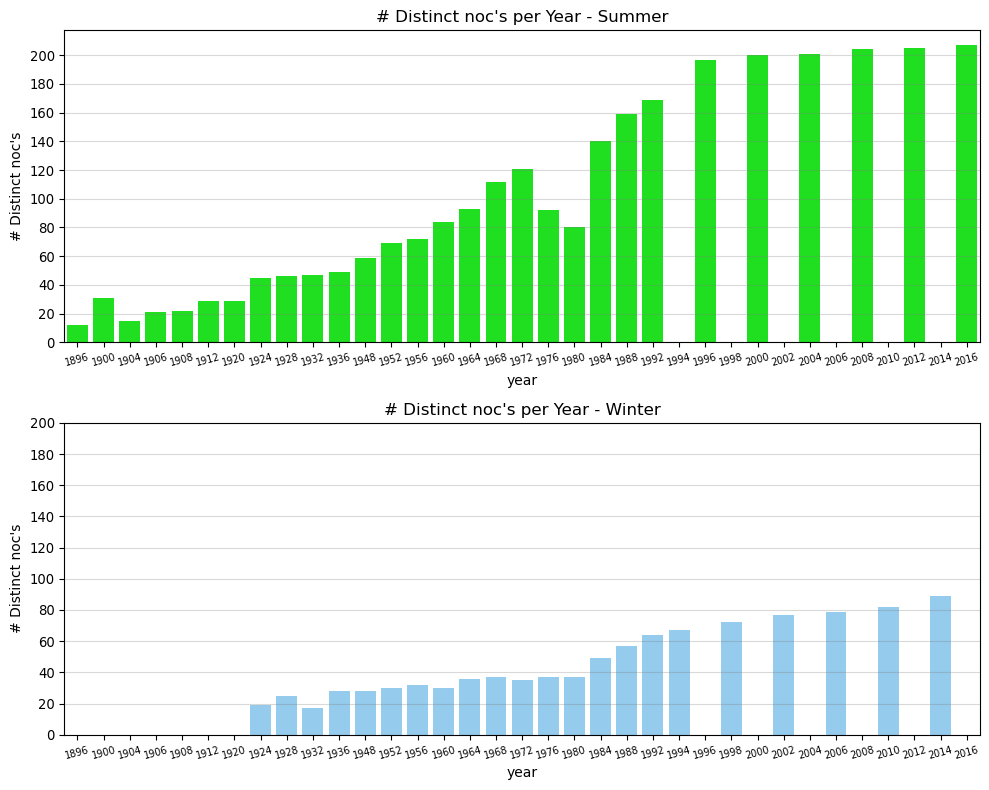

In [27]:
#Want to get # distinct 'noc' values each year
yearly_nocs = data[['noc','year','season']].drop_duplicates().groupby(['year','season']).count().reset_index().rename(columns={'noc':"# Distinct noc's"})
    #display(yearly_nocs)

#plot # distinct noc's per year for each of the 2 seasons
fig, axes = plt.subplots(nrows=2, figsize=(10,8))
#Summer
ax1 = sns.barplot(data=yearly_nocs[yearly_nocs.season == 'Summer'], x='year', 
                  y="# Distinct noc's", color='lime', ax=axes[0])
#Winter
ax2 = sns.barplot(data=yearly_nocs[yearly_nocs.season == 'Winter'], x='year', 
                  y="# Distinct noc's", color='lightskyblue', ax=axes[1])

#edit plot details
for key, v in {"# Distinct noc's per Year - Summer":[0], "# Distinct noc's per Year - Winter":[1]}.items():
    plt.sca(axes[v[0]])
    plt.title(key)
    plt.xticks(fontsize=7, rotation=15)
    plt.yticks(ticks=range(0,211,20), fontsize=9.5)
    plt.grid(axis='y',alpha=0.3,color='gray')
    plt.tight_layout();


The figure above contains two plots that illustrate the number of distinct 'noc' values each year in the Summer & Winter Olympics. Note that the horizontal axes of the two plots above are not identical because the different Games (seasons) didn't always occur in the same year. From 1924-1992, both Games occurred in the same year. Before 1924 & from 1994 onwards, they occurred in different years. There have been multiple periods in which the Olympics were skipped because of other international conflicts, such as the World Wars.

As time has gone on, more national Olympic committees have been formed, sending more athletes to the Olympics across both seasons. The Summer Olympics began about 30 years prior to the first Winter Games (1896 & 1924 respectively). Considerably more distinct 'noc's have been involved in the Summer Games than the Winter Games.

In [28]:
#filter columns & remove duplicate data
anII_data = data[['id','noc','games','year','season','city','event','medal']].drop_duplicates().sort_values(
                ['year','id']).reset_index(drop=True)

#get # distinct athletes per noc per Olympic Game
num_ath_noc_games = anII_data[['id','noc','games']].drop_duplicates().groupby(['games','noc'])['id'].count().reset_index().rename(
    columns={'id':'# Distinct Athletes'})


In [29]:
#get # medals earned by athletes per noc per Game, & append # distinct athletes per noc per Olympic game ("num_ath_noc_games")
games_noc_med_counts = pd.pivot_table(data=anII_data[['id','noc','games','event','medal']], values='id', index=['games','noc'], 
                                      columns='medal', aggfunc='count').merge(num_ath_noc_games, on=['games','noc'])
    #"games_noc_med_counts" has 11,730 rows = 230 unique 'noc's * 51 distinct Olympic Games -- GOOD

#add a few additional columns
for i in games_noc_med_counts.index:
    #get distinct year
    games_noc_med_counts.loc[i,'year'] = games_noc_med_counts.loc[i,'games'].split(' ')[0]
    #get distinct season
    games_noc_med_counts.loc[i,'season'] = games_noc_med_counts.loc[i,'games'].split(' ')[1]
    #sum Total # medals
    games_noc_med_counts.loc[i,'Total Medals'] = games_noc_med_counts.loc[i,'Gold':'Bronze'].sum()

#change 'Total Medals' to integer data type
games_noc_med_counts['Total Medals'] = games_noc_med_counts['Total Medals'].astype('int')

#reorganize columns
games_noc_med_counts = games_noc_med_counts[['games','year','season','noc','# Distinct Athletes','Gold','Silver',
                                             'Bronze','None','Total Medals']]


In [30]:
display(games_noc_med_counts)

#make another version of the "games_noc_med_counts" dataset by melting the 3 medal columns into a single 'Medal' column
    #better for seaborn plots (e.g. hue='Medal')
games_noc_med_counts_melted = games_noc_med_counts.melt(
    id_vars=['games','year','season','noc','# Distinct Athletes','Total Medals'], value_vars=['Gold','Silver','Bronze','None'], 
    var_name='Medal', value_name='# Medals')

display(games_noc_med_counts_melted)


,games,year,season,noc,# Distinct Athletes,Gold,Silver,Bronze,None,Total Medals
0,1896 Summer,1896,Summer,AFG,0,0,0,0,0,0
1,1896 Summer,1896,Summer,AHO,0,0,0,0,0,0
2,1896 Summer,1896,Summer,ALB,0,0,0,0,0,0
3,1896 Summer,1896,Summer,ALG,0,0,0,0,0,0
4,1896 Summer,1896,Summer,AND,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
11725,2016 Summer,2016,Summer,YEM,3,0,0,0,3,0
11726,2016 Summer,2016,Summer,YMD,0,0,0,0,0,0
11727,2016 Summer,2016,Summer,YUG,0,0,0,0,0,0
11728,2016 Summer,2016,Summer,ZAM,7,0,0,0,7,0


,games,year,season,noc,# Distinct Athletes,Total Medals,Medal,# Medals
0,1896 Summer,1896,Summer,AFG,0,0,Gold,0
1,1896 Summer,1896,Summer,AHO,0,0,Gold,0
2,1896 Summer,1896,Summer,ALB,0,0,Gold,0
3,1896 Summer,1896,Summer,ALG,0,0,Gold,0
4,1896 Summer,1896,Summer,AND,0,0,Gold,0
...,...,...,...,...,...,...,...,...
46915,2016 Summer,2016,Summer,YEM,3,0,None,3
46916,2016 Summer,2016,Summer,YMD,0,0,None,0
46917,2016 Summer,2016,Summer,YUG,0,0,None,0
46918,2016 Summer,2016,Summer,ZAM,7,0,None,7


Now that the data has been assembled, plots can be constructed that fit the description provided by the prompt of this section. In the cells below that contain data for the figures, the country can be changed to the value of interest by changing the `(games_noc_med_counts.noc == 'USA')` instances of code to the corresponding 'noc' value. To determine the 'noc' value which corresponds to the country of interest, the dataset can be fiddled with by applying filters to the 'team' &/or 'noc' parameters.

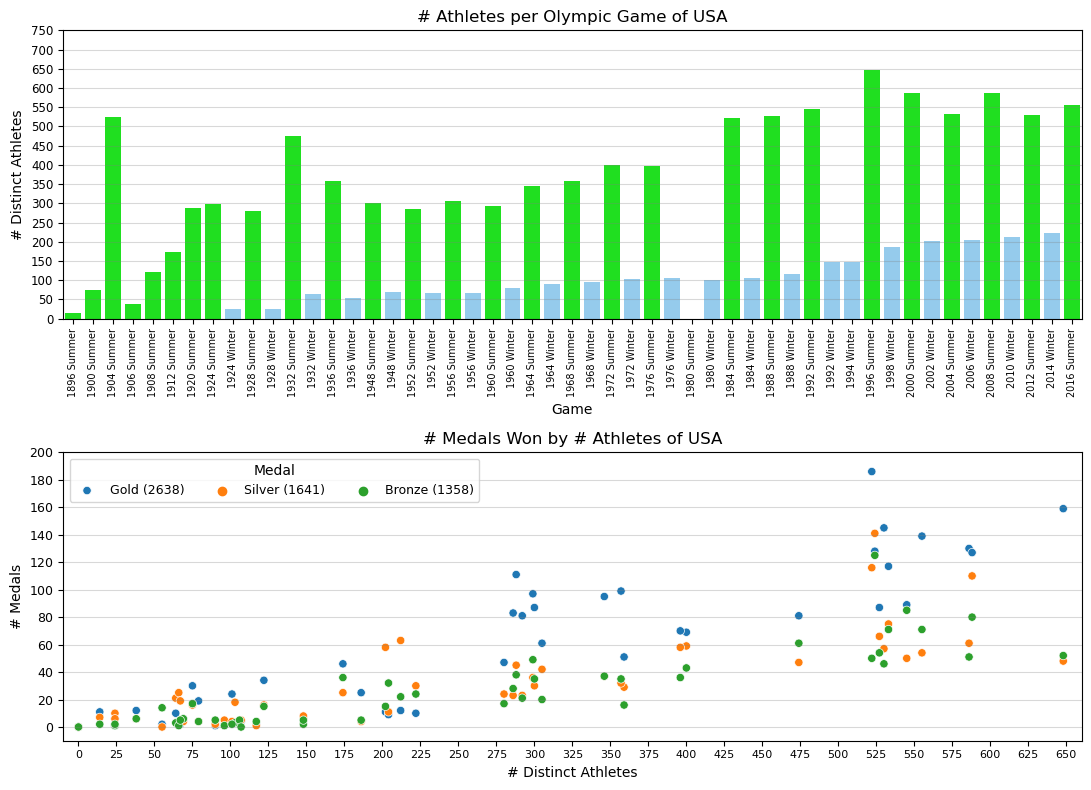

In [31]:
#Make plots & insert country of interest -- e.g. 'noc' == 'USA'
    #display(games_noc_med_counts[games_noc_med_counts.noc == 'USA'])

#fiddle with "data" to find country of interest
    #display(data[data['team'].str.contains(['____'])])

fig, axes = plt.subplots(figsize=(11,8), nrows=2)
#make barplot of # distinct athletes per Olympic Game (season) -- have to make 2 to make Summer/Winter different colors
#Winter
ax1 = sns.barplot(data=games_noc_med_counts[(games_noc_med_counts.noc == 'USA') & (games_noc_med_counts.season == 'Winter')], 
                  x='games', y='# Distinct Athletes', color='lightskyblue', ax=axes[0])
#Summer
ax1 = sns.barplot(data=games_noc_med_counts[(games_noc_med_counts.noc == 'USA') & (games_noc_med_counts.season == 'Summer')], 
                  x='games', y='# Distinct Athletes', color='lime', ax=axes[0])
#make scatterplot of # medals won vs # distinct athletes
ax2 = sns.scatterplot(data=games_noc_med_counts_melted[(games_noc_med_counts_melted.noc == 'USA') & (games_noc_med_counts_melted.Medal != 'None')], 
                       x='# Distinct Athletes', y='# Medals', hue='Medal', ax=axes[1])

#edit plot details
for key, v in {'# Athletes per Olympic Game of USA':[0, 90, 'Game'], '# Medals Won by # Athletes of USA':[1, 0, '# Distinct Athletes']}.items():
    plt.sca(axes[v[0]])
    plt.title(key)
    plt.xlabel(v[2])
    plt.xticks(fontsize=7, rotation=v[1])
    plt.yticks(ticks=range(0,751,50), fontsize=8.5)
    plt.grid(axis='y',alpha=0.3,color='gray')
    plt.tight_layout();

#edit x- & y-axes of 2nd plot
plt.xticks(ticks=range(0,651,25), fontsize=8)
plt.yticks(ticks=range(0,201,20), fontsize=9)
ax2.set(xlim=(-10,660), ylim=(-10,200))

#edit legend of 2nd plot, & save for later use
plt.legend(loc='upper left', ncols=3, title='Medal', fontsize=9, labels=[
            'Gold ({})'.format(games_noc_med_counts[games_noc_med_counts.noc == 'USA']['Gold'].sum()),
            'Silver ({})'.format(games_noc_med_counts[games_noc_med_counts.noc == 'USA']['Silver'].sum()), 
            'Bronze ({})'.format(games_noc_med_counts[games_noc_med_counts.noc == 'USA']['Bronze'].sum())])
medals_leg = ax2.get_legend()
#had to edit colors of 'Silver' & 'Bronze'
medals_leg.legendHandles[1].set_color(sns.color_palette()[1])
medals_leg.legendHandles[2].set_color(sns.color_palette()[2])
#re-save
medals_leg = ax2.get_legend_handles_labels()


Of the two plots above, the first illustrates the number of distinct athletes that participated in each of the 51 Olympic events. The lime bars indicate the Summer Games whereas the light-blue bars indicate the Winter Games. The second plot displays the number of medals that were won by athletes of the country of interest in relation to the number of distinct athletes (of specified country) per Olympic Game. The data points of this scatterplot were also split by what medal was won, & so many data points are not displayed because they had a 'Medal' value of "None." The number in the legend alongside each medal indicates the number of total medals won across the 51 Games by these athletes.

In this case, the data concerning the national Olympic committee of the United States was used as an example, mostly because they account for a sizable amount of observations in the dataset. Generally, there are considerably more American athletes that have partaken in the Summer Games than in the Winter Games. The 1980 Summer Games was the only Olympic event in which no American athletes competed in. Of the 51 Games, more American athletes competed in the 1996 Summer Games than in any other event.

In the second plot, American athletes have won considerably more gold medals than any other medal. They've also won more silver medals than bronze medals. Of this data, there are several various groups of data points in terms of the number of distinct athletes per Olympic Game, which is as low as zero & as high as 650 athletes. The number of medals won by any of these data points (groups of athletes) varies from zero to about 190 medals. Generally, larger groups of athletes won more medals. This is, of course, a logical conclusion because the more athletes that participate present more opportunities for them (& their country) to win Olympic medals. Furthermore, larger groups of these American athletes appear to have won more gold medals than any other medal & as opposed to smaller groups of athletes. It also appears that smaller groups of these American athletes won bronze medals slightly more often than silver medals.

'Gold:'

,# Distinct Athletes,# Medals
# Distinct Athletes,1.00000,0.85982
# Medals,0.85982,1.00000


'Silver:'

,# Distinct Athletes,# Medals
# Distinct Athletes,1.000000,0.823513
# Medals,0.823513,1.000000


'Bronze:'

,# Distinct Athletes,# Medals
# Distinct Athletes,1.000000,0.886061
# Medals,0.886061,1.000000


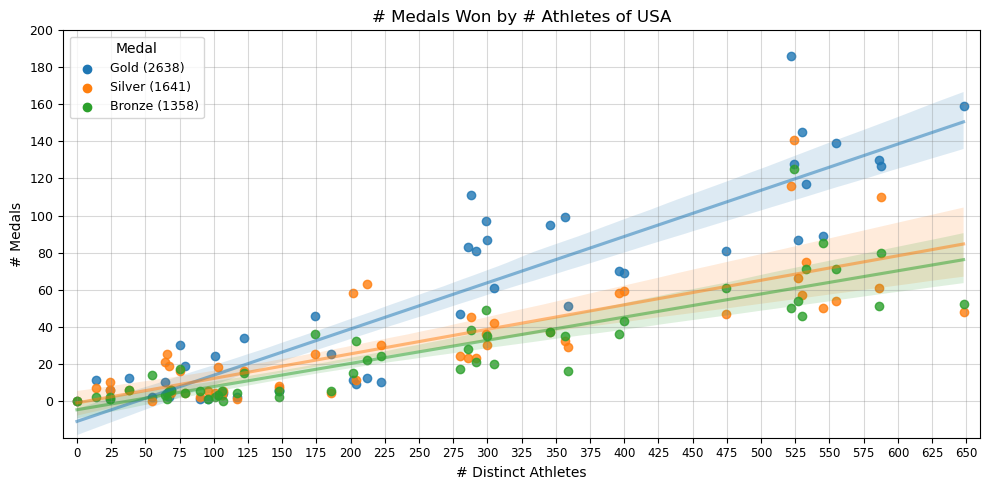

In [32]:
#Make regression plots of the 2nd plot in above cell instead of scatterplot to get a regression line
    #there is no 'hue' parameter in sns.regplot(), so have to superpose 3 plots for each 'Medal'

plt.figure(figsize=(10,5))
#Gold
ax3 = sns.regplot(data=games_noc_med_counts_melted[(games_noc_med_counts_melted.noc == 'USA') & (games_noc_med_counts_melted.Medal == 'Gold')], 
                       x='# Distinct Athletes', y='# Medals', color=sns.color_palette()[0], line_kws={'alpha':0.5})
#Silver
ax4 = sns.regplot(data=games_noc_med_counts_melted[(games_noc_med_counts_melted.noc == 'USA') & (games_noc_med_counts_melted.Medal == 'Silver')], 
                       x='# Distinct Athletes', y='# Medals', color=sns.color_palette()[1], line_kws={'alpha':0.5})
#Bronze
ax5 = sns.regplot(data=games_noc_med_counts_melted[(games_noc_med_counts_melted.noc == 'USA') & (games_noc_med_counts_melted.Medal == 'Bronze')], 
                       x='# Distinct Athletes', y='# Medals', color=sns.color_palette()[2], line_kws={'alpha':0.5})

#edit plot details
plt.title('# Medals Won by # Athletes of USA')
plt.xticks(ticks=range(0,651,25), fontsize=8.5)
plt.yticks(ticks=range(0,201,20), fontsize=9)
ax5.set(xlim=(-10,660), ylim=(-20,200))
plt.legend(title='Medal', fontsize=9, handles=medals_leg[0], labels=[
            'Gold ({})'.format(games_noc_med_counts[games_noc_med_counts.noc == 'USA']['Gold'].sum()),
            'Silver ({})'.format(games_noc_med_counts[games_noc_med_counts.noc == 'USA']['Silver'].sum()), 
            'Bronze ({})'.format(games_noc_med_counts[games_noc_med_counts.noc == 'USA']['Bronze'].sum())])
plt.grid(axis='both',alpha=0.3,color='gray')
plt.tight_layout();

#calculate correlation between '# Distinct Athletes' & '# Medals' for each of the medals
    #use 'Spearman' method bc these parameters are quantitative discrete variables
display('Gold:')
display(games_noc_med_counts_melted[(games_noc_med_counts_melted.noc == 'USA') & (games_noc_med_counts_melted.Medal == 'Gold')][['# Distinct Athletes','# Medals']].corr(method='spearman'))
display('Silver:')
display(games_noc_med_counts_melted[(games_noc_med_counts_melted.noc == 'USA') & (games_noc_med_counts_melted.Medal == 'Silver')][['# Distinct Athletes','# Medals']].corr(method='spearman'))
display('Bronze:')
display(games_noc_med_counts_melted[(games_noc_med_counts_melted.noc == 'USA') & (games_noc_med_counts_melted.Medal == 'Bronze')][['# Distinct Athletes','# Medals']].corr(method='spearman'))


This plot contains the same data as the most recent scatter plot above, but it includes a regression line of the data for each of the three medals. This line indicates the relationship between the two axes. For each of the three lines, they indicate a positive relationship between the two axes because as the value of the horizontal axis increases along the regression line, the corresponding value of the vertical axis also increases. This relationship increases the most for the data associated with gold medals, & it increases very similarly for the silver- & bronze-medal data. The slopes--the vertical change in relation to the horizontal change--of the three lines for gold, silver, & bronze medals are roughly 1:4, 2:15 (~ 1:8.5), & 4:35 (~ 1:8.75) respectively -- roughly one gold medal is won for every four American athletes. So, these regression lines would suggest that American athletes have won gold medals twice as often than silver & bronze medals, & they have won slightly more silver medals than bronzes.

In a similar vein, the correlation between the '# Distinct Athletes' & '# Medals' was also calculated for the data of the three different medals. For gold, silver, & bronze, these relationships had a correlation of approximately 0.86, 0.82, & 0.89 respectively. Interestingly, this relationship is strongest for bronze medals. The difference (between these correlations & the regression lines) may have to do with the total number of each of the three medals that were won; these athletes won less bronze medals than either of the other two medals.

As such, it can be said that the number of medals won by American athletes strongly relates with the number of American athletes that compete in Olympic events.

This process & these most recent three plots can be performed for any country by changing the code, as described previously. Of course, the results of such analyses will likely differ vastly across various countries depending on how many data points they account for in the dataset. Also, the first couple of cells in this section, illustrating the number of athletes & participations associated with each country (or 'noc'), are useful in providing additional context to these latter three plots (& associated analyses). 
An example using another country is performed & shown below.

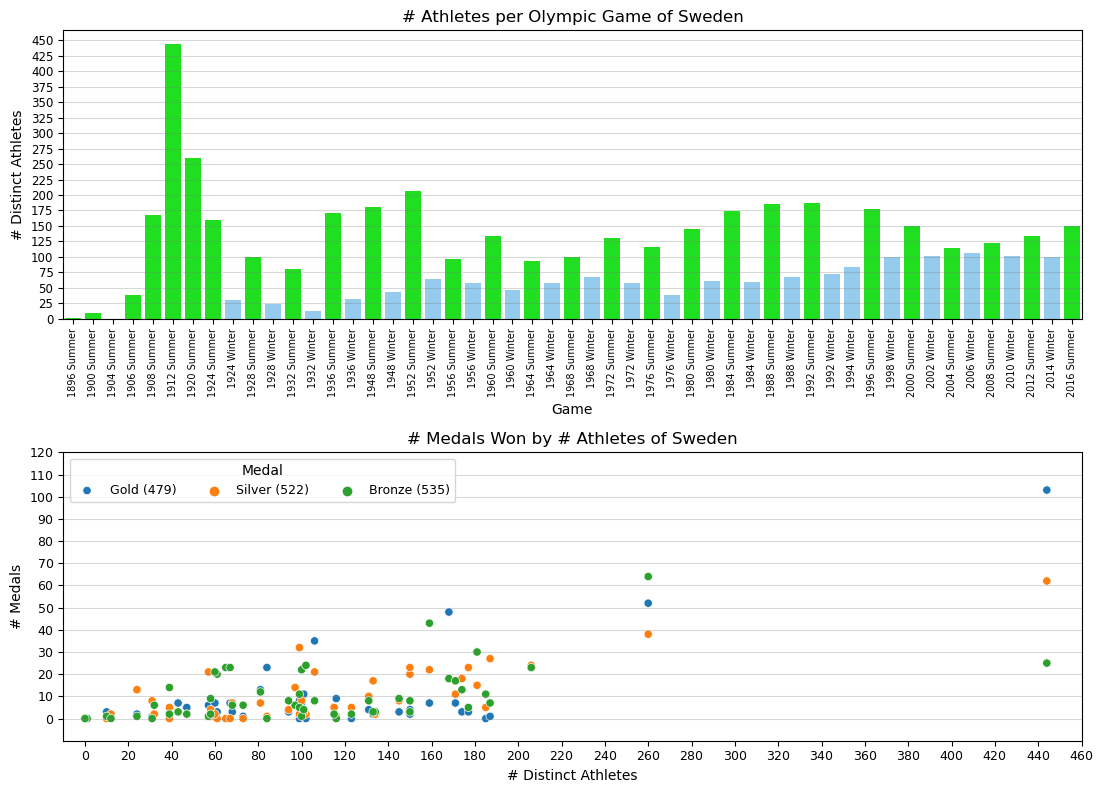

In [33]:
#make another plot using Sweden -- 'noc' == "SWE"
    #display(games_noc_med_counts[games_noc_med_counts.noc == 'SWE'].sort_values('# Distinct Athletes'))

fig, axes = plt.subplots(figsize=(11,8), nrows=2)
#make barplot of # distinct athletes per Olympic Game (season) -- have to make 2 to make Summer/Winter different colors
#Winter
ax1 = sns.barplot(data=games_noc_med_counts[(games_noc_med_counts.noc == 'SWE') & (games_noc_med_counts.season == 'Winter')], 
                  x='games', y='# Distinct Athletes', color='lightskyblue', ax=axes[0])
#Summer
ax1 = sns.barplot(data=games_noc_med_counts[(games_noc_med_counts.noc == 'SWE') & (games_noc_med_counts.season == 'Summer')], 
                  x='games', y='# Distinct Athletes', color='lime', ax=axes[0])
#make scatterplot of # medals won vs # distinct athletes
ax2 = sns.scatterplot(data=games_noc_med_counts_melted[(games_noc_med_counts_melted.noc == 'SWE') & (games_noc_med_counts_melted.Medal != 'None')], 
                       x='# Distinct Athletes', y='# Medals', hue='Medal', ax=axes[1])

#edit plot details
for key, v in {'# Athletes per Olympic Game of Sweden':[0, 90, 'Game'], '# Medals Won by # Athletes of Sweden':[1, 0, '# Distinct Athletes']}.items():
    plt.sca(axes[v[0]])
    plt.title(key)
    plt.xlabel(v[2])
    plt.xticks(fontsize=7, rotation=v[1])
    plt.yticks(ticks=range(0,451,25), fontsize=8.5)
    plt.grid(axis='y',alpha=0.3,color='gray')
    plt.tight_layout();

#edit x- & y-axes of 2nd plot
plt.xticks(ticks=range(0,461,20), fontsize=9)
plt.yticks(ticks=range(0,121,10), fontsize=9)
ax2.set(xlim=(-10,460), ylim=(-10,120))

#edit legend of 2nd plot, & save for later use
plt.legend(loc='upper left', ncols=3, title='Medal', fontsize=9, labels=[
            'Gold ({})'.format(games_noc_med_counts[games_noc_med_counts.noc == 'SWE']['Gold'].sum()),
            'Silver ({})'.format(games_noc_med_counts[games_noc_med_counts.noc == 'SWE']['Silver'].sum()), 
            'Bronze ({})'.format(games_noc_med_counts[games_noc_med_counts.noc == 'SWE']['Bronze'].sum())])
medals_leg = ax2.get_legend()
#had to edit colors of 'Silver' & 'Bronze'
medals_leg.legendHandles[1].set_color(sns.color_palette()[1])
medals_leg.legendHandles[2].set_color(sns.color_palette()[2])
#re-save
medals_leg = ax2.get_legend_handles_labels()


In this case, the data concerning the national Olympic committee of Sweden was used as an example. Generally, there are more Swedish athletes that have partaken in the Summer Games than in the Winter Games. The 1904 Summer Games was the only Olympic event in which no Swedish athletes competed in. Of the 51 Games, significantly more Swedish athletes competed in the 1912 Summer Games than in any other event.

In the second plot, Swedish athletes most of their medals are bronzes whereas least of their medals are golds. Of this data, there are a few distinct groups of data points in terms of the number of distinct athletes per Olympic Game, which is as low zero & about 445 athletes. The number of medals won by any of these points (groups of athletes) varies from zero to about 105 medals. Generally, larger groups of athletes won more medals. From this plot, it is difficult to say whether smaller/larger groups of athletes win more or less gold/silver/bronze medals than other groups of the same athlete-group size.

'Gold:'

,# Distinct Athletes,# Medals
# Distinct Athletes,1.000000,0.383524
# Medals,0.383524,1.000000


'Silver:'

,# Distinct Athletes,# Medals
# Distinct Athletes,1.000000,0.666467
# Medals,0.666467,1.000000


'Bronze:'

,# Distinct Athletes,# Medals
# Distinct Athletes,1.0000,0.5165
# Medals,0.5165,1.0000


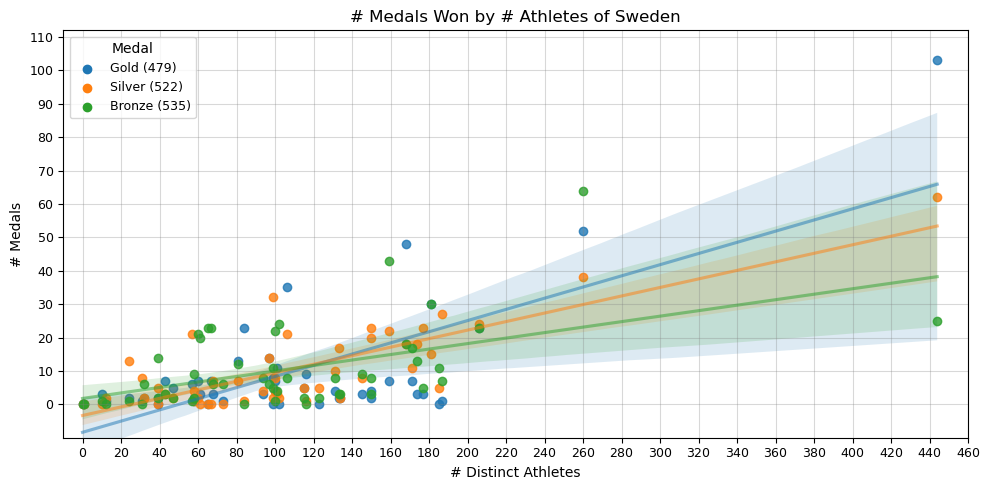

In [34]:
#Make regression plots of the 2nd plot in above cell instead of scatterplot to get a regression line
    #there is no 'hue' parameter in sns.regplot(), so have to superpose 3 plots for each 'Medal'

plt.figure(figsize=(10,5))
#Gold
ax3 = sns.regplot(data=games_noc_med_counts_melted[(games_noc_med_counts_melted.noc == 'SWE') & (games_noc_med_counts_melted.Medal == 'Gold')], 
                       x='# Distinct Athletes', y='# Medals', color=sns.color_palette()[0], line_kws={'alpha':0.5})
#Silver
ax4 = sns.regplot(data=games_noc_med_counts_melted[(games_noc_med_counts_melted.noc == 'SWE') & (games_noc_med_counts_melted.Medal == 'Silver')], 
                       x='# Distinct Athletes', y='# Medals', color=sns.color_palette()[1], line_kws={'alpha':0.5})
#Bronze
ax5 = sns.regplot(data=games_noc_med_counts_melted[(games_noc_med_counts_melted.noc == 'SWE') & (games_noc_med_counts_melted.Medal == 'Bronze')], 
                       x='# Distinct Athletes', y='# Medals', color=sns.color_palette()[2], line_kws={'alpha':0.5})

#edit plot details
plt.title('# Medals Won by # Athletes of Sweden')
plt.xticks(ticks=range(0,461,20), fontsize=9)
plt.yticks(ticks=range(0,121,10), fontsize=9)
ax5.set(xlim=(-10,460), ylim=(-10,112))
plt.legend(title='Medal', fontsize=9, handles=medals_leg[0], labels=[
            'Gold ({})'.format(games_noc_med_counts[games_noc_med_counts.noc == 'SWE']['Gold'].sum()),
            'Silver ({})'.format(games_noc_med_counts[games_noc_med_counts.noc == 'SWE']['Silver'].sum()), 
            'Bronze ({})'.format(games_noc_med_counts[games_noc_med_counts.noc == 'SWE']['Bronze'].sum())])
plt.grid(axis='both',alpha=0.3,color='gray')
plt.tight_layout();

#calculate correlation between '# Distinct Athletes' & '# Medals' for each of the medals
    #use 'Spearman' method bc these parameters are quantitative discrete variables
display('Gold:')
display(games_noc_med_counts_melted[(games_noc_med_counts_melted.noc == 'SWE') & (games_noc_med_counts_melted.Medal == 'Gold')][['# Distinct Athletes','# Medals']].corr(method='spearman'))
display('Silver:')
display(games_noc_med_counts_melted[(games_noc_med_counts_melted.noc == 'SWE') & (games_noc_med_counts_melted.Medal == 'Silver')][['# Distinct Athletes','# Medals']].corr(method='spearman'))
display('Bronze:')
display(games_noc_med_counts_melted[(games_noc_med_counts_melted.noc == 'SWE') & (games_noc_med_counts_melted.Medal == 'Bronze')][['# Distinct Athletes','# Medals']].corr(method='spearman'))


The relationship between the two axes increases the most for the data associated with gold medals, the next most for silver medals, & the next most for bronze medals. The slopes of the three lines for gold, silver, & bronze medals are roughly 1:6, 1:8, & 1:12 respectively -- approximately one gold medal is won for every six Swedish athletes.

In a similar vein, the correlation between the '# Distinct Athletes' & '# Medals' was also calculated for the data of the three different medals. For gold, silver, & bronze, these relationships had a correlation of approximately 0.38, 0.67, & 0.52 respectively.

As such, it can be said that the number of medals won by Swedish athletes does slightly relate with the number of Swedish athletes that compete in Olympic events, but this relationship is not as sizable as that of the American athletes examined earlier.

# -------------------------------------------------------------------------------------------------------------

# Analysis III
In which sports does the height of an athlete increase their chances of earning a medal?

Depending on the sport, there are reasonable rationales that could suggest that an athlete's height is a relevant factor in that Olympic event. Generally, a taller athlete would have advantages & disadvantages compared to smaller athletes such as a larger weight, a greater ability to jump higher or farther, or a greater ability to outmuscle their opponent. These aspects would be beneficial in sports like basketball & volleyball. On the contrary, a smaller height would imply a smaller weight thus making such athletes more agile & nimble which could be more advantageous in other sports such as gymnastics, rowing, & skiing.

Although an athlete's height may or may not guarantee them a medal in certain Olympic sports, it may be able to give them a helpful advantage over some of their opponents.

In this analysis, the most relevant columns of the dataset include 'id,' 'height,' 'sport'/'event,' & 'medal,' but others such as 'weight,' 'sex,' & 'noc' may provide additional insight into this relationship. There are several pathways in which this analysis could be expanded upon by using some of the other parameters. For example, how does this relationship between 'height' & 'medal' relate to 'sex,' 'age,' 'weight,' 'noc,' 'year,' 'season,' 'sport,' & 'event.'

Note that it is important to use the 'id' parameter when analyzing separate athletes as opposed to 'name' because there is a possibility that there are some athletes in the dataset who have the same name. This may be why there are differing numbers regarding the number of unique 'id' & 'name' values.

In [35]:
#determine # of unique athletes
    #display(data['id'].drop_duplicates().reset_index(drop=True))

#determine # unique 'sport's & 'event's
    #display(data['sport'].drop_duplicates().reset_index(drop=True))
    #display(data['event'].drop_duplicates().reset_index(drop=True))

#get an understanding of the distribution of the 66 unique sports
sport_counts = data.sport.value_counts(dropna=False).reset_index().rename(columns={'count':'#'})
#display(sport_counts[sport_counts['#'] >= 100])
#display(sport_counts[sport_counts['#'] < 100])
display(sport_counts['#'].sum())

#add column indicating whether a medal was won or not
for i in data.index:
    if data.loc[i,'medal'] == 'None':
        data.loc[i,'medal?'] = 'No'
    else:
        data.loc[i,'medal?'] = 'Yes'


269731

In the dataset, there are 135,571 unique athletes. There are 66 unique sports & 765 unique events in the dataset. Of course, it is likely that some sports & events only took place a handful of times &/or occurred very long ago. Therefore, 'sport' is a much more advisable parameter to use versus 'event.'

In [36]:
data.groupby(['sport','medal?']).count().iloc[:,0].reset_index().rename(columns={'id':'#'})


,sport,medal?,#
0,Aeronautics,No,0
1,Aeronautics,Yes,1
2,Alpine Skiing,No,8401
3,Alpine Skiing,Yes,428
4,Alpinism,No,0
...,...,...,...
127,Water Polo,Yes,1057
128,Weightlifting,No,3291
129,Weightlifting,Yes,646
130,Wrestling,No,5858


In [37]:
#columns of interest include: [['id','sex','age','height','weight','noc','games','year','season','sport','event','medal']]

#calculate summary statistics of 'height' for each 'sport'
sport_height_stats = data.groupby('sport').height.describe()

#get # counts for sport-medal? pairs, & determine if there are any values of 0
sports_no_medals = data.groupby(['sport','medal?']).count().iloc[:,0].reset_index().rename(columns={'id':'#'})
    #66 sports * 2 'medal?' values = 132 rows -- GOOD
    #display(sports_no_medals[sports_no_medals['#'] == 0].reset_index(drop=True))

#calculate summary statistics of 'height' for each 'sport' for athletes that did & did not win a medal
sport_medal_height_stats_incomplete = data.groupby(['sport','medal?']).height.describe()
    #display(sport_medal_height_stats_incomplete)
    #126 rows; 6 missing sport-medal? pairs that have no data

#combine "sports_no_medals" & "sport_medal_height_stats" to get all instances of sport-medal? combinations
sport_medal_height_stats = pd.concat([sport_medal_height_stats_incomplete.reset_index(), sports_no_medals[sports_no_medals['#'] == 0].reset_index()], 
          axis=0).sort_values(['sport','medal?']).reset_index(drop=True).set_index(['sport','medal?']).drop(columns=['index'])
display(sport_medal_height_stats)
    #132 rows -- GOOD



count        mean        std    min     25%    50%  \
sport         medal?                                                        
Aeronautics   No         NaN         NaN        NaN    NaN     NaN    NaN   
              Yes        1.0  175.000000        NaN  175.0  175.00  175.0   
Alpine Skiing No      8401.0  173.907630   6.694332  142.0  170.00  175.0   
              Yes      428.0  173.869159   7.081108  154.0  170.00  175.0   
Alpinism      No         NaN         NaN        NaN    NaN     NaN    NaN   
...                      ...         ...        ...    ...     ...    ...   
Water Polo    Yes     1057.0  182.671712   9.218984  155.0  175.00  181.0   
Weightlifting No      3291.0  169.671225   9.022570  140.0  163.00  172.0   
              Yes      646.0  168.736842  10.109575  140.0  160.25  170.0   
Wrestling     No      5858.0  173.000341   8.646571  137.0  167.00  175.0   
              Yes     1296.0  173.142747   9.382584  147.0  167.00  175.0   

                        75%    max    #  
sport         medal?                     
Aeronautics   No        NaN    NaN  0.0  
              Yes     175.0  175.0  NaN  
Alpine Skiing No      177.0  200.0  NaN  
              Yes     178.0  192.0  NaN  
Alpinism      No        NaN    NaN  0.0  
...                     ...    ...  ...  
Water Polo    Yes     190.0  205.0  NaN  
Weightlifting No      175.0  197.0  NaN  
              Yes     175.0  205.0  NaN  
Wrestling     No      176.0  214.0  NaN  
              Yes     178.0  214.0  NaN  

[132 rows x 9 columns]

Of the 66 sports, they all have at least one athlete. Additionally, of these 66 sports, there are six instances (of 132 total) in which there are no instances of a medal being won or not won for a specific sport. These missing instances will make analysis more difficult for the associated sports in terms of whether or not height is a factor in medal-winning success.

Another useful technique that could be used for this analysis is correlation; however, since the 'medal?' parameter--indicating if the athlete won a medal or not--is a qualitative nominal variable, correlation cannot be calculated for any relationship with it.

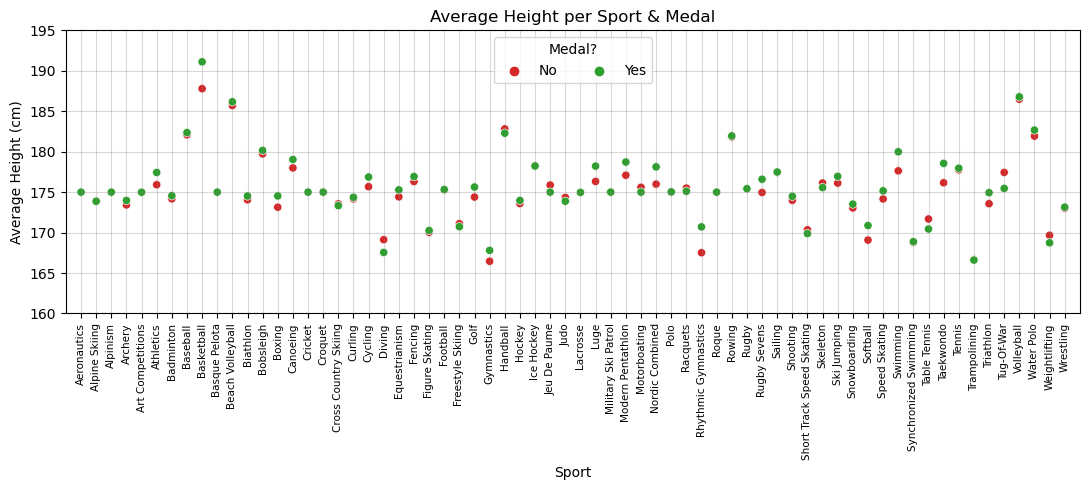

In [38]:
#Make a scatterplot displaying the average 'height' of each sport for those that win & don't win a medal

#make a note of groups that only have a handful of observations
#display(sport_medal_height_stats[sport_medal_height_stats['count'] < 20])

plt.figure(figsize=(11,5))

ax1 = sns.scatterplot(data=sport_medal_height_stats, x='sport', y='mean', hue='medal?', 
                      palette=[sns.color_palette()[3], sns.color_palette()[2]])
#edit plot details
ax1.set(xlim=(-1,66.01))
plt.title('Average Height per Sport & Medal')
plt.xlabel('Sport')
plt.ylabel('Average Height (cm)')
plt.xticks(rotation=90, fontsize=7.5)
plt.yticks(ticks=range(160,196,5))
plt.legend(ncols=2, title='Medal?', loc='upper center')
plt.grid(axis='both', alpha=0.3, color='gray')
plt.tight_layout();


The figure above contains data on the average height of each sport for two groups: athletes that did & did not win a medal. Of the 132 data points, there are six instances in which there was no height data for that sport-medal group. 
The primary feature of interest is the difference between the two (differently colored) data points for each sport, if said points exist. A greater difference is more likely to imply that height is a factor in an athlete's chance of winning a medal for that specific sport.

One factor that is important to consider is the number of athletes that fit into each group (data point). Those made up of fewer athletes are not necessarily as representative or as credible as those with hundreds or thousands of athletes because smaller groups are subject to a much greater influence by outliers than larger groups. For sports with notable differences in their average height, it is important to check how many athletes make up each of the two groups (those that won & did not win a medal).

When measuring the difference of the average heights of the two groups for each sport, it is difficult to quantify the exact difference in average height just by examining the plot above.
Sports that appear to have a considerable difference between the average heights of their two groups include: athletics, basketball, boxing, canoeing, cycling, diving, golf, gymnastics, luge, modern pentathlon, nordic combined, rhythmic gymnastics, rugby sevens, softball, speed skating, swimming, table tennis, taekwondo, triathlon, & tug-of-war. These sports are the most worthy of further analysis to calculate the exact differences in average height.

Additionally, it appears that for most sports, the average height of those that won a medal is larger than that of those who did not win a medal. For sports that have higher average heights, athletes who have won a medal typically have a greater average height than those who did not win a medal (e.g. baseball, basketball, beach volleyball, rowing, volleyball, water polo). On the other hand, for sports that have smaller average heights, athletes who haven't won a medal more often have a greater average height than those who did win a medal (e.g. diving, freestyle skiing, short track speed skating, table tennis, weightlifting).

In [39]:
#Want to get the difference of the average heights per sport of those that won & did not win a medal

#make a dataframe
sport_medal_height_diff = sport_medal_height_stats.reset_index()[['sport','mean']].drop_duplicates('sport').reset_index(drop=True)
#make copy of dataframe with necessary information to use, making later process simpler
height_stats_temp = sport_medal_height_stats.reset_index().copy()
#filter for sport & avg height of groups that didn't win medals
sport_avg_height_nomed = height_stats_temp[height_stats_temp['medal?'] == 'No'].reset_index(drop=True)
#filter for sport & avg height of groups that did win medals
sport_avg_height_yesmed = height_stats_temp[height_stats_temp['medal?'] == 'Yes'].reset_index(drop=True)
#calculate difference in average height between the two groups
for i in sport_medal_height_diff.index:
    sport_medal_height_diff.loc[i,'Avg Height Diff (cm)'] = np.abs(sport_avg_height_yesmed.loc[i,'mean'] - sport_avg_height_nomed.loc[i,'mean'])
#drop extra column
sport_medal_height_diff = sport_medal_height_diff.drop(columns='mean')
    #display(sport_medal_height_diff.sort_values('Avg Height Diff (cm)', ascending=False))


In [40]:
#collect some yearly data per sport to get better idea of how recent & often each sport has taken place
sport_yr_data = data.groupby('sport')['year'].min().reset_index().rename(columns={'year':'First Year'}).merge(
                    sport_counts, on='sport')
sport_yr_data = data.groupby('sport')['year'].max().reset_index().rename(columns={'year':'Most Recent Year'}).merge(
        sport_yr_data, on='sport').rename(columns={'#':'# Observations'})
#reorganize columns
sport_yr_data = sport_yr_data[['sport','# Observations','First Year','Most Recent Year']]
#fill null values
sport_yr_data = pd.concat([sport_yr_data,sport_yr_data[['First Year','Most Recent Year']].fillna('none').rename(
    columns={'First Year':'FY','Most Recent Year':'MRY'})], axis=1).drop(columns=['First Year','Most Recent Year']).rename(
    columns={'FY':'First Year','MRY':'Most Recent Year'})
#display(sport_yr_data)

#merge this yearly data w/average-height differences from previous cell -- "sport_medal_height_diff"
sport_medal_height_diff = sport_medal_height_diff.merge(sport_yr_data, on='sport')
display(sport_medal_height_diff)


,sport,Avg Height Diff (cm),# Observations,First Year,Most Recent Year
0,Aeronautics,NaN,1,1936,1936
1,Alpine Skiing,0.038471,8829,1936,2014
2,Alpinism,NaN,25,1924,1936
3,Archery,0.546016,2334,1900,2016
4,Art Competitions,0.003803,2263,1912,1948
...,...,...,...,...,...
61,Tug-Of-War,1.975494,170,1900,1920
62,Volleyball,0.294554,3404,1964,2016
63,Water Polo,0.748084,3846,1900,2016
64,Weightlifting,0.934382,3937,1896,2016


In [41]:
display(sport_medal_height_diff.sort_values('Avg Height Diff (cm)', ascending=False).head(11).reset_index(drop=True))

sport_medal_height_stats_copy = sport_medal_height_stats.reset_index().copy()
#display(sport_medal_height_stats_copy[sport_medal_height_stats_copy['sport'].isin(sport_medal_height_diff.sort_values('Avg Height Diff (cm)', ascending=False).head(12)['sport'].values)])



,sport,Avg Height Diff (cm),# Observations,First Year,Most Recent Year
0,Basketball,3.319502,4536,1936,2016
1,Rhythmic Gymnastics,3.193139,658,1984,2016
2,Taekwondo,2.397547,606,2000,2016
3,Swimming,2.352526,23195,1896,2016
4,Nordic Combined,2.128846,1344,1924,2014
5,Tug-Of-War,1.975494,170,1900,1920
6,Luge,1.898730,1479,1964,2014
7,Softball,1.797930,478,1996,2008
8,Rugby Sevens,1.639039,299,2016,2016
9,Modern Pentathlon,1.631228,1677,1912,2016


Sports that do not have the sufficient data to determine whether or not an athlete's height has an influence on their chance of winning an Olympic medal include: aeronautics, alpinism, basque pelota, cricket, lacrosse, & rugby (six of 66 sports). All of these sports took place between 1900-1936, none of which had more than 162 observations in the dataset. Of these six sports, a medal was won in every observation.
Of the other 60 sports, the only ones which had more medals won than no medals won included: polo (95 observations), roque (4), & tug-of-war (170); military ski patrol had 12 observations each.

The 12 sports which had the greatest difference in average height between the groups of athletes that did & did not win medals are as follows (from most to least): basketball, rhythmic gymnastics, taekwondo, swimming, nordic combined, tug-of-war, luge, softball, rugby sevens, modern pentathlon, diving, & athletics. All of these sports had a difference in average height of at least 1.5 centimeters, five had a difference of at least two centimeters, & two had a difference of more than three centimeters.

Note that these values in the 'Avg Height Diff (cm)' column of the "sport_medal_height_diff" dataframe are magnitudes, & do not indicate whether the group of athletes that did win medals had a larger average height than those who didn't win a medal. 
Of these 12 sports, the only sports in which the average height of athletes who didn't win a medal is greater than that of athletes who did win a medal is diving & tug-of-war. Tug-of-war is the only one of these 12 sports that has not been played since 2008 -- it was last played in 1920! Perhaps, based on these 12 sports, having a shorter height was more valuable in the early 20th century, whereas the opposite is true in the 21st century. There are a few of these sports in which there are not a considerably large number of observations (less than 300) in the dataset such as tug-of-war & rugby sevens. Tug-of-war only partook in the Olympics from 1900-1920 & rugby sevens only began in 2016.

On the other hand, the sports that have the smallest difference in average height across their groups of athletes who have & have not won medals include (from least to most): roque (no difference), military ski patrol (no difference), croquet (no difference), art competitions, polo, sailing, alpine skiing, ice hockey, trampolining, (non-American) football, synchronized swimming, rowing, wrestling, curling, tennis, cross country skiing, & figure skating. All 17 of these sports have a difference of average height of less than a quarter of a centimeter. Of these sports, the five with the smallest height difference have not been played most recently in 1948. The other 12 sports were played as recently as 2014. Of the five sports with the smallest height differences, four have less than 100 observations in the dataset. Of the other 12 sports, only one has less than 460 observations: trampolining, which is the only sport of these 12 which began later than 1984 (2000).

Overall, the sports that see the greatest differences in average height between athletes who have & have not won Olympic medals & have been played recently include basketball, rhythmic gymnastics, taekwondo, swimming, & nordic combined. The sports that see the smallest differences include roque (no difference), military ski patrol (no difference), croquet (no difference), art competitions, polo, sailing, alpine skiing, ice hockey, & trampolining.

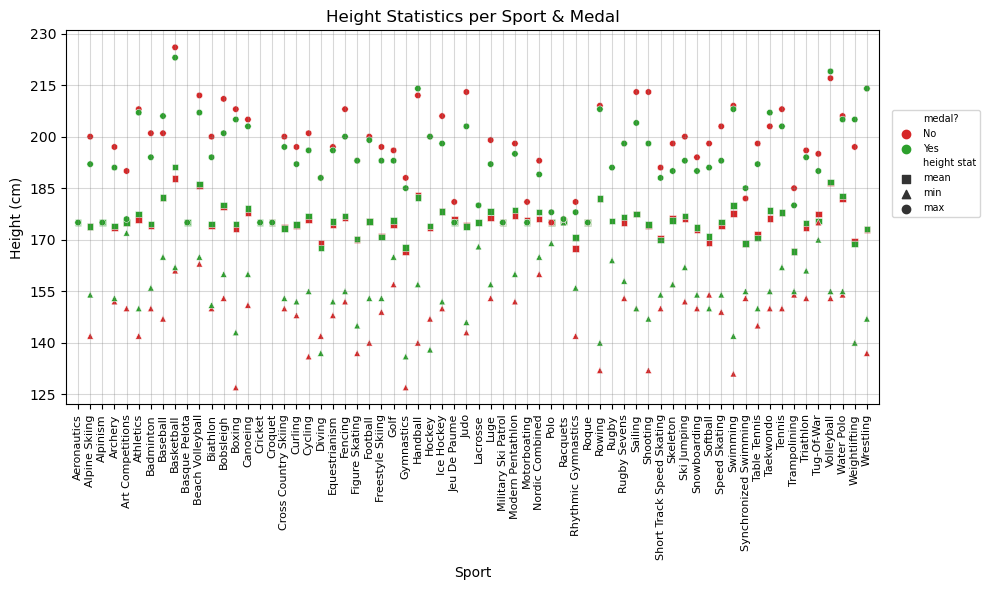

In [42]:
#rearrange the "sport_medal_height_stats" data for an altnative scatterplot w/additional statistics
sport_medal_height_stats_melted = sport_medal_height_stats.reset_index().melt(id_vars=['sport','medal?','count'], 
                                            value_vars=['mean','std','min','25%','50%','75%','max'], var_name='height stat')
    #display(sport_medal_height_stats_melted)

#Make scatterplot of minimum, average, & maximum height statistics per sport for athletes with/without a medal

plt.figure(figsize=(10,6))
ax1 = sns.scatterplot(data=sport_medal_height_stats_melted[sport_medal_height_stats_melted['height stat'].isin(['mean','min','max'])], 
               x='sport', y='value', hue='medal?', style='height stat', markers=['s','^','o'], s=22,
               palette=[sns.color_palette()[3], sns.color_palette()[2]])
#edit plot details
plt.title('Height Statistics per Sport & Medal')
plt.xlabel('Sport')
plt.ylabel('Height (cm)')
ax1.set(xlim=(-1,66.01))
plt.xticks(rotation=90, fontsize=8)
plt.yticks(ticks=range(125,231,15))
plt.grid(axis='both',alpha=0.3,color='gray')
plt.legend(bbox_to_anchor=(1.01,0.8), fontsize=7)
plt.tight_layout();


This plot illustrates the same general data as the previous scatterplot with the addition of two more parameters, specifically, the minimum ("min") & maximum ("max") heights of each sport for each of the two medal groups. Triangles & circles indicate these min & max heights respectively whereas squares represent the mean in this case. First off, take note of the difference in the range of values along the vertical axis. In the previous plot, which only displayed the mean height, it ranged from 160-195 centimeters whereas in this plot, it ranges from 125-230 centimeters. This difference illustrates how varying the heights are of athletes across the 66 sports in the dataset; however, the primary interest is the difference in each statistic for the two medal groups (those who did & did not win a medal) of each sport.

When measuring the difference of heights for each statistic across the two groups for each sport, it is difficult to uantify the exact difference just by examining the plot above. 
- Sports that appear to have a considerable difference between the min heights (triangles) of their two groups include:
    - Alpine skiing, art competitions, athletics, badminton, baseball, bobsleigh, boxing, canoeing, cycling, figure skating, (non-American) football, golf, gymnastics, handball, hockey, modern pentathlon, rhythmic gymnastics, rowing, shooting, ski jumping, swimming, tennis, triathlon, & wrestling (24).
- Sports that appear to have a considerable difference between the max heights (circles) of their two groups include:
    - Alping skiing, archery, art competitions, badminton, biathlon, bobsleigh, fencing, ice hockey, judo, luge, sailing, shooting, skeleton, ski jumping, softball, speed skating, table tennis, & weightlifting (18).

Additionally, it appears that for most sports (56), the min height of those that have won a medal is greater than that of those who did not win a medal. The opposite was true for only four sports (diving, hockey, softball, tug-of-war), the former three of which had smaller average heights than most of the sports in the dataset. Tug-of-war, on the other hand, was among the sports with a larger average height. So, for most sports, athletes at the lower end of the height spectrum of their respective sport are less successful in winning medals than taller athletes.

Regarding the max height, it appears that for most sports (53), the max height of those that did not win a medal is greater than that of those who did win a medal. The opposite was true for only seven sports (baseball, handball, polo, synchronized swimming, taekwondo, volleyball, & weightlifting). Of these sports, baseball, handball & volleyball are among the sports with larger average heights, whereas synchronized swimming & weightlifting are among those with smaller average heights. So, for most sports, athletes at the upper end of the height spectrum of their respective sport are less successful in winning medals than shorter athletes.

In combination, these findings seem to indicate that for most sports, athletes at the far ends of the height spectrum (lower & upper) are tyically less successful in winning medals than athletes with heights closer to the middle of the height range for their respective sport.

In [43]:
#do same process as previously, getting differences in avg height + min, max heights

#calculate difference in average height between the two groups
for i in sport_medal_height_diff.index:
    sport_medal_height_diff.loc[i,'Min Height Diff (cm)'] = np.abs(sport_avg_height_yesmed.loc[i,'min'] - sport_avg_height_nomed.loc[i,'min'])
    sport_medal_height_diff.loc[i,'Max Height Diff (cm)'] = np.abs(sport_avg_height_yesmed.loc[i,'max'] - sport_avg_height_nomed.loc[i,'max'])

#reorganize columns
sport_medal_height_diff = sport_medal_height_diff[['sport','# Observations','First Year','Most Recent Year','Avg Height Diff (cm)','Min Height Diff (cm)','Max Height Diff (cm)']]
#display(sport_medal_height_diff)


In [44]:
#display(sport_medal_height_diff.sort_values('Max Height Diff (cm)', ascending=True).head(15).reset_index(drop=True))

#sport_medal_height_stats_copy = sport_medal_height_stats.reset_index().copy()
#display(sport_medal_height_stats_copy[sport_medal_height_stats_copy['sport'].isin(sport_medal_height_diff.sort_values('Max Height Diff (cm)', ascending=True).head(15)['sport'].values)].reset_index(drop=True))



Sports that do not have the sufficient data to determine whether or not an athlete's height has an influence on their chance of winning an Olympic medal include: aeronautics, alpinism, basque pelota, cricket, lacrosse, & rugby (six of 66 sports). All of these sports took place between 1900-1936, none of which had more than 162 observations in the dataset. Of these six sports, a medal was won in every observation.
Of the other 60 sports, the only ones which had more medals won than no medals won included: polo (95 observations), roque (4), & tug-of-war (170); military ski patrol had 12 observations each.

Now with minimum & maximum height data incorporated into the analysis, further conclusions can be made.

**Min Height:**
The 13 sports which had the greatest difference in min height between the two medals groups are as follows (from most to least): 
art competitions, cycling, baseball, handball, boxing, shooting, rhythmic gymnastics, football, alpine skiing, tennis, swimming, ski jumping, wrestling, canoeing, hockey, gymnastics, & athletics. All of these sports had a difference in min height of at least ten centimeters, six of which had a difference of at least 15 centimeters. Art competitions was the only one with a min height difference of more than 20 centimeters. Of these sports, only baseball & rhythmic gymnastics were introduced in the Olympics after 1936 (1992 & 1984 respectively). All of these sports have occurred as most recent as 2008 except for art competitions which last took place in 1948. These 13 sport all have at least 650 observations in the dataset.

These sports were analyzed to determine how the two groups--those who won a medal or did not--related to each other in terms of which had a smaller/larger min height. For each of these 13 sports, the min height of athletes who won a medal was larger than that of those who didn't win a medal. The differences between these min heights ranged from 10-22 centimeters & averaged out to about 14.5 centimeters. As such, this information suggests that at the lower end of the height spectrum, taller athletes are more successful in the Olympics than shorter athletes for each of these sports.

On the other hand, the 14 sports that have the smallest difference in min height across their groups of athletes who have & have not won medals include (from least to most): roque (no difference), skeleton (no difference), weightlifting (no difference), military ski patrol (no difference), motorboating (no difference), sailing (no difference), jeu de paume (no difference), croquet (no difference), racquets (no difference), archery, water polo, trampolining, basketball, & biathlon. All of these sports have a difference of min height of no more than one centimeter. Six of these sports only occurred in a single Olympic Games early in the 20th century (roque, military ski patrol, motorboating, jeu de paume, croquet, & racquets. The other eight have been played as recently as 2014 or 2016 & were first played between 1896-1960 except for trampolining (first palyed in 2000). Of these 14 sports, roque, military ski patrol, motorboating, jeu de paume, croquet, & racquets had less than 25 observations each, & trampolining & skeleton had less than 200 observations each. The other six sports had at least 2300 observations each.

**Max Height:**
The 11 sports which had the greatest difference in max height between the two medals groups are as follows (from most to least):  shooting, art competitions, bobsleigh, speed skating, judo, sailing, weightlifting, fencing, alpine skiing, skeleton, & ice hockey. All of these sports had a difference in max height of at least eight centimeters, five of which had a difference of at least ten centimeters. Shooting & art competitions were the only sports with a max heigh difference of at least 14 centimeters (15 & 14 cm respectively). Of these sports, only judo was introduced in the Olympics after 1936 (1964). All of these sports have occurred as most recent as 2014 except for art competitions which last took place in 1948. Only skeleton has less than 2250 observations in the dataset (199 respectively).

These sports were analyzed to determine how the two groups--those who won a medal or did not--related to each other in terms of which had a smaller/larger max height. For each of these 11 sports, the max height of athletes who won a medal was smaller than that of those who didn't win a medal except for weightlifting (by eight centimeters). The differences between max heights ranged from 8-15 centimeters & averaged out to about 9.8 centimeters. As such, this information suggests that at the upper end of the height spectrum, shorter athletes are more successful in the Olympics than taller athletes for each of these sports apart from weightlifting.

On the other hand, the 15 sports that have the smallest difference in max height across their two medal groups include (from least to most): wrestling (no difference), military ski patrol (no difference), figure skating (no difference), rugby sevens (no difference), roque (no difference), hockey (no difference), croquet (no difference), racquets (no difference), diving (no difference), swimming, water polo, athletics, football, rowing, & equestrianism. All 15 of these sports have a difference of max height of no more than one centimeter. Of these sports, only four have not occurred in the 21st century, all of which only occurred in a single Olympic Games. The most recent of these four events was military ski patrol in 1924. Of these four sports, they each have between 4-24 observations each. Of the other 11 sports, they have been most recently played in either 2014 or 2016, &, apart from rugby (299 observations), have at least 2250 observations each.

Overall, the sports that see the greatest differences in min height between athletes who have & have not won Olympic medals & have been played recently include art competitions, cycling, baseball, handball, boxing, shooting, rhythmic gymnastics, football, alpine skiing, tennis, swimming, ski jumping, wrestling, canoeing, hockey, gymnastics, & athletics.
Overall, the sports that see the greatest differences in max height between athletes who have & have not won Olympic medals & have been played recently include shooting, art competitions, bobsleigh, speed skating, judo, sailing, weightlifting, fencing, alpine skiing, skeleton, & ice hockey.

In [45]:
#Want to measure height difference across athletes who did & did not win a medal in relation to the number of medals that were...
    #won of the total # winning opportunities they had for each sport. Can calculate ratio between percentage of medals won...
    #(('medal?' = yes / 'medal?' = no)*100) & difference in average height between the two 'medal?' groups.
    #Such a relationship would quantify how much a difference of height may contribute medal-winning success.

#get # medals won & not won for each sport
sport_med_counts = sport_medal_height_stats.reset_index()[['sport','medal?','count']].pivot(index='sport',columns='medal?',values='count').fillna(0).reset_index()
#merge these data with other stats
sport_medal_height_diff_counts = sport_medal_height_diff.merge(sport_med_counts, on='sport', how='left').rename(
    columns={'No':'# No Medals Won','Yes':'# Medals Won'})
sport_medal_height_diff_counts[['# No Medals Won','# Medals Won']] = sport_medal_height_diff_counts[['# No Medals Won','# Medals Won']].astype('int')
#create column indicating how often medals are won
for i in sport_medal_height_diff_counts.index:
#    NEED TO APPLY CONDITIONS FOR 0 VALUES & STUFF
    if sport_medal_height_diff_counts.loc[i,'# Observations'] == 0:
        sport_medal_height_diff_counts.loc[i,'Medal Won (%)'] = 0
    else:
        sport_medal_height_diff_counts.loc[i,'Medal Won (%)'] = np.round((sport_medal_height_diff_counts.loc[i,'# Medals Won'] / sport_medal_height_diff_counts.loc[i,'# Observations'])*100, 2)



In [46]:
#get sports that have enough data to relate 'Avg Height Diff (cm)' & 'Medal Won (%)'
sport_medal_height_diff_counts_relevant = sport_medal_height_diff_counts[~sport_medal_height_diff_counts['Avg Height Diff (cm)'].isna()]

#get some averages of the relevant statistics
display(sport_medal_height_diff_counts_relevant[['# Observations','Avg Height Diff (cm)','Medal Won (%)']].describe().T)

#display relevant data for discussion
#display(sport_medal_height_diff_counts_relevant.sort_values('Medal Won (%)', ascending=True).reset_index(drop=True).head(38))
#display('------------------------------------------------------------------------------------------------------------------')
#display(sport_medal_height_diff_counts_relevant.sort_values('Avg Height Diff (cm)', ascending=True).reset_index(drop=True).head(36))
#display('------------------------------------------------------------------------------------------------------------------')
#display(sport_medal_height_diff_counts_relevant.sort_values('# Observations', ascending=False).reset_index(drop=True).head(20))

#display(sport_medal_height_diff_counts_relevant[sport_medal_height_diff_counts_relevant['sport'].isin([
#    'Alpine Skiing', 'Art Competitions', 'Biathlon', 'Cross Country Skiing', 'Snowboarding', 'Shooting', 'Freestyle Skiing',
#    'Badminton', 'Tennis', 'Bobsleigh', 'Beach Volleyball', 'Judo', 'Skeleton', 'Archery', 'Figure Skating', 'Fencing',
#    'Wrestling', 'Short Track Speed Skating', 'Sailing', 'Trampolining','Wrestling'])])

#get # Summer/Winter games
#display(data[data['sport'].isin(['Basketball','Taekwondo','Tug-Of-War','Softball','Rugby Sevens','Jeu De Paume'])][['season','sport']].drop_duplicates(
#    )['season'].value_counts())

#display(data[data['sport'].isin(['Alpine Skiing', 'Art Competitions', 'Biathlon', 'Cross Country Skiing', 'Snowboarding', 'Shooting', 'Freestyle Skiing',
#    'Badminton', 'Tennis', 'Bobsleigh', 'Beach Volleyball', 'Judo', 'Skeleton', 'Archery', 'Figure Skating', 'Fencing',
#    'Wrestling', 'Short Track Speed Skating', 'Sailing', 'Trampolining'])][['season','sport']].drop_duplicates()['season'].value_counts())




,count,mean,std,min,25%,50%,75%,max
# Observations,60.0,4490.950000,6762.198936,4.00,555.250000,2316.000000,5721.500000,38624.000000
Avg Height Diff (cm),60.0,0.819789,0.797624,0.00,0.213417,0.511171,1.264313,3.319502
Medal Won (%),60.0,22.442833,17.036057,4.85,11.635000,16.605000,27.545000,83.330000


With the 'Medal Won (%)' column added to "sport_medal_height_diff_counts," it can be used in relation with the 'Avg Height Diff (cm)' column to quantify how height & winning medals are related across the various sports in the dataset. Of the 66 sports, 12 don't have the necessary data for this analysis. Recall that 'Avg Height Diff (cm)' calculates the difference between the average heights per sport of the groups of athletes that won a medal & did not win a medal.

When considering the question of "How does the height of an athlete increase their chances of earning a medal," there are multiple possible interpretations:
- If both of these values are large, then it is more likely that an athlete's height is a considerable influence in their ability to win Olympic medals.
- If both of these values are small, then it is less likely that (or simply unclear whether) an athlete's height is a considerable influence in their ability to win Olympic medals.
- If the difference in height is large & the medal-winning percentage is small, then it is less likely that an atlete's height is a strong influence in their ability to win Olympic medals.
- If the difference in height is small & the medal-winning percetange is large, then it is more likely that an atlete's height is a weak influence in their ability to win Olympic medals.

Also, it is important to keep in mind how many observations there are of each sport in this process. Values of the 'Avg Height Diff (cm)' column range from about 0-3.3 centimeters & average out to about 0.82 centimeters. Values of the 'Medal Won (%)' range from about 5-83% & average out to about 22.4%. Regarding '# Observations,' these 66 sports have an average value of about 4490.

Only one of the 66 sports has values which are above average for each of the 'Avg Height Diff (cm),' 'Medal Won (%),' & '# Observations' columns: Basketball. 
Sports whose values that exceed two of these three averages include taekwondo, swimming, tug-of-war, softball, rugby sevens, athletics, boxing, gymnastics, cycling, canoeing, speed skating, jeu de paume, equestrianism, tug-of-war, hockey, rowing, ice hockey, & football.
Sports whose values exceed only one of these three average include rhythmic gymnastics, nordic combined, luge, modern pentathlon, diving, triathlon, table tennis, golf, weightlifting, ski jumping, racquets, roque, polo, military ski patrol, croquet, motorboating, baseball, curling, handball, volleyball, water polo,  synchronized swimming, shooting, fencing, cross country skiing, alpine skiing, wrestling, sailing, & biathlon.

In this analysis, the most important parameters are the height & medal success. Of these 66 sports, those with above average 'Avg Height Diff (cm)' & 'Medal Won (%)' values include: basketball, taekwondo, tug-of-war, softball, rugby sevens, & jeu de paume. These six sports have an average number of observations of about 1017. Jeu de paume has only 11 observations, basketball has 4536 observations, & the other four have between 170-606 observations. These sports are listed below in terms of the relationship between height difference & medal-winning percentage from most to least. The three aforementioned statistics are directly listed alongside each sport. 

|Sport   |Statistics                   |
| ------- | ---------------------------- |
|**1)** Basketball       |~ 3.32 cm, 23.8%, 4536 observations |
|**2)** Taekwondo     |~ 2.40 cm, 23.8%, 606 obs.                 |
|**3)** Tug-Of-War       |~ 1.98 cm, 67.7%, 170 obs. |
|**4)** Softball     |~ 1.80 cm, 37.5%, 478 obs.                 |
|**5)** Rugby Sevens       |~ 1.64 cm, 24.8%, 299 obs. |
|**6)** Jeu De Paume     |~ 0.88 cm, 27.3%, 11 obs.                 |

An athlete's height is most influential in terms of winning Olympic medals for these six sports listed above. The years in which these sports were introduced to the Olympics are quite varying, with three first taking part in 1936 or earlier whereas the other three were only first introduced in 1996 & later. Jeu de paume & rugby sevens were only played in the 1908 & 2016 Olympic Games respectively, & so they have less representative data than the other four sports. Tug-Of-War was played between 1900-1920. Interestingly, all six of these sports are part of the Summer Games.

On the other hand, there are 20 sports which have both below average 'Avg Height Diff (cm)' & 'Medal Won (%)' values. These sports, in which height is least (to most) influential in terms of winning Olympic medals, are listed below.

|Sport   |Statistics                   |
| ------- | ---------------------------- |
|**1)** Art Competitions       |~ 0.004 cm, 6.89%, 2263 obs. |
|**2)** Alpine Skiing       |~ 0.04 cm, 4.85%, 8829 observations |
|**3)** Sailing       |~ 0.03 cm, 18.6%, 6549 obs. |
|**3)** Trampolining       |~ 0.05 cm, 19.7%, 152 obs. |
|**5)** Cross Country Skiing       |~ 0.22 cm, 8.50%, 9133 obs. |
|**6)** Wrestling       |~ 0.14 cm, 18.1%, 7154 obs. |
|**7)** Tennis       |~ 0.20 cm, 11.9%, 2862 obs. |
|**8)** Figure Skating       |~ 0.23 cm, 16.8%, 2298 obs. |
|**9)** Freestyle Skiing       |~ 0.38 cm, 10.97%, 937 obs. |
|**10)** Badminton     |~ 0.38 cm, 11.5%, 1457 obs.                 |
|**11)** Biathlon     |~ 0.48 cm, 8.34%, 4893 obs.                 |
|**12)** Snowboarding     |~ 0.48 cm, 9.62%, 936 obs.                 |
|**13)** Shooting       |~ 0.49 cm, 10.7%, 11448 obs. |
|**14)** Beach Volleyball       |~ 0.46 cm, 12.8%, 564 obs. |
|**15)** Bobsleigh       |~ 0.43 cm, 13.0%, 3058 obs. |
|**16)** Judo     |~ 0.46 cm, 14.4%, 3801 obs.                 |
|**17)** Short Track Speed Skating     |~ 0.47 cm, 18.5%, 1534 obs.                 |
|**18)** Skeleton       |~ 0.56 cm, 15.1%, 199 obs. |
|**19)** Archery     |~ 0.55 cm, 15.1%, 2334 obs.                 |
|**20)** Fencing     |~ 0.62 cm, 16.2%, 10735 obs.                 |

Of these 20 sports, they have a number of observations between 152-11,448 & an average number of about 4057. Only skeleton & trampolining have a number of observations less than 560 (199 & 152 respectively). The years in which these sports were introduced to the Olympics are quite varying. Twelve were introduced in 1936 or earlier, two were introduced in the 1960s, five were introduced in the 1990s, one was introduced in 2000. All 20 have been played as most recent as 2014 except for art competitions which was last played in 1948. Twelve of these sports occur in the Summer Games & nine take place in the Winter Games.

In [47]:
#Select sports with strongest & weakest relationships identified in previous cell, get associated data
anIII_top_sports = ['Basketball','Taekwondo','Tug-Of-War','Softball','Rugby Sevens','Jeu De Paume']
anIII_bot_sports = ['Alpine Skiing','Archery','Art Competitions','Badminton','Beach Volleyball','Biathlon','Bobsleigh',
                   'Cross Country Skiing','Fencing','Figure Skating','Freestyle Skiing','Judo','Sailing','Shooting',
                   'Short Track Speed Skating','Skeleton','Snowboarding','Tennis','Trampolining','Wrestling']

anIII_top_sports_stats = sport_medal_height_diff_counts_relevant[sport_medal_height_diff_counts_relevant['sport'].isin(
                            anIII_top_sports)].reset_index(drop=True)
anIII_bot_sports_stats = sport_medal_height_diff_counts_relevant[sport_medal_height_diff_counts_relevant['sport'].isin(
                            anIII_bot_sports)].reset_index(drop=True)
#assign colors for plotting
anIII_top_sports_stats['Point Color'] = 'Most Relevant'
anIII_bot_sports_stats['Point Color'] = 'Least Relevant'
    #display(anIII_bot_sports_stats)

#re-merge top & bottom sports with other 44 sports, assign their 'point color' to blue
sport_medal_height_diff_counts_temp = sport_medal_height_diff_counts.merge(pd.concat(
                    [anIII_top_sports_stats, anIII_bot_sports_stats])[['sport','Point Color']].reset_index(
                        drop=True), on='sport', how='left')
sport_medal_height_diff_counts_temp['Point Color'].fillna('Otherwise' ,inplace=True)
#display(sport_medal_height_diff_counts_temp)



In [48]:
display(anIII_bot_sports_stats)

,sport,# Observations,First Year,Most Recent Year,Avg Height Diff (cm),Min Height Diff (cm),Max Height Diff (cm),# No Medals Won,# Medals Won,Medal Won (%),Point Color
0,Alpine Skiing,8829,1936,2014,0.038471,12.0,8.0,8401,428,4.85,Least Relevant
1,Archery,2334,1900,2016,0.546016,1.0,6.0,1981,353,15.12,Least Relevant
2,Art Competitions,2263,1912,1948,0.003803,22.0,14.0,2107,156,6.89,Least Relevant
3,Badminton,1457,1992,2016,0.379018,6.0,7.0,1289,168,11.53,Least Relevant
4,Beach Volleyball,564,1996,2016,0.455285,2.0,5.0,492,72,12.77,Least Relevant
5,Biathlon,4893,1960,2014,0.475236,1.0,6.0,4485,408,8.34,Least Relevant
6,Bobsleigh,3058,1924,2014,0.428711,7.0,10.0,2660,398,13.02,Least Relevant
7,Cross Country Skiing,9133,1924,2014,0.218506,3.0,3.0,8357,776,8.50,Least Relevant
8,Fencing,10735,1896,2016,0.623721,3.0,8.0,8992,1743,16.24,Least Relevant
9,Figure Skating,2298,1908,2014,0.231846,8.0,0.0,1912,386,16.80,Least Relevant


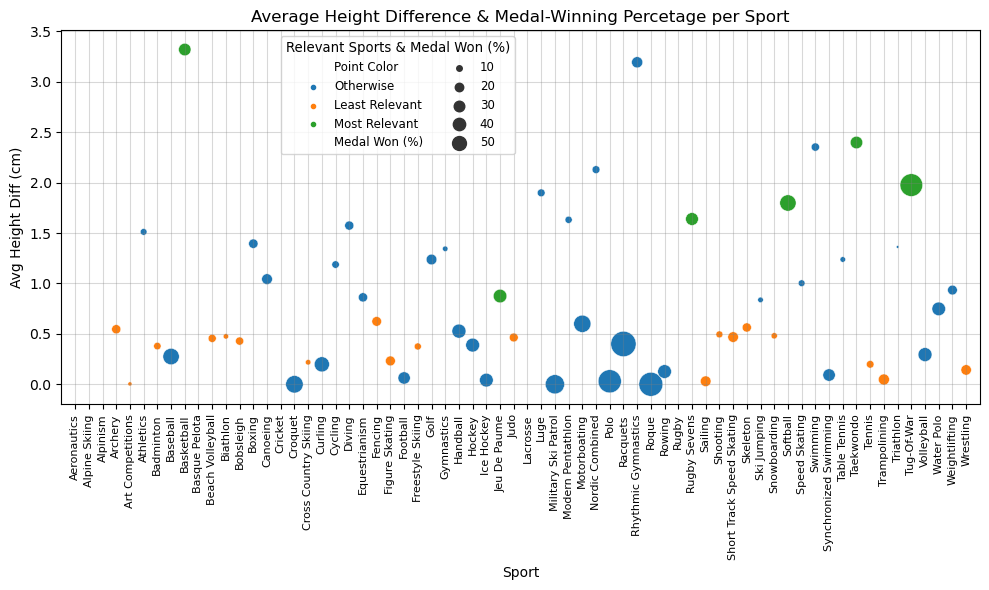

In [49]:
#Make a figure quantifying the relationship between the height difference of the two medal groups & medal-winning % for each sport

plt.figure(figsize=(10,6))
#incorporate the medal-winning % as the size of the data points, & color them according to the strength of their relationship...
    #between their height differences & medal-winning percentage
ax1 = sns.scatterplot(data=sport_medal_height_diff_counts_temp, x='sport', y='Avg Height Diff (cm)', hue='Point Color',
                      size='Medal Won (%)', sizes=(0,400))
#edit plot details
plt.title('Average Height Difference & Medal-Winning Percentage per Sport')
plt.xticks(rotation=90, fontsize=8)
plt.xlabel('Sport')
ax1.set(xlim=(-1,66.01), ylim=(-0.2, 3.51))
plt.grid(axis='both',alpha=0.3,color='gray')
legend_handles, _= ax1.get_legend_handles_labels()
plt.legend(handles=legend_handles, ncols=2, fontsize=8.5, title='Relevant Sports & Medal Won (%)', title_fontsize=9.5,
           bbox_to_anchor=(0.5,1.0), markerscale=0.5, 
           labels=['Point Color','Otherwise','Least Relevant','Most Relevant','Medal Won (%)','10','20','30','40','50'])
plt.tight_layout();


The figure above displays the difference in average height between athletes who did & did not win a medal for each sport (sometimes referred as the two "medal groups"). The size of each data point represents the number of medals won of the total number of medal-winning opportunities for each sport. The color of each data point represents sports that were previously discussed & deemed as the sports in which the relationship between the average height difference across the two medal groups & medal-winning percentage was strongest & weakest.

In this plot, larger points with a large 'Avg Height Diff (cm)' value indicates sports whose relationship across the two parameters of interest is strongest. The six sports with the strongest relationship are indicated by the green color. On the other hand, smaller points with a small 'Avg Height Diff (cm)' value indicates sports whose relationship across the two parameters of interest is weakest. These twenty sports are indicated by the orange color.

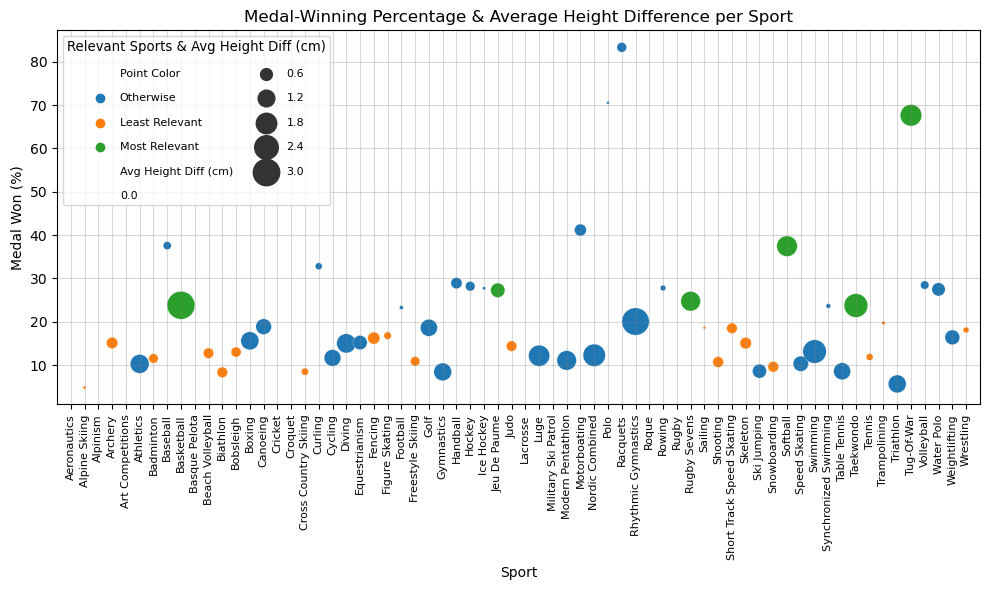

In [50]:
#Switch the 'Avg Height Diff (cm)' & 'Medal Won (%)' columns from vertical axis & point size

plt.figure(figsize=(10,6))
#incorporate the avg height diff as the size of the data points, & color them according to the strength of their relationship...
    #between their height differences & medal-winning percentage
ax1 = sns.scatterplot(data=sport_medal_height_diff_counts_temp, x='sport', size='Avg Height Diff (cm)', hue='Point Color',
                      y='Medal Won (%)', sizes=(0,400))
#edit plot details
plt.title('Medal-Winning Percentage & Average Height Difference per Sport')
plt.xticks(rotation=90, fontsize=8)
plt.xlabel('Sport')
ax1.set(xlim=(-1,66.01))
plt.grid(axis='both',alpha=0.3,color='gray')
legend_handles, _= ax1.get_legend_handles_labels()
plt.legend(handles=legend_handles, ncols=2, fontsize=8, title='Relevant Sports & Avg Height Diff (cm)', title_fontsize=9.5,
           loc='upper left', markerscale=1, labelspacing=1.3)
plt.tight_layout();


The figure above displays the medal-winning percentage for each sport. The size of each data point represents the 
difference in average height between athletes who did & did not win a medal for each sport. The color of each data point represents sports that were deemed as the sports in which the relationship between the average height difference across the two medal groups & medal-winning percentage was strongest & weakest.

In this plot, larger points with a large 'Medal Won (%)' value indicates sports whose relationship across the two parameters of interest is strongest. The six sports with the strongest relationship are indicated by the green color. On the other hand, smaller points with a small 'Medal Won (%)' value indicates sports whose relationship across the two parameters of interest is weakest. These twenty sports are indicated by the orange color.

## Conclusions - Analysis III
This section sought to determine for which sports does the height of an athlete increase their chances of earning a medal.

Various calculations were performed on the resulting data to measure statistics of the height for each sport as well as how often & how many medals were won for each sport. Of each sport, athletes were separated into those who won a medal & those who did not. Various statistics of their heights were measured & compared to determine how these statistics differed across the two groups of athletes. 
Sports in which the heights differed more across their two groups of athletes are more likely to have a relationship between an athlete's height & chance of winning a medal. If the difference in heights of the two groups is small, there is no reason to suggest that height has a considerable influence on an athlete's chances of winning a medal, regardless of how many medals were won (or not won) for each sport.

Ultimately, three parameters were created that were the most useful for this analysis. In the "sport_medal_height_diff_counts" dataframe, these parameters were '# Observations' (number of observations of data for each sport), 'Avg Height Diff (cm)' (the average difference in height in centimeters of athletes who did & did not win a medal for each sport), & 'Medal Won (%)' (the percentage of medals that were won of the the total number of opportunities for each sport). The latter two parameters were the most important in this analysis, but the '# Observations' was valuable to consider because it helped provide context as to how representative the data was for each sport. For example, data of a sport with 20,000 observations is significantly more representative & credible than a sport with only 20 observations.

Of the 'Avg Height Diff' & 'Medal Won' variables, there are four possible scenarios that were considered when attempting to determine the relationship between an athlete's height & chance of winning a medal.
- If both of these values are large, then it is more likely that an athlete's height is a considerable influence in their ability to win Olympic medals.
- If both of these values are small, then it is less likely that (or simply unclear whether) an athlete's height is a considerable influence in their ability to win Olympic medals.
- If the difference in height is large & the medal-winning percentage is small, then it is less likely that an atlete's height is a strong influence in their ability to win Olympic medals.
- If the difference in height is small & the medal-winning percetange is large, then it is more likely that an atlete's height is a weak influence in their ability to win Olympic medals.

As such, the analysis sought out the sports which had the largest (& smallest) values for each of these parameters, implying a stronger relationship of an athlete's height & chance of winning a medal. The six sports in which this relationship was strongest for (from most to least) were:
- Basketball, Taekwondo, Tug-Of-War, Softball, Rugby Sevens, & Jeu De Paume

These six sports have an average number of observations of about 1017. Jeu de paume has only 11 observations, basketball has 4536 observations, & the other four have between 170-606 observations. The years in which these sports were introduced to the Olympics are quite varying, with three first taking part in 1936 or earlier whereas the other three were only first introduced in 1996 & later. Jeu de paume & rugby sevens were only played in the 1908 & 2016 Olympic Games respectively, & so they have less representative data than the other four sports. Tug-Of-War was played between 1900-1920. All six of these sports are part of the Summer Games. More statistics of these sports can be found in the "anIII_top_sports_stats" variable.

So, of these six sports, jeu de paume & rugby sevens don't have considerably representative data. As such, the main sports of interest are: Basketball, Taekwondo, Tug-Of-War, & Softball.

The 20 sports in which this relationship was weakest for (from least to most) were:
- Art Competitions, Alpine Skiing, Sailing, Trampolining, Cross Country Skiing, Wrestling, Tennis, Figure Skating, Freestyle Skiing, Badminton, Biathlon, Snowboarding, Shooting, Beach Volleyball, Bobsleigh, Judo, Short Track Speed Skating, Skeleton, Archery, & Fencing

Of these 20 sports, they have a number of observations between 152-11,448 & an average number of about 4057. Only skeleton & trampolining have a number of observations less than 560 (199 & 152 respectively). The years in which these sports were introduced to the Olympics are quite varying. Twelve were introduced in 1936 or earlier, two were introduced in the 1960s, five were introduced in the 1990s, one was introduced in 2000. All 20 have been played as most recent as 2014 except for art competitions which was last played in 1948. Twelve of these sports occur in the Summer Games & nine take place in the Winter Games. More statistics of these sports can be found in the "anIII_bot_sports_stats" variable.

So, of these 20 sports, skeleton & trampolining don't have considerably representative data. As such, the main sports of interest (or least interest in this case) are: Art Competitions, Alpine Skiing, Sailing, Cross Country Skiing, Wrestling, Tennis, Figure Skating, Freestyle Skiing, Badminton, Biathlon, Snowboarding, Shooting, Beach Volleyball, Bobsleigh, Judo, Short Track Speed Skating, Archery, & Fencing.

Of course, additional & more sophisticated analysis could be done by involving other parameters in the dataset to see if they also play a part in the relationship between an athlete's height & their chance of winning a medal. Such parameters may include 'sex,' 'age,' 'weight,' & 'noc.' Also, this relationship could be examined over time ('year'), by 'season,' & even by 'city.'

# --------------------------------------------------------------------------------------------------------------

# Analysis IV
You are working as a data analyst for an international judo club. The owner of the club is looking for new ways to leverage data for competition. One idea they have had is to use past competition data to estimate the threat of future opponents. They have provided you with a dataset of past Olympic data and want to know whether you can use information such as the height, weight, age, and national origin of a judo competitor to estimate the probability that they will earn a medal.

You will need to prepare a report that is accessible to a broad audience. It should outline your steps, findings, and conclusions.

Firstly, it can be useful to get some contextual understanding of what judo involves as a sport. Per [_Wikipedia_](https://en.wikipedia.org/wiki/Judo), judo "is an unarmed modern Japanese martial art, combat sport, Olympic sport (since 1964), and the most prominent form of jacket wrestling competed internationally. The objective of competitive judo is to throw an opponent, immobilize them with a pin, or force an opponent to submit with a joint lock or a choke." In the Olympics, judo is split by gender as well as by weight classes. Since 1992, there have been seven different weight classes for each gender. Additionally, a mixed team event was introduced at the Tokyo 2020 Olympic Games with three weight categories for each gender; however, this dataset does not include Olympic data beyond 2016 ([_Olympics.com_](https://olympics.com/en/news/paris-2024-judo-weight-categories)).

When it comes to estimating the probability that an athlete may win a medal, it is straightforward enough to determine, though it may prove strenuous computationally. When multiple events occur, the probability of these combined events can be calculated by finding their product assuming that the events are independent. Independent events are events for which the outcome of one event does not affect the outcome of a second event. For example, if an athlete who is 25 years old competes in one Olympic event two separate times, the outcome of the second competition is independent from the outcome of the first competition.

In the case of this prompt, the judo club wants to know the probability of an athlete winning a medal by using information such as their height, weight, age, & national origin. Using the cleaned version of the provided dataset, the columns 'age,' 'height,' 'weight,' & 'noc' can be used to help calculate these probabilities. 
Regarding compiling all of the total probabilities & other accompanying statistics, one option would be to collect the data of every possible combination of these four parameters & calculate how many medals have been won & not won of these associated athletes; however, given the size of this dataset, this may not be computationally possible using a standard computer system. Alternatively, a more viable option would be to calculate how often medals are won & lost for each unique value of 'age,' 'height,' 'weight,' & 'noc' separately, then combine these probabilities for each unique combination of these four parameters. Again, merging the results of these four parameters into one larger resulting dataset may also be too computationally challenging, but in following the definition provided above, the total probability can be calculated across these four parameters even if they are kept separate & not all merged together.

Consider the following example. For an athlete who is 22 years old, 170 cm in height, 100 kg in weight, & from France ("FRA" 'noc'), the probability of such an athlete winning a medal can be calculated by finding the probability of each of the four scenarios occurring:
1) The percentage in which a 22-year-old athlete has won a medal in past Olympic games,
2) The percentage in which a 170-centimeter-tall athlete has won a medal,
3) The percentage in which a 100-kilogram-weight athlete has won a medal, &
4) The percentage in which an athlete from France has won a medal.

After determining these four probabilities, their product would yield the overall probability of such an athlete winning a medal. If the probability of the four points above are 20%, 10%, 8%, & 15% respectively, the probability of this hypothetical athlete winning a medal would be: 0.20 * 0.10 * 0.08 * 0.15 = 0.00024, or 0.024%.

This same process can be done in terms of winning any Olympic medal generally, but also for winning a specific medal (i.e. Gold, Silver, Bronze). Of course, other parameters can be incorporated into this analysis for judo athletes such as their 'sex' & the host 'city.' These probabilities could also be measured over time to see how they evolve.

It can be helpful to reassess the distributions of values across the relevant variables for this section. Doing so can help point to what parameters may have more representative data points & provide context for whatever results & conclusions are compiled. This was done both for the overall dataset & the data pertaining to judo.

,age,count
0,10,1
1,11,13
2,12,39
3,13,187
4,14,834
...,...,...
69,81,2
70,84,1
71,88,1
72,96,1


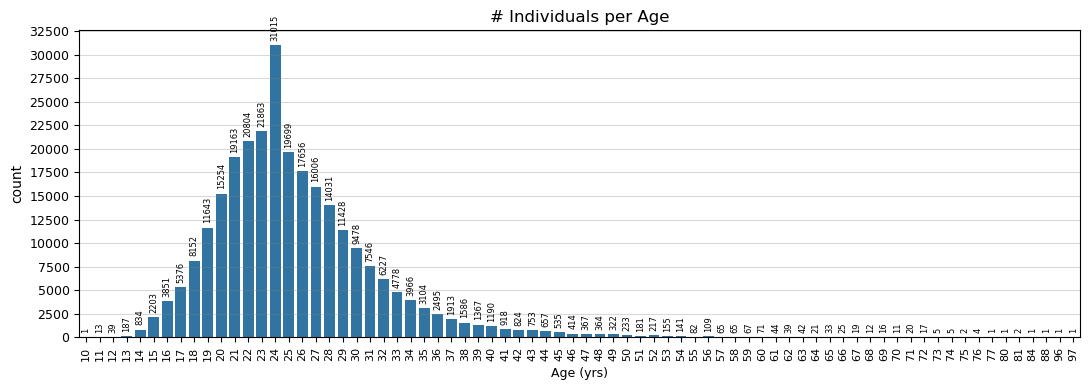

In [51]:
#First, reassess distributions of relevant columns -- AGE

#get # observations of each 'age' value
display(data['age'].value_counts(dropna=False).sort_index().reset_index())
#construct a plot of # observations per 'age' value
fig, ax = plt.subplots(figsize=(11,4))
sns.barplot(data=data['age'].value_counts(dropna=False).sort_index().reset_index(), x='age', y='count', 
            color=sns.color_palette()[0], ax=ax)
#label each age w/# observations
ax.bar_label(ax.containers[-1], labels=[f'{i}' for i in data['age'].value_counts(
                dropna=False).sort_index().reset_index()['count']], fontsize=6, rotation=90, padding=3)
#edit plot details
plt.title('# Individuals per Age')
plt.xlabel('Age (yrs)', fontsize=9)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(ticks=range(0,32501,2500), fontsize=9)
ax1.set(ylim=(0,32000))
plt.grid(axis='y',alpha=0.3,color='gray')
plt.tight_layout();

There are 74 unique 'age' values spanning from 10-97 years old. The most popular age is 24 years old.

,height,count
0,127,7
1,128,1
2,130,2
3,131,2
4,132,9
...,...,...
90,219,2
91,220,6
92,221,4
93,223,4


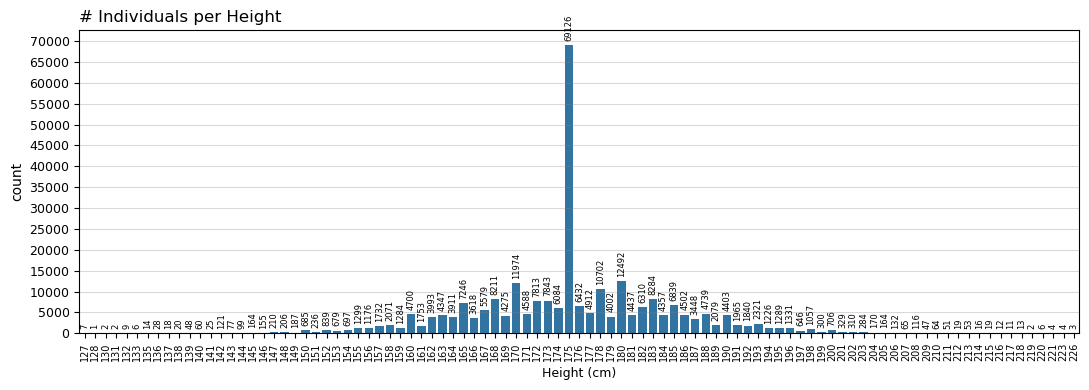

In [52]:
#HEIGHT

#get # observations of each 'height' value
display(data['height'].value_counts(dropna=False).sort_index().reset_index())
#construct a plot of # observations per 'height' value
fig, ax = plt.subplots(figsize=(11,4))
sns.barplot(data=data['height'].value_counts(dropna=False).sort_index().reset_index(), x='height', y='count', 
            color=sns.color_palette()[0], ax=ax)
#label each height w/# observations
ax.bar_label(ax.containers[-1], labels=[f'{i}' for i in data['height'].value_counts(
                    dropna=False).sort_index().reset_index()['count']], fontsize=6, rotation=90, padding=3)
#edit plot details
plt.title('# Individuals per Height', loc='left')
plt.xlabel('Height (cm)', fontsize=9)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(ticks=range(0,70001,5000), fontsize=9)
ax1.set(ylim=(0,72000))
plt.grid(axis='y',alpha=0.3,color='gray')
plt.tight_layout();


There are 95 unique 'height' values spanning 127-226 centimeters. The most popular height is 175 cm.

,weight,count
0,25.0,6
1,28.0,14
2,30.0,42
3,31.0,23
4,32.0,41
...,...,...
215,180.0,1
216,182.0,2
217,190.0,1
218,198.0,1


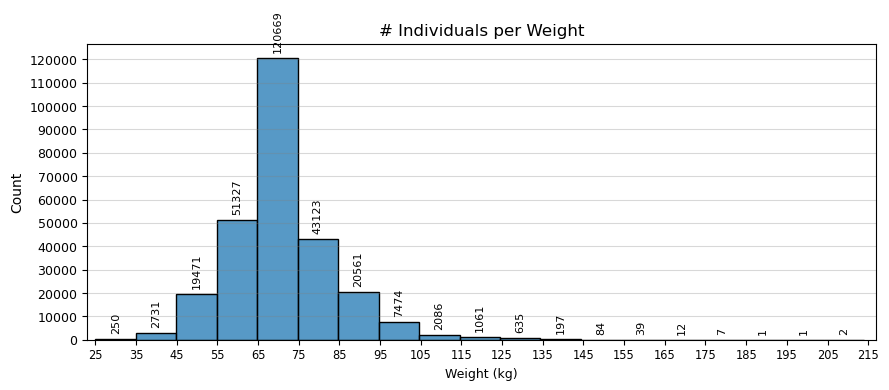

In [53]:
#WEIGHT

#get # observations of each 'weight' value
display(data['weight'].value_counts(dropna=False).sort_index().reset_index())
#construct a plot of # observations per 'weight' value
plt.figure(figsize=(9,4))
ax1 = sns.histplot(data['weight'], bins=19, color=sns.color_palette()[0])
#label each weight w/# observations
ax1.bar_label(ax1.containers[-1], fontsize=8, rotation=90, padding=4)
#edit plot details
plt.title('# Individuals per Weight')
plt.xlabel('Weight (kg)', fontsize=9)
plt.xticks(ticks=range(25,216,10), fontsize=8.2)
plt.yticks(ticks=range(0,120001,10000), fontsize=9)
ax1.set(xlim=(23,217))
plt.grid(axis='y',alpha=0.3,color='gray')
plt.tight_layout();


There are 220 unique 'weight' values spanning from 25-214 kilograms. The most popular weight is 70 kg. The plot above was made into a histogram with 19 bins because there are too many unique 'weight' values for the plot to be reasonably legible.

In terms of athletes' national origin, there are 230 unique 'noc' values (reference the "noc_counts" variable). There are two observations with the "UNK" 'noc' value ('team' = "unknown").

Now, reassess distributions of these parameters for judo-specific data points.

In [54]:
#Verify some things
#check observations pertaining to judo
    #display(data[data.sport.str.contains('Judo')])
    #display(data[data.event.str.contains('Judo')])
    #both have 3801 rows

#get judo-related data
judo_data = data[data.sport.str.contains('Judo')].reset_index(drop=True)
#display(judo_data.info())

#examine the relevant columns & their values
for i in judo_data[['year','age','height','weight','noc','medal']]:
    display(judo_data[i].value_counts(dropna=False).sort_index())

#check # observations for each unique judo event
display(judo_data['event'].value_counts(dropna=False).head(15))


year
1964     72
1972    166
1976    154
1980    193
1984    212
1988    243
1992    433
1996    387
2000    398
2004    384
2008    386
2012    384
2016    389
Name: count, dtype: int64

age
14      1
15      1
16     11
17     25
18     61
19    103
20    171
21    250
22    308
23    350
24    419
25    397
26    349
27    283
28    308
29    217
30    173
31    120
32     97
33     62
34     40
35     22
36     12
37      7
38      6
39      3
40      2
42      2
43      1
Name: count, dtype: int64

height
143    1
145    1
146    5
147    1
148    1
      ..
203    6
204    2
205    3
210    1
213    4
Name: count, Length: 63, dtype: int64

weight
46.0       2
47.0       1
48.0     112
48.5       1
49.0       2
        ... 
175.0      1
178.0      1
180.0      1
198.0      1
214.0      2
Name: count, Length: 124, dtype: int64

noc
AFG     3
AHO     3
ALB     2
ALG    52
AND     6
       ..
YEM     8
YMD     0
YUG    24
ZAM    12
ZIM     7
Name: count, Length: 230, dtype: int64

medal
Gold       137
Silver     136
Bronze     274
None      3254
Name: count, dtype: int64

event
Judo Men's Lightweight            429
Judo Men's Middleweight           403
Judo Men's Half-Middleweight      402
Judo Men's Half-Lightweight       355
Judo Men's Half-Heavyweight       355
Judo Men's Extra-Lightweight      341
Judo Men's Heavyweight            332
Judo Women's Half-Middleweight    172
Judo Women's Lightweight          160
Judo Women's Half-Lightweight     159
Judo Women's Middleweight         155
Judo Women's Extra-Lightweight    155
Judo Women's Half-Heavyweight     147
Judo Women's Heavyweight          145
Judo Men's Open Class              91
Name: count, dtype: int64

There are 3,801 observations pertaining to judo. The sport was first played in the Olympics in 1964.

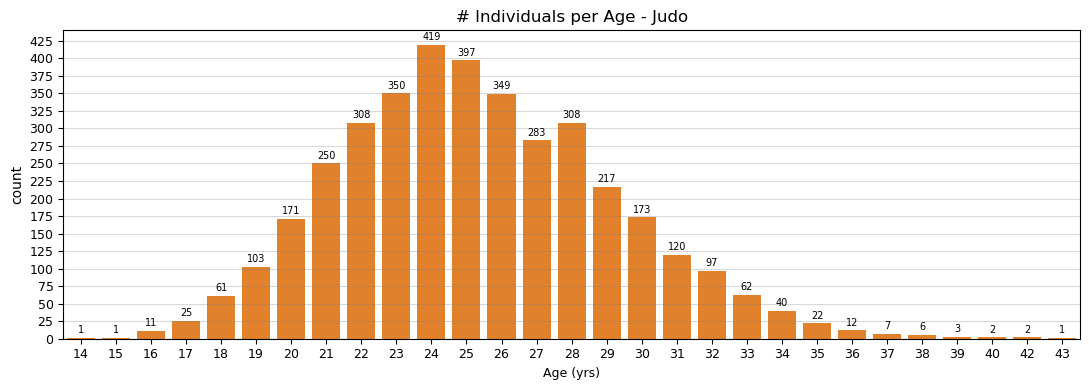

In [55]:
#Visualize distributions of columns of interest for judo data -- AGE

#get # observations of each 'age' value
    #display(judo_data['age'].value_counts(dropna=False).sort_index().reset_index())
#construct a plot of # observations per 'age' value
fig, ax = plt.subplots(figsize=(11,4))
sns.barplot(data=judo_data['age'].value_counts(dropna=False).sort_index().reset_index(), x='age', y='count', color=sns.color_palette()[1], ax=ax)
#label each age w/# observations
ax.bar_label(ax.containers[-1], labels=[f'{i}' for i in judo_data['age'].value_counts(dropna=False).sort_index().reset_index()['count']],
             fontsize=7, rotation=0, padding=2)
#edit plot details
plt.title('# Individuals per Age - Judo')
plt.xlabel('Age (yrs)', fontsize=9)
plt.xticks(fontsize=9, rotation=0)
plt.yticks(ticks=range(0,426,25), fontsize=9)
ax1.set(ylim=(0,430))
plt.grid(axis='y',alpha=0.3,color='gray')
plt.tight_layout();


For athletes that have competed in judo events, there are 29 unique 'age' values spanning from 14-43 years old. The most popular age is 24 years old.

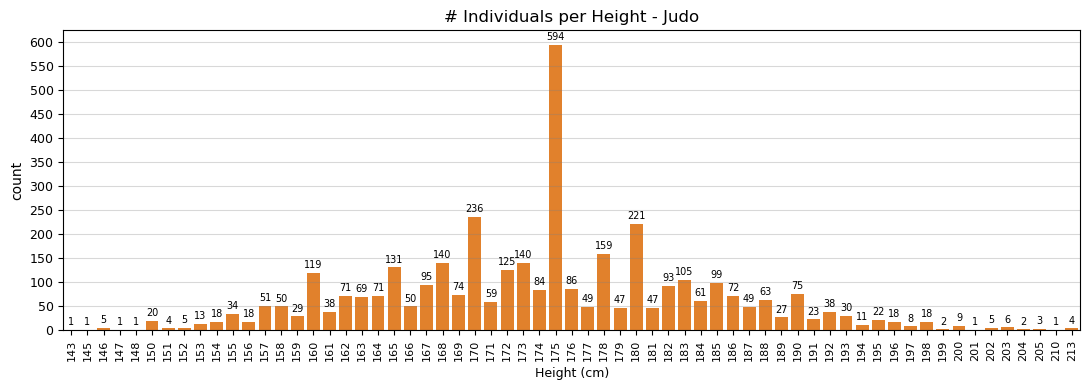

In [56]:
#HEIGHT

#get # observations of each 'height' value
    #display(judo_data['height'].value_counts(dropna=False).sort_index().reset_index())
#construct a plot of # observations per 'height' value
fig, ax = plt.subplots(figsize=(11,4))
sns.barplot(data=judo_data['height'].value_counts(dropna=False).sort_index().reset_index(), x='height', y='count', color=sns.color_palette()[1], ax=ax)
#label each height w/# observations
ax.bar_label(ax.containers[-1], labels=[f'{i}' for i in judo_data['height'].value_counts(dropna=False).sort_index().reset_index()['count']],
             fontsize=7, rotation=0, padding=2)
#edit plot details
plt.title('# Individuals per Height - Judo')
plt.xlabel('Height (cm)', fontsize=9)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(ticks=range(0,601,50), fontsize=9)
ax1.set(ylim=(0,605))
plt.grid(axis='y',alpha=0.3,color='gray')
plt.tight_layout();


For athletes that have competed in judo events, there are 63 unique 'height' values spanning from 143-213 centimeters. The most popular height is 175 cm.

,weight,count
0,46.0,2
1,47.0,1
2,48.0,112
3,48.5,1
4,49.0,2
...,...,...
119,175.0,1
120,178.0,1
121,180.0,1
122,198.0,1


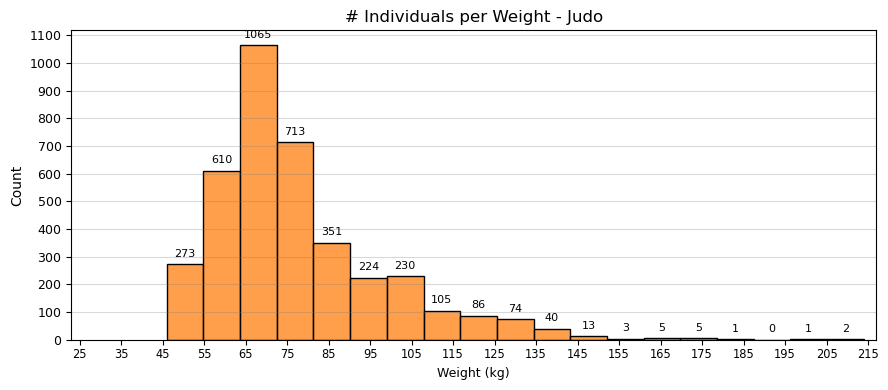

In [57]:
#WEIGHT

#get # observations of each 'weight' value
display(judo_data['weight'].value_counts(dropna=False).sort_index().reset_index())
#construct a plot of # observations per 'weight' value
plt.figure(figsize=(9,4))
ax1 = sns.histplot(judo_data['weight'], bins=19, color=sns.color_palette()[1])
#label each weight w/# observations
ax1.bar_label(ax1.containers[-1], fontsize=8, rotation=0, padding=4)
#edit plot details
plt.title('# Individuals per Weight - Judo')
plt.xlabel('Weight (kg)', fontsize=9)
plt.xticks(ticks=range(25,216,10), fontsize=8.2)
plt.yticks(ticks=range(0,1101,100), fontsize=9)
ax1.set(xlim=(23,217))
plt.grid(axis='y',alpha=0.3,color='gray')
plt.tight_layout();


For athletes that have competed in judo events, there are 124 unique 'weight' values spanning from 46-214 kilograms. The most popular height is 70 kg. The plot above was made into a histogram with 19 bins because there are too many unique 'weight' values for a single plot to be reasonably legible.

In [58]:
#get # observations per 'noc' for judo data
judo_noc_counts = judo_data['noc'].value_counts(dropna=False).sort_index().reset_index().rename(columns={'count':'#'}).sort_values('#')
judo_noc_counts_no0 = judo_noc_counts.drop(judo_noc_counts[judo_noc_counts['#'] == 0].index).reset_index(drop=True)
display(judo_noc_counts_no0)


,noc,#
0,GAM,1
1,RWA,1
2,GBS,1
3,CAM,1
4,PLW,1
...,...,...
175,GBR,111
176,KOR,119
177,BRA,120
178,JPN,129


There are 180 unique 'noc's that have observations pertaining to judo (50 'noc's do not).

The parameters of interest were combined into different combinations using the `pandas.groupby()` function to try & evaluate how many unique combinations there are across the unique values of each parameter. This process of performing large-scale calculations & aggregations indicated that attempting to combine everything into a single dataframe may be too computationally intensive to handle. For example, when performing this function on the four columns 'age,' 'height,' 'weight,' & 'noc,' the result had over 52 million rows. If this dataset were used to calculate probabilities & other such statistics, it may take the system a significant amount of time if it can even complete it.

In [59]:
#try grouping by each of the parameters to check their sizes & computation times

display(judo_data.groupby(['age','height','medal']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'}).sort_values(
    '#',ascending=False))

#display(judo_data.groupby(['age','weight']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'}).sort_values('#',ascending=False))

#display(judo_data.groupby(['height','weight']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'}).sort_values('#',ascending=False))

#display(judo_data.groupby(['age','height','weight']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'}).sort_values('#',ascending=False))

#display(judo_data.groupby(['age','height','weight','noc']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'}).sort_values('#',ascending=False))
    #produces 52M rows....

#display(judo_data.groupby(['age','height','weight','medal']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'}).sort_values('#',ascending=False))


,age,height,medal,#
2643,24,175,None,82
2391,23,175,None,51
2895,25,175,None,47
2139,22,175,None,42
3147,26,175,None,42
...,...,...,...,...
2522,24,143,Bronze,0
2521,24,143,Silver,0
2520,24,143,Gold,0
2519,23,213,None,0


Across the five relevant parameters ('age,' 'height,' 'weight,' 'noc', &  either of the two medal-related variables), there are multiple possibilities when aggregating the combinations of every unique value for each parameter. These possible combinations are listed below.
- 1 parameter:
    - age & medal/medal?
    - height & medal/medal?
    - weight & medal/medal?
    - noc & medal/medal?
- 2 parameters:
    - age, height, & medal/medal?
    - age, weight, & medal/medal?
    - age, noc, & medal/medal?
    - height, weight, & medal/medal?
    - height, noc, & medal/medal?
    - weight, noc, & medal/medal?
- 3 parameters:
    - age, height, weight, & medal/medal?
    - age, height, noc, & medal/medal?
    - age, weight, noc, & medal/medal?
    - height, weight, noc, & medal/medal?
- 4 parameters:
    - age, height, weight, noc, & medal/medal?

The more parameters that are involved will require more computational power & time to perform calculations.

Before calculating total probabilities for all of the relevant parameters, the medal-winning probabilities for each unique value of each parameter should be calculated. Probabilities were calculated for each value of age, height, weight, & noc across the two medal-related parameters 'medal' & 'medal?,' which indicate what medal was won & if a medal was won respectively. With these variables, statistics can be determined for each distinct medal & for all Olympic medals, which can then be used to calculate probabilities of winning a gold, silver, bronze, &/or any Olympic medal.

In [60]:
#Calculate medal probabilities per age & medal for judo

#for each medal (gold, silver, bronze)
judo_age_medal_I = judo_data.groupby(['age','medal']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})
#for no medal or any medal
judo_age_medal_II = judo_data.groupby(['age','medal?']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})

#rearrange the data
judo_age_medal_I = judo_age_medal_I.pivot(index='age', columns='medal', values='#')
judo_age_medal_II = judo_age_medal_II.pivot(index='age', columns='medal?', values='#')

#need to fill some null values
judo_age_medal_II = judo_age_medal_II.fillna(0)

#sum # observations & calculate probability of each medal per age
for i in judo_age_medal_I.index:
    judo_age_medal_I.loc[i,'# Observations'] = judo_age_medal_I.loc[i,:].sum(axis=0)
    judo_age_medal_I.loc[i,'Gold Prob. (%)'] = np.round((judo_age_medal_I.loc[i,'Gold'] / judo_age_medal_I.loc[i,'# Observations'])*100,2)
    judo_age_medal_I.loc[i,'Silver Prob. (%)'] = np.round((judo_age_medal_I.loc[i,'Silver'] / judo_age_medal_I.loc[i,'# Observations'])*100,2)
    judo_age_medal_I.loc[i,'Bronze Prob. (%)'] = np.round((judo_age_medal_I.loc[i,'Bronze'] / judo_age_medal_I.loc[i,'# Observations'])*100,2)
#sum # observations & calculate probability of winning a medal per age
for i in judo_age_medal_II.index:
    judo_age_medal_II.loc[i,'# Observations'] = judo_age_medal_II.loc[i,:].sum(axis=0)
    judo_age_medal_II.loc[i,'Medal Prob. (%)'] = np.round((judo_age_medal_II.loc[i,'Yes'] / judo_age_medal_II.loc[i,'# Observations'])*100,2)

#change data type of some columns
judo_age_medal_I['# Observations'] = judo_age_medal_I['# Observations'].astype('int')
judo_age_medal_II[['No','Yes']] = judo_age_medal_II[['No','Yes']].astype('int')
judo_age_medal_II['# Observations'] = judo_age_medal_II['# Observations'].astype('int')

judo_age_medal_I = judo_age_medal_I.reset_index()
judo_age_medal_II = judo_age_medal_II.reset_index()

#merge the two dataframes
judo_age_medal = judo_age_medal_I.merge(judo_age_medal_II[['age','No','Yes','Medal Prob. (%)']] , on='age')

#reorganize columns
judo_age_medal = judo_age_medal[['age','Gold','Silver','Bronze','Yes','None','# Observations','Gold Prob. (%)', 'Silver Prob. (%)',
                                'Bronze Prob. (%)', 'Medal Prob. (%)']].rename(columns={'Yes':'Medals Won','None':'Medals Not Won'})
display(judo_age_medal)
#save file for external use
#judo_age_medal.to_csv('judo_age_medal.csv')


,age,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
0,14,0,0,0,0,1,1,0.00,0.00,0.00,0.00
1,15,0,0,0,0,1,1,0.00,0.00,0.00,0.00
2,16,1,1,0,2,9,11,9.09,9.09,0.00,18.18
3,17,1,0,0,1,24,25,4.00,0.00,0.00,4.00
4,18,0,1,4,5,56,61,0.00,1.64,6.56,8.20
5,19,0,2,6,8,95,103,0.00,1.94,5.83,7.77
6,20,5,4,11,20,151,171,2.92,2.34,6.43,11.70
7,21,8,7,14,29,221,250,3.20,2.80,5.60,11.60
8,22,17,9,24,50,258,308,5.52,2.92,7.79,16.23
9,23,15,13,32,60,290,350,4.29,3.71,9.14,17.14


In [61]:
#Calculate medal probabilities per height & medal for judo

#for each medal
judo_height_medal_I = judo_data.groupby(['height','medal']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})
#for no medal or any medal
judo_height_medal_II = judo_data.groupby(['height','medal?']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})

#rearrange the data
judo_height_medal_I = judo_height_medal_I.pivot(index='height', columns='medal', values='#')
judo_height_medal_II = judo_height_medal_II.pivot(index='height', columns='medal?', values='#')

#need to fill some null values
judo_height_medal_II = judo_height_medal_II.fillna(0)

#sum # observations & calculate probability of each medal per height
for i in judo_height_medal_I.index:
    judo_height_medal_I.loc[i,'# Observations'] = judo_height_medal_I.loc[i,:].sum(axis=0)
    judo_height_medal_I.loc[i,'Gold Prob. (%)'] = np.round((judo_height_medal_I.loc[i,'Gold'] / judo_height_medal_I.loc[i,'# Observations'])*100,2)
    judo_height_medal_I.loc[i,'Silver Prob. (%)'] = np.round((judo_height_medal_I.loc[i,'Silver'] / judo_height_medal_I.loc[i,'# Observations'])*100,2)
    judo_height_medal_I.loc[i,'Bronze Prob. (%)'] = np.round((judo_height_medal_I.loc[i,'Bronze'] / judo_height_medal_I.loc[i,'# Observations'])*100,2)
#sum # observations & calculate probability of winning a medal per height
for i in judo_height_medal_II.index:
    judo_height_medal_II.loc[i,'# Observations'] = judo_height_medal_II.loc[i,:].sum(axis=0)
    judo_height_medal_II.loc[i,'Medal Prob. (%)'] = np.round((judo_height_medal_II.loc[i,'Yes'] / judo_height_medal_II.loc[i,'# Observations'])*100,2)

#change data type of some columns
judo_height_medal_I['# Observations'] = judo_height_medal_I['# Observations'].astype('int')
judo_height_medal_II[['No','Yes']] = judo_height_medal_II[['No','Yes']].astype('int')
judo_height_medal_II['# Observations'] = judo_height_medal_II['# Observations'].astype('int')

judo_height_medal_I = judo_height_medal_I.reset_index()
judo_height_medal_II = judo_height_medal_II.reset_index()

#merge the two dataframes
judo_height_medal = judo_height_medal_I.merge(judo_height_medal_II[['height','No','Yes','Medal Prob. (%)']] , on='height')

#reorganize columns
judo_height_medal = judo_height_medal[['height','Gold','Silver','Bronze','Yes','None','# Observations','Gold Prob. (%)', 'Silver Prob. (%)',
                                'Bronze Prob. (%)', 'Medal Prob. (%)']].rename(columns={'Yes':'Medals Won','None':'Medals Not Won'})
display(judo_height_medal)
#save file for external use
#judo_height_medal.to_csv('judo_height_medal.csv')


,height,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
0,143,0,0,0,0,1,1,0.00,0.0,0.0,0.00
1,145,0,0,0,0,1,1,0.00,0.0,0.0,0.00
2,146,2,2,1,5,0,5,40.00,40.0,20.0,100.00
3,147,0,0,0,0,1,1,0.00,0.0,0.0,0.00
4,148,0,0,0,0,1,1,0.00,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...
58,203,2,0,3,5,1,6,33.33,0.0,50.0,83.33
59,204,0,0,0,0,2,2,0.00,0.0,0.0,0.00
60,205,0,0,0,0,3,3,0.00,0.0,0.0,0.00
61,210,0,0,0,0,1,1,0.00,0.0,0.0,0.00


In [62]:
#Calculate medal probabilities per weight & medal for judo

#for each medal
judo_weight_medal_I = judo_data.groupby(['weight','medal']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})
#for no medal or any medal
judo_weight_medal_II = judo_data.groupby(['weight','medal?']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})

#rearrange the data
judo_weight_medal_I = judo_weight_medal_I.pivot(index='weight', columns='medal', values='#')
judo_weight_medal_II = judo_weight_medal_II.pivot(index='weight', columns='medal?', values='#')

#need to fill some null values
judo_weight_medal_II = judo_weight_medal_II.fillna(0)

#sum # observations & calculate probability of each medal per weight
for i in judo_weight_medal_I.index:
    judo_weight_medal_I.loc[i,'# Observations'] = judo_weight_medal_I.loc[i,:].sum(axis=0)
    judo_weight_medal_I.loc[i,'Gold Prob. (%)'] = np.round((judo_weight_medal_I.loc[i,'Gold'] / judo_weight_medal_I.loc[i,'# Observations'])*100,2)
    judo_weight_medal_I.loc[i,'Silver Prob. (%)'] = np.round((judo_weight_medal_I.loc[i,'Silver'] / judo_weight_medal_I.loc[i,'# Observations'])*100,2)
    judo_weight_medal_I.loc[i,'Bronze Prob. (%)'] = np.round((judo_weight_medal_I.loc[i,'Bronze'] / judo_weight_medal_I.loc[i,'# Observations'])*100,2)
#sum # observations & calculate probability of winning a medal per weight
for i in judo_weight_medal_II.index:
    judo_weight_medal_II.loc[i,'# Observations'] = judo_weight_medal_II.loc[i,:].sum(axis=0)
    judo_weight_medal_II.loc[i,'Medal Prob. (%)'] = np.round((judo_weight_medal_II.loc[i,'Yes'] / judo_weight_medal_II.loc[i,'# Observations'])*100,2)

#change data type of some columns
judo_weight_medal_I['# Observations'] = judo_weight_medal_I['# Observations'].astype('int')
judo_weight_medal_II[['No','Yes']] = judo_weight_medal_II[['No','Yes']].astype('int')
judo_weight_medal_II['# Observations'] = judo_weight_medal_II['# Observations'].astype('int')

judo_weight_medal_I = judo_weight_medal_I.reset_index()
judo_weight_medal_II = judo_weight_medal_II.reset_index()

#merge the two dataframes
judo_weight_medal = judo_weight_medal_I.merge(judo_weight_medal_II[['weight','No','Yes','Medal Prob. (%)']] , on='weight')

#reorganize columns
judo_weight_medal = judo_weight_medal[['weight','Gold','Silver','Bronze','Yes','None','# Observations','Gold Prob. (%)', 'Silver Prob. (%)',
                                'Bronze Prob. (%)', 'Medal Prob. (%)']].rename(columns={'Yes':'Medals Won','None':'Medals Not Won'})
display(judo_weight_medal)
#save file for external use
#judo_weight_medal.to_csv('judo_weight_medal.csv')


,weight,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
0,46.0,0,0,0,0,2,2,0.00,0.00,0.00,0.00
1,47.0,0,0,0,0,1,1,0.00,0.00,0.00,0.00
2,48.0,5,7,9,21,91,112,4.46,6.25,8.04,18.75
3,48.5,0,0,0,0,1,1,0.00,0.00,0.00,0.00
4,49.0,0,0,0,0,2,2,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...
119,175.0,0,0,1,1,0,1,0.00,0.00,100.00,100.00
120,178.0,0,0,0,0,1,1,0.00,0.00,0.00,0.00
121,180.0,0,0,0,0,1,1,0.00,0.00,0.00,0.00
122,198.0,0,0,0,0,1,1,0.00,0.00,0.00,0.00


In [63]:
#Calculate medal probabilities per noc & medal for judo

#for each medal
judo_noc_medal_I = judo_data.groupby(['noc','medal']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})
#for no medal or any medal
judo_noc_medal_II = judo_data.groupby(['noc','medal?']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})

#rearrange the data
judo_noc_medal_I = judo_noc_medal_I.pivot(index='noc', columns='medal', values='#')
judo_noc_medal_II = judo_noc_medal_II.pivot(index='noc', columns='medal?', values='#')

#need to fill some null values
judo_noc_medal_II = judo_noc_medal_II.fillna(0)

#sum # observations & calculate probability of each medal per noc
for i in judo_noc_medal_I.index:
    judo_noc_medal_I.loc[i,'# Observations'] = judo_noc_medal_I.loc[i,:].sum(axis=0)
    judo_noc_medal_I.loc[i,'Gold Prob. (%)'] = np.round((judo_noc_medal_I.loc[i,'Gold'] / judo_noc_medal_I.loc[i,'# Observations'])*100,2)
    judo_noc_medal_I.loc[i,'Silver Prob. (%)'] = np.round((judo_noc_medal_I.loc[i,'Silver'] / judo_noc_medal_I.loc[i,'# Observations'])*100,2)
    judo_noc_medal_I.loc[i,'Bronze Prob. (%)'] = np.round((judo_noc_medal_I.loc[i,'Bronze'] / judo_noc_medal_I.loc[i,'# Observations'])*100,2)
#sum # observations & calculate probability of winning a medal per noc
for i in judo_noc_medal_II.index:
    judo_noc_medal_II.loc[i,'# Observations'] = judo_noc_medal_II.loc[i,:].sum(axis=0)
    judo_noc_medal_II.loc[i,'Medal Prob. (%)'] = np.round((judo_noc_medal_II.loc[i,'Yes'] / judo_noc_medal_II.loc[i,'# Observations'])*100,2)

#change data type of some columns
judo_noc_medal_I['# Observations'] = judo_noc_medal_I['# Observations'].astype('int')
judo_noc_medal_II[['No','Yes']] = judo_noc_medal_II[['No','Yes']].astype('int')
judo_noc_medal_II['# Observations'] = judo_noc_medal_II['# Observations'].astype('int')

#fill some null values
judo_noc_medal_I = judo_noc_medal_I.fillna(0).reset_index()
judo_noc_medal_II = judo_noc_medal_II.fillna(0).reset_index()

#merge the two dataframes
judo_noc_medal = judo_noc_medal_I.merge(judo_noc_medal_II[['noc','No','Yes','Medal Prob. (%)']] , on='noc')

#reorganize columns
judo_noc_medal = judo_noc_medal[['noc','Gold','Silver','Bronze','Yes','None','# Observations','Gold Prob. (%)', 'Silver Prob. (%)',
                                'Bronze Prob. (%)', 'Medal Prob. (%)']].rename(columns={'Yes':'Medals Won','None':'Medals Not Won'})
display(judo_noc_medal)
#save file for external use
judo_noc_medal.to_csv('judo_noc_medal.csv')


,noc,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
0,AFG,0,0,0,0,3,3,0.0,0.00,0.00,0.00
1,AHO,0,0,0,0,3,3,0.0,0.00,0.00,0.00
2,ALB,0,0,0,0,2,2,0.0,0.00,0.00,0.00
3,ALG,0,1,1,2,50,52,0.0,1.92,1.92,3.85
4,AND,0,0,0,0,6,6,0.0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...
225,YEM,0,0,0,0,8,8,0.0,0.00,0.00,0.00
226,YMD,0,0,0,0,0,0,0.0,0.00,0.00,0.00
227,YUG,0,0,2,2,22,24,0.0,0.00,8.33,8.33
228,ZAM,0,0,0,0,12,12,0.0,0.00,0.00,0.00


Now that the probabilities of each unique value of age, height, weight, & noc have been calculated, it is possible to determine total probabilities for each distinct combination of values across these parameters. Before doing so, there are a few factors that need to be considered.

As discussed previously, given the depth of the relevant data, it may not be possible to completely determine statistics & probabilities for each unique combination of age, height, weight, & noc. Firstly, it should be assessed whether or not this process is feasible (if so, to what degree?), & other methods need to be explored such as trying to merge data together or avoiding huge aggregate calculations &/or merges of data. In other words, should the recently calculated dataframes for age, height, weight, & noc (e.g. "judo_age_medal") be merged together into one dataset, or would it be more feasible to access certain values from each dataset separately & then calculate the total probability for whatever combination of parameters are of interest.

Additionally, depending on what process is utilized, it is possible that some of the unique values across the four relevant parameters are left out because they may not have any associated data. For example, given how many unique combinations there are across these parameters & that there are only about 3,800 data points pertaining to judo, it is likely inevitable that some combinations won't have any corresponding data, & so they may not be included in any aggregate calculations or merges. Such data, however, is useful to have & therefore making sure it is included in any final dataset is an important point to keep in mind for constructing the code that follows.

To combine all the probabilities of each unique combination of every value across 'age,' 'height,' 'weight,' & 'noc,' a couple of different methodologies could be used.
1) A complex, nested for loop could be used that loops through each value of 'age,' 'height,' 'weight,' 'noc,' & 'medal'/'medal?' to create every possible combination of these values. For each of these combinations, the number of observations in the dataset can be totaled, the number of medals won can be totaled, & the probabilities of winning a (or any) medal, gold medal, silver medal, & bronze medal can be calculated.
    - To access the probabilities of interest, it would require only one line of code such as something along the lines of: `_dataframe_[(_dataframe_['age'] == _age_) & (_dataframe_['height'] == _height_) & (_dataframe_['weight'] == _weight_) & (_dataframe_['noc'] == _noc_)]`.
2) With the four dataframes previously calculated (e.g. "judo_age_medal"), they can be compiled/merged into a single dataframe that has every unique combination of every value across each of the parameters. This would contain each of the medal-winning probabilities for each of the four parameters which can be used to calculate the total probability for each unique age-height-weight-noc combination.
    - To access the probabilities of interest, it would require only one line of code such as something along the lines of: `_dataframe_[(_dataframe_['age'] == _age_) & (_dataframe_['height'] == _height_) & (_dataframe_['weight'] == _weight_) & (_dataframe_['noc'] == _noc_)]`.
3) Instead of compiling everything into a dataframe with the millions of unique combinations of the values of these parameters, the four dataframes previously calculated can be used separately to access the medal-winning probabilities for whatever values of age, height, weight, & national origin an athlete may have. These probabilities can then be used to calculate the total probability for an athlete to win a medal. Though this process is slightly more tedious, it does not require the computationally-intensive & time-consuming calculations as the former two methodologies would.
    - To access the probabilities of interest, it would require multiple lines of code likely involving something along the lines of:
        - `_age-dataframe_[age-dataframe['age'] == _age_]`
        - `_height-dataframe_[height-dataframe['height'] == _height_]`
        - `_weight-dataframe_[weight-dataframe['weight'] == _weight_]`
        - `_noc-dataframe_[noc-dataframe['noc'] == _noc_]`
    - These four filters would return any associated data & their probabilities for that specific parameter, resulting in four groups of data. Then, the respective probabilities would have to be taken & be multiplied by one another, creating a product of four probabilities to yield one total probability for whatever subset of probabilities are desired (e.g. 'Medal Prob. (%)' for winning any medal, or 'Gold Prob. (%)' for winning a gold medal). An example of code of such a product is shown below.
        - `(_age-dataframe_[age-dataframe['age'] == _age_]['Gold Prob. (%)']/100) * (_height-dataframe_[height-dataframe['height'] == _height_]['Gold Prob. (%)']/100) * (_weight-dataframe_[weight-dataframe['weight'] == _weight_]['Gold Prob. (%)']/100) * (_noc-dataframe_[noc-dataframe['noc'] == _noc_]['Gold Prob. (%)']/100)`
        - This value could be multiplied by 100 to get the total probability as a percentage.

Each of these three methodologies was trialed below.

Another alternative could involve taking the 'age,' 'height,' & 'weight' parameters & splitting them into ranges of values. Rather than performing calculations for each unique value & combination across the parameters, the values of these three parameters could be grouped into ranges of values. Doing so would result in less total unique combinations across the four parameters & therefore less computational resources, making methods 1 & 2 potentially more viable; however, it would sacrifice precision because it wouldn't account for every possible judo athlete's unique age, height, weight, & national origin. Ultimately, these processes & the viability would probably depend on the sizes of these ranges of 'age,' 'height,' & 'weight.'

In [64]:
#Want to combine probabilities
    #have to get every possible combination of age, height, weight, noc -- ~52.1M unique combinations
judo_AHWN = judo_data.groupby(['age','height','weight','noc']).count().iloc[:,:1].reset_index().rename(columns={'id':'# Athletes'})


In [65]:
#display this variable
display(judo_AHWN)


,age,height,weight,noc,# Athletes
0,14,143,46.0,AFG,0
1,14,143,46.0,AHO,0
2,14,143,46.0,ALB,0
3,14,143,46.0,ALG,0
4,14,143,46.0,AND,0
...,...,...,...,...,...
52106035,43,213,214.0,YEM,0
52106036,43,213,214.0,YMD,0
52106037,43,213,214.0,YUG,0
52106038,43,213,214.0,ZAM,0


In [66]:
#METHOD 1): A COMPLEX, NESTED FOR LOOP
    #takes forever for just a couple of observations to be computed -- TOO MUCH COMPUTATION TO HANDLE

#for i_A, row_A in judo_age_medal.head(1).iterrows():
#    display(i, row)
#    for i_H, row_H in judo_height_medal.head(2).iterrows():
#        for i_W, row_W in judo_weight_medal.head(3).iterrows():
#            for i_N, row_N in judo_noc_medal.head(4).iterrows():
#                for i_all, row_all in judo_AHWN.iterrows():
                    #find row for each combo of age, height, weight, noc
#                    if row_all['age'] == row_A['age'] and row_all['height'] == row_H['height'] and row_all['weight'] == row_W['weight'] and row_all['noc'] == row_N['noc']:
#                        display(i_all, row_all)
#                        judo_AHWN.loc[i_all,'Medal Prob.(%)'] = ((row_A['Medal Prob. (%)'] /100) * (row_H['Medal Prob. (%)'] /100) * (row_H['Medal Prob. (%)'] /100) * (row_N['Medal Prob. (%)'] /100))*100
                        


In [67]:
#METHOD 2): MERGE 4 DATAFRAMES FOR EACH PARAMETER & EDIT RESULTING DATA ACCORDINGLY

#merge age probabilities w/every unique combination of age-height-weight-noc values
judo_AHWN_merging_A = judo_AHWN.merge(judo_age_medal[['age','Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)']],
                                   on='age').rename(columns={'Gold Prob. (%)':'GP A','Silver Prob. (%)':'SP A',
                                                             'Bronze Prob. (%)':'BP A','Medal Prob. (%)':'MP A'})


In [68]:
#check result of "judo_AHWN_merging_A" -- ~52M rows
display(judo_AHWN_merging_A)


,age,height,weight,noc,# Athletes,GP A,SP A,BP A,MP A
0,14,143,46.0,AFG,0,0.0,0.0,0.0,0.0
1,14,143,46.0,AHO,0,0.0,0.0,0.0,0.0
2,14,143,46.0,ALB,0,0.0,0.0,0.0,0.0
3,14,143,46.0,ALG,0,0.0,0.0,0.0,0.0
4,14,143,46.0,AND,0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
52106035,43,213,214.0,YEM,0,0.0,0.0,0.0,0.0
52106036,43,213,214.0,YMD,0,0.0,0.0,0.0,0.0
52106037,43,213,214.0,YUG,0,0.0,0.0,0.0,0.0
52106038,43,213,214.0,ZAM,0,0.0,0.0,0.0,0.0


In [69]:
#METHOD 2) cont.

#merge height probabilities with the merged age probabilities
#judo_AHWN_merging_H = judo_AHWN_merging_A.merge(judo_height_medal[['height','Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)']],
#                                               on='height').rename(columns={'Gold Prob. (%)':'GP H','Silver Prob. (%)':'SP H',
#                                                             'Bronze Prob. (%)':'BP H','Medal Prob. (%)':'MP H'})

#merge weight probabilities with the merged age-height probabilities
#judo_AHWN_merging_W = judo_AHWN_merging_H.merge(judo_height_medal[['weight','Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)']],
#                                               on='height').rename(columns={'Gold Prob. (%)':'GP W','Silver Prob. (%)':'SP W',
#                                                             'Bronze Prob. (%)':'BP W','Medal Prob. (%)':'MP W'})

#merge noc probabilities with the merged age-height-weight probabilities
#judo_AHWN_merging_N = judo_AHWN_merging_W.merge(judo_height_medal[['noc','Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)']],
#                                               on='height').rename(columns={'Gold Prob. (%)':'GP N','Silver Prob. (%)':'SP N',
#                                                             'Bronze Prob. (%)':'BP N','Medal Prob. (%)':'MP N'})


The first merge of `judo_AHWN` & `judo_age_medal` yielded the desire result (`judo_AHWN_merging_A`), but the second merge of `judo_AHWN_merging_A` & `judo_height_medal` yielded a MemoryError:
> "Unable to allocate 3.49 GiB for an array with shape (9, 52106040) and data type float64"

As such, this puts the second method to bed method, leaving the third option as the best possible route.

Another alternative that was briefly explored involved recreating the four datasets containing statistics & probabilities previously calculated. Instead of performing these calculations for each parameter separately, they could be done with more than one parameter at a time, & then everything could be merged together after the fact. Unfortunately, this trial came to the same proverbial wall as methods 1 & 2 in that it proved too computationally intensive & time consuming.

In [70]:
#Tried recreating the .groupby() code but incorporating more parameters rather than just doing one at a time.
    #FOUND THAT: doing it by 2 parameters works okay; doing it by 3 parameters is doable but takes considerable time; 
        #4 parameters was not attempted in the concern that it would take too long or wouldn't be doable

#Calculate medal probabilities per age, height, & medal for judo

#for each medal
judo_AH_M_I = judo_data.groupby(['age','height','medal']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})
#for no medal or any medal
judo_AH_M_II = judo_data.groupby(['age','height','medal?']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})

#rearrange the data
judo_AH_M_I = judo_AH_M_I.pivot(index=['age','height'], columns='medal', values='#')
judo_AH_M_II = judo_AH_M_II.pivot(index=['age','height'], columns='medal?', values='#')

#need to fill some null values
judo_AH_M_II = judo_AH_M_II.fillna(0)

#sum # observations & calculate probability of each medal per age
for i in judo_AH_M_I.index:
    judo_AH_M_I.loc[i,'# Observations'] = judo_AH_M_I.loc[i,:].sum(axis=0)
    judo_AH_M_I.loc[i,'Gold Prob. (%)'] = np.round((judo_AH_M_I.loc[i,'Gold'] / judo_AH_M_I.loc[i,'# Observations'])*100,2)
    judo_AH_M_I.loc[i,'Silver Prob. (%)'] = np.round((judo_AH_M_I.loc[i,'Silver'] / judo_AH_M_I.loc[i,'# Observations'])*100,2)
    judo_AH_M_I.loc[i,'Bronze Prob. (%)'] = np.round((judo_AH_M_I.loc[i,'Bronze'] / judo_AH_M_I.loc[i,'# Observations'])*100,2)
#sum # observations & calculate probability of winning a medal per age
for i in judo_AH_M_II.index:
    judo_AH_M_II.loc[i,'# Observations'] = judo_AH_M_II.loc[i,:].sum(axis=0)
    judo_AH_M_II.loc[i,'Medal Prob. (%)'] = np.round((judo_AH_M_II.loc[i,'Yes'] / judo_AH_M_II.loc[i,'# Observations'])*100,2)

#change data type of some columns
judo_AH_M_I['# Observations'] = judo_AH_M_I['# Observations'].astype('int')
judo_AH_M_II[['No','Yes']] = judo_AH_M_II[['No','Yes']].astype('int')
judo_AH_M_II['# Observations'] = judo_AH_M_II['# Observations'].astype('int')

#fill some null values
judo_AH_M_I = judo_AH_M_I.fillna(0)
judo_AH_M_II = judo_AH_M_II.fillna(0)


In [71]:
#display results
display(judo_AH_M_I, judo_AH_M_II)

medal       Gold  Silver  Bronze  None  # Observations  Gold Prob. (%)  \
age height                                                               
14  143        0       0       0     0               0             0.0   
    145        0       0       0     0               0             0.0   
    146        0       0       0     0               0             0.0   
    147        0       0       0     0               0             0.0   
    148        0       0       0     0               0             0.0   
...          ...     ...     ...   ...             ...             ...   
43  203        0       0       0     0               0             0.0   
    204        0       0       0     0               0             0.0   
    205        0       0       0     0               0             0.0   
    210        0       0       0     0               0             0.0   
    213        0       0       0     0               0             0.0   

medal       Silver Prob. (%)  Bronze Prob. (%)  
age height                                      
14  143                  0.0               0.0  
    145                  0.0               0.0  
    146                  0.0               0.0  
    147                  0.0               0.0  
    148                  0.0               0.0  
...                      ...               ...  
43  203                  0.0               0.0  
    204                  0.0               0.0  
    205                  0.0               0.0  
    210                  0.0               0.0  
    213                  0.0               0.0  

[1827 rows x 8 columns]

medal?      No  Yes  # Observations  Medal Prob. (%)
age height                                          
14  165      1    0               1              0.0
15  175      1    0               1              0.0
16  146      0    1               1            100.0
    150      1    0               1              0.0
    158      0    1               1            100.0
...         ..  ...             ...              ...
40  178      1    0               1              0.0
    190      1    0               1              0.0
42  175      1    0               1              0.0
    176      1    0               1              0.0
43  163      1    0               1              0.0

[778 rows x 4 columns]

Recall that the third method, previously described, involved accessing each of the four relevant dataframes by applying filters for whatever information is of interest, taking the medal-winning probabilities of interest, then multiplying the probabilities together to get a total probability. Though this process is more laborious than either of the prior methods, it is significantly less computationally intensive & is actually doable.

An example of this method is codified in the cell below which searches for judo athletes 22 years of age, 190 centimeters in height, & 125 kilograms in weight. Their national origin is not specified.

In [72]:
#METHOD 3): access each of the 4 dataframes of relevance separately, filter for data based on athlete's info, get corresponding...
    #probabilities & statistics, multiply the probabilities to get a total probability
    #relevant dataframes include: "judo_age_medal," "judo_height_medal," "judo_weight_medal," "judo_noc_medal"

#EXAMPLE:
#search for athletes aged 22, 190 cm, 125 kg; no specific noc
    #display(judo_age_medal[judo_age_medal['age'] == 22])
    #display(judo_height_medal[judo_height_medal['height'] == 190])
    #display(judo_weight_medal[judo_weight_medal['weight'] == 125])
#any athletes sharing these 3 conditions? -- NO
    #display(judo_data[(judo_data['age'] == 22) & (judo_data['height'] == 190) & (judo_data['weight'] == 125)])

#Want to combine data for this example athlete -- need to rearrange the parameter column for each filtered dataset first
judo_ex1_age = judo_age_medal[judo_age_medal['age'] == 22].melt(id_vars=['Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations',
            'Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], value_vars='age', var_name='parameter')
judo_ex1_height = judo_height_medal[judo_height_medal['height'] == 190].melt(id_vars=['Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations',
            'Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], value_vars='height', var_name='parameter')
judo_ex1_weight = judo_weight_medal[judo_weight_medal['weight'] == 125].melt(id_vars=['Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations',
            'Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], value_vars='weight', var_name='parameter')
    #display(judo_ex1_age, judo_ex1_height, judo_ex1_weight)

#combine the filtered & renamed data for each of the specified parameters
judo_data_ex1_merged = pd.concat([judo_ex1_age, judo_ex1_height, judo_ex1_weight]).reset_index(drop=True)
    #display(judo_data_ex1_merged)

#Make a dataset containing total probabilities & values
#calculate sum for medals & observations
judo_data_ex1_T1 = judo_data_ex1_merged[['Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations']].sum(axis=0).reset_index()

#calculate product for probabilities -- need to first convert percentages to non-percentages
for i in judo_data_ex1_merged.index:
    judo_data_ex1_merged.loc[i,'Gold Prob.'] = judo_data_ex1_merged.loc[i,'Gold Prob. (%)']/100
    judo_data_ex1_merged.loc[i,'Silver Prob.'] = judo_data_ex1_merged.loc[i,'Silver Prob. (%)']/100
    judo_data_ex1_merged.loc[i,'Bronze Prob.'] = judo_data_ex1_merged.loc[i,'Bronze Prob. (%)']/100
    judo_data_ex1_merged.loc[i,'Medal Prob.'] = judo_data_ex1_merged.loc[i,'Medal Prob. (%)']/100
#display(judo_data_ex1_merged)

judo_data_ex1_T2 = judo_data_ex1_merged[['Gold Prob.','Silver Prob.','Bronze Prob.','Medal Prob.']].product().reset_index()

#merge the resulting sums & products, & convert back to percentages
judo_data_ex1_total = pd.concat([judo_data_ex1_T1, judo_data_ex1_T2]).rename(columns={'index':'col',0:'value'}).set_index('col').T
judo_data_ex1_total[['Gold Prob.','Silver Prob.','Bronze Prob.','Medal Prob.']] = judo_data_ex1_total[['Gold Prob.','Silver Prob.','Bronze Prob.','Medal Prob.']]*100

#rename columns
judo_data_ex1 = judo_data_ex1_total.rename(columns={'Gold':'Total Golds','Silver':'Total Silvers','Bronze':'Total Bronzes',
            'Medals Won':'Total Medals Won','Medals Not Won':'Total Medals Not Won','# Observations':'Total # Observations',
            'Gold Prob.':'Gold Prob. (%)','Silver Prob.':'Silver Prob. (%)','Bronze Prob.':'Bronze Prob. (%)','Medal Prob.':'Medal Prob. (%)'}).reset_index(drop=True)

#Clean up columns
#convert first 6 columns from floats to integers
judo_data_ex1[[*judo_data_ex1.iloc[:,:6].columns]] = judo_data_ex1[[*judo_data_ex1.iloc[:,:6].columns]].astype('int')
#round values of last 4 columns to fewer digits
judo_data_ex1[[*judo_data_ex1.iloc[:,6:].columns]] = np.round(judo_data_ex1[[*judo_data_ex1.iloc[:,6:].columns]], 4)


In [73]:
#display results
display(judo_data_ex1_merged)
display(judo_data_ex1)


,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%),parameter,value,Gold Prob.,Silver Prob.,Bronze Prob.,Medal Prob.
0,17,9,24,50,258,308,5.52,2.92,7.79,16.23,age,22.0,0.0552,0.0292,0.0779,0.1623
1,2,5,6,13,62,75,2.67,6.67,8.00,17.33,height,190.0,0.0267,0.0667,0.0800,0.1733
2,2,1,5,8,21,29,6.90,3.45,17.24,27.59,weight,125.0,0.0690,0.0345,0.1724,0.2759


col,Total Golds,Total Silvers,Total Bronzes,Total Medals Won,Total Medals Not Won,Total # Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
0,21,15,35,71,341,412,0.0102,0.0067,0.1074,0.776


The two cells above codify an example of a judo athlete aged 22 years with a height & weight of 190 centimeters & 125 kilograms respectively. The national origin was not specified. Of all the judo athletes:
- There are 308 observations for athletes aged 22 years.
- There are 75 observations for athletes 190 centimeters in height.
- There are 29 observations for athletes 125 kilograms in weight.
- There aren't any such athletes that fit all three of these criteria in the overall dataset.

The data pertaining to these data points were manipulated to calculate the four medal-winning probabilities of such an athlete (gold, silver, bronze, & any medal). Of the two datasets that are displayed directly above, the first lists various statistics regarding Olympic medals for judo athletes pertaining to each of the three filters for age, height, & weight. The probabilities were calculated by dividing the number of medals won by the total number of opportunities that were had to win that specific medal (or any medal in general). 
In the second dataset (with only one data point), it contains the total statistics of the data across the specified parameters. The probabilities are calculated differently than in the first dataset because these medal probabilities are calculated for three separate conditions instead of just one. For example, the 'Gold Prob. (%)' column is the product of the three distinct gold-medal probabilities for the aggregate data points of each of the specified parameters. These probabilities were converted to percentages by multiplying their values by 100.

For this example athlete aged 22 years with a height & weight of 190 centimeters & 125 kilograms respectively, their probabilities of winning Olympic medals are listed below. They apply for a judo athlete regardless of their national origin (or the Olympic committee they compete under).
- Probability of winning any Olympic medal:        ~ 0.776%
- Probability of winning a Gold Olympic medal:     ~ 0.010%
- Probability of winning a Silver Olympic medal:   ~ 0.007%
- Probability of winning a Bronze Olympic medal:   ~ 0.107%

All of these calculations were performed in a single cell, which suggests that a function could be built to make this process easier.

In [74]:
#Make a function to simplify the process described above

def judo_athlete_probabilities(age=None, height=None, weight=None, noc=None):
    '''
    Previously described as Method 3, this function takes in certain values regarding an athlete's age, height, weight, & 
    national origin to filter the overall dataset to find various Olympic-related statistics of all judo athletes that relate
    to the listed parameters & their specified values. This filtered data is used to accumulate & calculate probabilities of
    such athletes regarding them winning Olympic medals.
    
    Arguments:
        age (int): The age of an athlete in years.
        height (int): The height of an athlete in centimeters.
        weight (float): The weight of an athlete in kilograms. These are floats because there are some weights with half a kilogram.
        noc (object or str): The nationality in which the athlete originates from in the form of the corresponding three-letter ISO 3166-1 alpha-3 country code.
            
    Returns:
        1) The statistics & medal-winning probabilities of the athletes that correspond to each of the specified parameters. For
            example, if age & height are specified, two rows corresponding to these statistics & probabilities of judo athletes
            with either such an age or height should be returned, one row for each parameter.
        2) The total statistics & medal-winning probabilities of a potential athlete (as specified by the parameters) as a
            result of combining the statistics & probabilities of each of the rows (data points) from point 1.
    '''

    #Consider the cases in which the inputted age/height/weight values are beyond the corresponding age/height/weight ranges... 
        #in the judo data. Initiate a response saying that the inputted value is beyond the corresponding range.
    #AGE:
    if age < judo_age_medal['age'].min() or age > judo_age_medal['age'].max():
        print("The provided age is smaller or larger than the ages of the data avaliable. The ages with avaliable data are between: {}-{} years.".format(
            judo_age_medal['age'].min(), judo_age_medal['age'].max()))
    #HEIGHT:
    if height < judo_height_medal['height'].min() or height > judo_height_medal['height'].max():
        print("The provided height is smaller or larger than the heights of the data avaliable. The heights with avaliable data are between: {}-{} cm.".format(
            judo_height_medal['height'].min(), judo_height_medal['height'].max()))
    #WEIGHT:
    if weight < judo_weight_medal['weight'].min() or weight > judo_weight_medal['weight'].max():
        print("The provided weight is smaller or larger than the weights of the data avaliable. The weights with avaliable data are between: {}-{} kg.".format(
            judo_weight_medal['weight'].min(), judo_weight_medal['weight'].max()))
    
    #Filter for data of athletes who relate to the values of each of the specified parameters.
    if age != None:
        judo_ex_age = judo_age_medal[judo_age_medal['age'] == age].melt(id_vars=['Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations','Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], value_vars='age', var_name='parameter')
    if height != None:
        judo_ex_height = judo_height_medal[judo_height_medal['height'] == height].melt(id_vars=['Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations', 'Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], value_vars='height', var_name='parameter')
    if weight != None:
        judo_ex_weight = judo_weight_medal[judo_weight_medal['weight'] == weight].melt(id_vars=['Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations','Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], value_vars='weight', var_name='parameter')
    if noc != None:
        judo_ex_noc = judo_noc_medal[judo_noc_medal['noc'] == noc].melt(id_vars=['Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations','Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], value_vars='noc', var_name='parameter')
    
    #Combine the filtered-&-renamed data for each of the specified parameters -- NEED TO APPLY conditions for missing... 
        #parameters & such here. If only one parameter is specified, simply reference the dataframe of the corresponding... 
        #parameter (e.g. "judo_age_medal") because there is no need to calculate the product of multiple probabilities when...
        #there is only one.
        #Have to consider each combination of age/height/weight/noc depending on what is specified.
    #if all parameters are specified:
    if age != None and height != None and weight != None and noc != None:
        judo_data_ex_merged = pd.concat([judo_ex_age, judo_ex_height, judo_ex_weight, judo_ex_noc]).reset_index(drop=True)
    #if age, height, weight are specified:
    elif age != None and height != None and weight != None and noc == None:
        judo_data_ex_merged = pd.concat([judo_ex_age, judo_ex_height, judo_ex_weight]).reset_index(drop=True)
    #if age, height, noc are specified:
    elif age != None and height != None and weight == None and noc != None:
        judo_data_ex_merged = pd.concat([judo_ex_age, judo_ex_height, judo_ex_noc]).reset_index(drop=True)
    #if age, weight, noc are spcified:
    elif age != None and height == None and weight != None and noc != None:
        judo_data_ex_merged = pd.concat([judo_ex_age, judo_ex_weight, judo_ex_noc]).reset_index(drop=True)
    #if height, weight, noc are specified:
    elif age == None and height != None and weight != None and noc != None:
        judo_data_ex_merged = pd.concat([judo_ex_height, judo_ex_weight, judo_ex_noc]).reset_index(drop=True)
    #if age & height are specified:
    elif age != None and height != None and weight == None and noc == None:
        judo_data_ex_merged = pd.concat([judo_ex_age, judo_ex_height]).reset_index(drop=True)
    #if age & weight are specified:
    elif age != None and height == None and weight != None and noc == None:
        judo_data_ex_merged = pd.concat([judo_ex_age, judo_ex_weight]).reset_index(drop=True)
    #if age & noc are specified:
    elif age != None and height == None and weight == None and noc != None:
        judo_data_ex_merged = pd.concat([judo_ex_age, judo_ex_noc]).reset_index(drop=True)
    #if height & weight are specified:
    elif age == None and height != None and weight != None and noc == None:
        judo_data_ex_merged = pd.concat([judo_ex_height, judo_ex_weight]).reset_index(drop=True)
    #if height & noc are specified:
    elif age == None and height != None and weight == None and noc != None:
        judo_data_ex_merged = pd.concat([judo_ex_height, judo_ex_noc]).reset_index(drop=True)
    #if weight & noc are specified:
    elif age == None and height == None and weight != None and noc != None:
        judo_data_ex_merged = pd.concat([judo_ex_weight, judo_ex_noc]).reset_index(drop=True)
    
    
    #Make a dataset containing total values (through sums) & probabilities (through products). First, calculate sums for total medals & observations.
    judo_data_ex_T1 = judo_data_ex_merged[['Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations']].sum(axis=0).reset_index()
    #Then, calculate product for probabilities -- need to first convert percentages to non-percentages.
    for i in judo_data_ex_merged.index:
        judo_data_ex_merged.loc[i,'Gold Prob.'] = judo_data_ex_merged.loc[i,'Gold Prob. (%)']/100
        judo_data_ex_merged.loc[i,'Silver Prob.'] = judo_data_ex_merged.loc[i,'Silver Prob. (%)']/100
        judo_data_ex_merged.loc[i,'Bronze Prob.'] = judo_data_ex_merged.loc[i,'Bronze Prob. (%)']/100
        judo_data_ex_merged.loc[i,'Medal Prob.'] = judo_data_ex_merged.loc[i,'Medal Prob. (%)']/100

    judo_data_ex_T2 = judo_data_ex_merged[['Gold Prob.','Silver Prob.','Bronze Prob.','Medal Prob.']].product().reset_index()
    
    
    #Merge the total sums & products together, & convert probabilities back to percentages.
    judo_data_ex_total = pd.concat([judo_data_ex_T1, judo_data_ex_T2]).rename(columns={'index':'col',0:'value'}).set_index('col').T
    judo_data_ex_total[['Gold Prob.','Silver Prob.','Bronze Prob.','Medal Prob.']] = judo_data_ex_total[['Gold Prob.','Silver Prob.','Bronze Prob.','Medal Prob.']]*100
    
    #Rename columns
    judo_data_ex = judo_data_ex_total.rename(columns={'Gold':'Total Golds','Silver':'Total Silvers','Bronze':'Total Bronzes','Medals Won':'Total Medals Won','Medals Not Won':'Total Medals Not Won','# Observations':'Total # Observations','Gold Prob.':'Gold Prob. (%)','Silver Prob.':'Silver Prob. (%)','Bronze Prob.':'Bronze Prob. (%)','Medal Prob.':'Medal Prob. (%)'}).reset_index(drop=True)
    
    #Clean up some columns. First, convert the first six columns from floats to integers.
    judo_data_ex[[*judo_data_ex.iloc[:,:6].columns]] = judo_data_ex[[*judo_data_ex.iloc[:,:6].columns]].astype('int')
    #Then round the values of the last four columns to fewer digits.
    judo_data_ex[[*judo_data_ex.iloc[:,6:].columns]] = np.round(judo_data_ex[[*judo_data_ex.iloc[:,6:].columns]],4)
    
    #return desired data
    return judo_data_ex_merged, judo_data_ex

#to retrieve results, must index them; e.g. judo_athlete_probabilities(...)[0], judo_athlete_probabilities(...)[1]


In [75]:
#verify the function -- GOOD
display(judo_athlete_probabilities(age=29, height=190, weight=46, noc='FRA')[0])
display(judo_athlete_probabilities(age=29, height=190, weight=46, noc='FRA')[1])

#check out-of-bounds age/height/weight -- GOOD
    #display(judo_athlete_probabilities(age=13, height=140, weight=215)[0])


,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%),parameter,value,Gold Prob.,Silver Prob.,Bronze Prob.,Medal Prob.
0,5,3,22,30,187,217,2.30,1.38,10.14,13.82,age,29,0.0230,0.0138,0.1014,0.1382
1,2,5,6,13,62,75,2.67,6.67,8.00,17.33,height,190,0.0267,0.0667,0.0800,0.1733
2,0,0,0,0,2,2,0.00,0.00,0.00,0.00,weight,46.0,0.0000,0.0000,0.0000,0.0000
3,14,10,25,49,86,135,10.37,7.41,18.52,36.30,noc,FRA,0.1037,0.0741,0.1852,0.3630


col,Total Golds,Total Silvers,Total Bronzes,Total Medals Won,Total Medals Not Won,Total # Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
0,21,18,53,92,337,429,0.0,0.0,0.0,0.0


With this function `judo_athlete_probabilities`, it is very simple to calculate the probability of an athlete to win Olympic medals based on their age, height, weight, &/or national origin. Of course, it is possible that some combination of these parameters won't produce any results because there is no data to form such results from. In such cases, the most adjacent values for age, height, & weight can be used instead. This data would provide the most contextual information available for such athletes. 
As an example, there are no observations in the dataset in which an athlete has a weight of 45 kg. The most adjacent value for which there is data is 46 kg, so this value could be used instead.

## An alternative method to calculating these probabilities
A drawback of the method constructed in the `judo_athlete_probabilities` function is that there are many values (& combinations of values) across the four parameters in which there is no data or there is very little data for which medal-winning probabilities can be calculated from. An alternative could be to use & construct this data via the same method but instead of distinct values for the age, height, & weight parameters, ranges could be used for each of these parameters instead. For example, there are only a handful of judo athletes aged 40 years or older. Instead of applying the `judo_athlete_probabilities` function for each specific age above 40, the data associated with any judo athlete aged 40 years or more can be used instead, which would produce more results to construct probabilities with.

Such an alternative would be fairly straightforward to implement & a new function could be created that follows the same calculations & processes as `judo_athlete_probabilities` does. The first major obstacle would concern how these theorized ranges of age, height, & weight would be defined. The distributions previously illustrated for each of these parameters are helpful in this process because they indicate what values have many or very little associated observations & data. Perhaps ranges could be defined based on how many observations there are for these three parameters. When the different 'weight' values of judo athletes were illustrated, two plots were used because there were so many distinct values such that forcing them all into a single plot made the data illegible.

When it comes to creating these ranges, it is more ideal for them to be smaller because the resulting probabilities will be more representative than such probabilities that are calculated using larger ranges of these parameters. Moreover, certain values may not even need to be put into a range if there are sufficiently enough observations. For example, the height of 175 cm has more than twice as many observations than any other height & it is near the middle point of the distribution of all the judo height values. Such a value with so many data points may not require incorporating other neighboring values when calculating the medal-winning probabilities.

Ultimately, defining these intervals of age, height, &/or weight involves a compromise between representativeness & precision. Larger ranges may improve representativeness but will come at a cost to precision, & vice versa for smaller intervals.

The distributions of age, height, & weight were made again for judo data to help determine what values could reasonably be grouped into ranges of values.

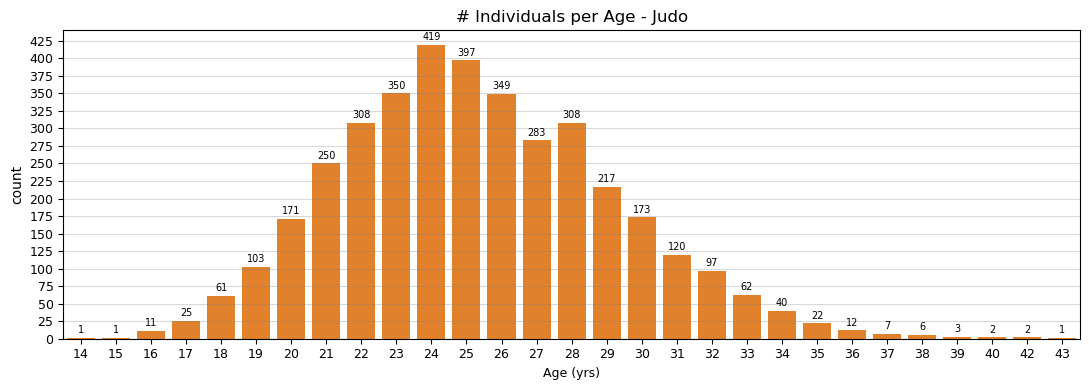

In [76]:
#Visualize distributions of columns of interest for judo data -- AGE

#get # observations of each 'age' value
    #display(judo_data['age'].value_counts(dropna=False).sort_index().reset_index())
#construct a plot of # observations per 'age' value
fig, ax = plt.subplots(figsize=(11,4))
sns.barplot(data=judo_data['age'].value_counts(dropna=False).sort_index().reset_index(), x='age', y='count', color=sns.color_palette()[1], ax=ax)
#label each age w/# observations
ax.bar_label(ax.containers[-1], labels=[f'{i}' for i in judo_data['age'].value_counts(dropna=False).sort_index().reset_index()['count']],
             fontsize=7, rotation=0, padding=2)
#edit plot details
plt.title('# Individuals per Age - Judo')
plt.xlabel('Age (yrs)', fontsize=9)
plt.xticks(fontsize=9, rotation=0)
plt.yticks(ticks=range(0,426,25), fontsize=9)
ax1.set(ylim=(0,430))
plt.grid(axis='y',alpha=0.3,color='gray')
plt.tight_layout();


This data is distributed quite evenly, making it simpler to define intervals of ages when necessary. For example, the two observations at ages 14 & 15 should be grouped into the 11 observations at age 16 because this age is the nearest & accounts for a large enough sample such that it can be used to form representative calculations & conclusions. Furthermore, each age between 17 & 36 years has enough observations on their own such that they don't need to be grouped with any other age. For ages 37 & greater, they each account for no more than seven observations, & so their data might be made more representative by grouping them together. 
Instead of 29 unique age values, this section will analyze 22 unique age ranges.

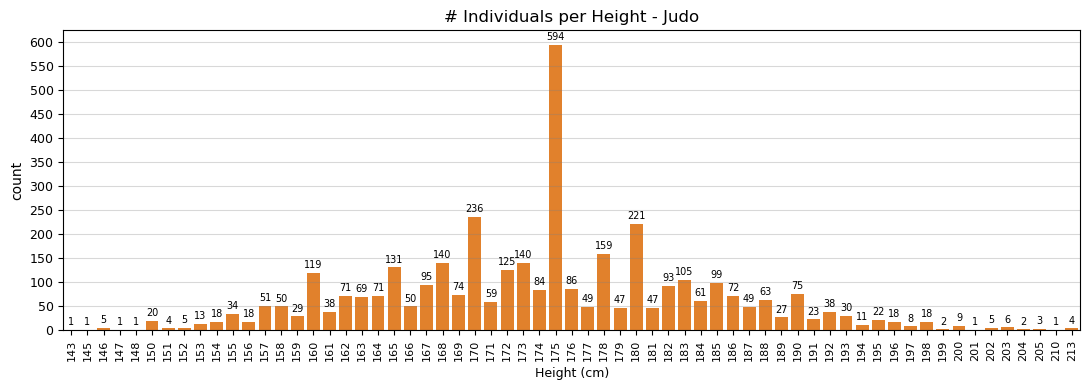

In [77]:
#HEIGHT

#get # observations of each 'height' value
    #display(judo_data['height'].value_counts(dropna=False).sort_index().reset_index())
#construct a plot of # observations per 'height' value
fig, ax = plt.subplots(figsize=(11,4))
sns.barplot(data=judo_data['height'].value_counts(dropna=False).sort_index().reset_index(), x='height', y='count', color=sns.color_palette()[1], ax=ax)
#label each height w/# observations
ax.bar_label(ax.containers[-1], labels=[f'{i}' for i in judo_data['height'].value_counts(dropna=False).sort_index().reset_index()['count']],
             fontsize=7, rotation=0, padding=2)
#edit plot details
plt.title('# Individuals per Height - Judo')
plt.xlabel('Height (cm)', fontsize=9)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(ticks=range(0,601,50), fontsize=9)
ax1.set(ylim=(0,605))
plt.grid(axis='y',alpha=0.3,color='gray')
plt.tight_layout();


Though these numbers oscillate more than they did in the previous plot, which visualized the distribution of ages of judo athletes, this data regarding the heights of judo athletes is still distributed fairly normally. For the smaller & larger ends of the height values, it is logical to group them into larger intervals because there are less observations, whereas the heights in the middle of the distribution have enough data points such that they can produce representative enough results on their own. As such, they don't need to be grouped into intervals of heights.

At this point, there is a compromise to consider when creating these intervals. For the data being grouped into ranges, is it more appropriate for these ranges to be evenly sized, or is the proximity of each value (height in this case) more important. For example, the heights from 143-148 centimeters could be grouped into an interval with nine observations, or they could also be grouped with the 20 observations of judo athletes with a height of 150 cm. Moreover, should this group include the heights of 151 cm (four observations) & 152 cm (five observations), or should the 151-cm data points go with the 150-cm data points & the 152-cm data go with the 153-cm data (11 observations?).

This point of consideration can be evaluated differently depending on the distribution of the data as well. Perhaps at the ends of the distribution, it is more important to emphasize consistency in terms of interval size, whereas for the more central parts of the distribution, proximity is more appropriate.

Ultimately, the ranges of these heights were defined as follows: 143-148, 150-151, 152-153, 154, ..., 197-198, 199-200, & 201+ cm. The individual heights between 154-196 (indicated by the ellipses) cm had enough data points on their own such that they didn't need to be grouped into an interval with another height. 
Instead of 63 unique height values, this section will analyze 49 unique height ranges.

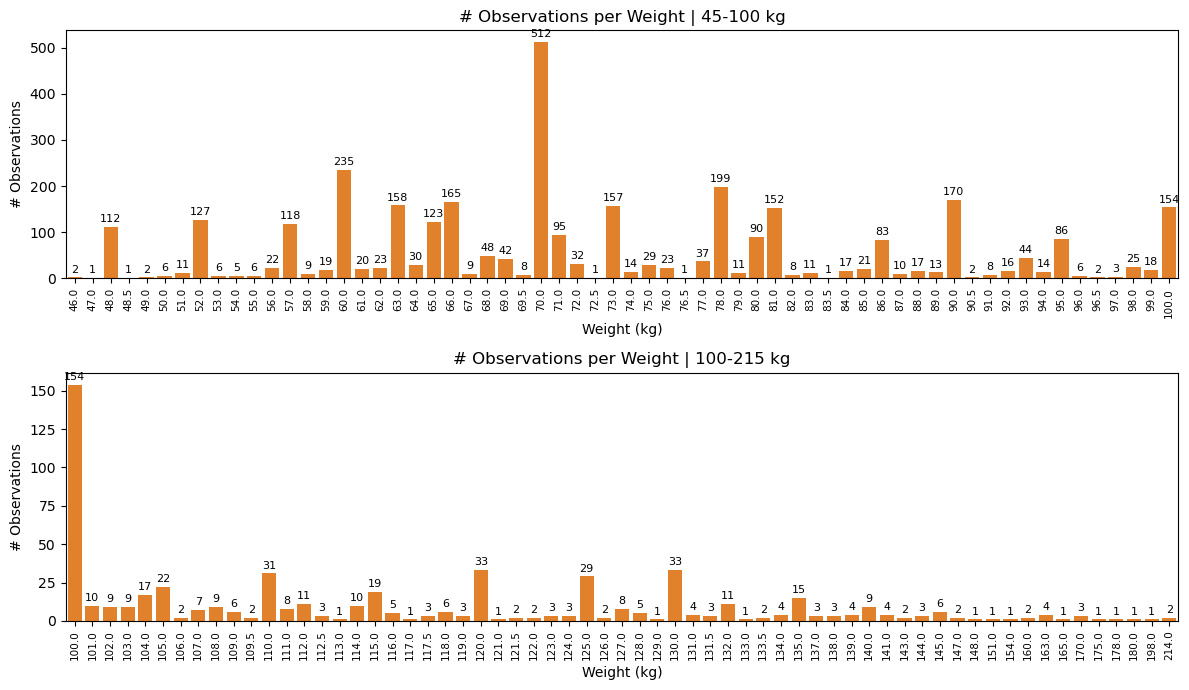

In [78]:
#WEIGHT

#make a figure -- better to split into two plots so that the data can be more legible
fig, axes = plt.subplots(nrows=2, figsize=(12,7))
ax1 = sns.barplot(data=judo_data[judo_data['weight'].between(45,100)]['weight'].value_counts(dropna=False).sort_index().reset_index(),
                  x='weight', y='count', color=sns.color_palette()[1], ax=axes[0])
ax2 = sns.barplot(data=judo_data[judo_data['weight'].between(100,215)]['weight'].value_counts(dropna=False).sort_index().reset_index(),
                  x='weight', y='count', color=sns.color_palette()[1], ax=axes[1])
#label each weight w/# observations
ax1.bar_label(ax1.containers[-1], fontsize=8, rotation=0, padding=2)
ax2.bar_label(ax2.containers[-1], fontsize=8, rotation=0, padding=2)
#edit plot details
for key, v in {'# Observations per Weight | 45-100 kg':[0], '# Observations per Weight | 100-215 kg':[1]}.items():
    plt.sca(axes[v[0]])
    plt.title(key)
    plt.xlabel('Weight (kg)')
    plt.xticks(fontsize=7.5, rotation=90)
    plt.ylabel('# Observations')
    plt.tight_layout();


The sophisticated manner in which the observations are spread across the range of weight values makes it difficult to define specific ranges for these data. As was the case when defining the height ranges, defining the weight ranges was a compromise between representativeness & proximity. Given that the weight data of judo athletes is distributed much less evenly than either height or age, these points of consideration were implemented differently. At the lower end of the weight distribution, the number of observations is already quite large for some values, whereas at the upper end, the number of observations is very minute. Also, at the lower end of this weight spectrum, the unique values are quite consistent in their separation & very few values are skipped (have no data). Conversely, at the upper end, after about 148 kilograms, more weight values are missing than not & they each account for very few data points.

Given this inconsistent distribution, the ranges of these weights were defined as follows: 46-49, 50-51, 52, 53-55, 56, 57, 58-59, 60, 67-68, 69, 69.5-70, ..., 72.5-73, ..., 76.5-77, ..., 82-83, 83.5-84, 90.5-91, 95-96.5, 97-98, 102-103, 105-106, 107-109, 109.5-110, 111-112.5, 113-114, 115-117, 117.5-119, 120-122, 123-126, 127-128, 129-131, 131.5-133, 133.5-135, 137-139, 140-141, 143-148, 151-165, 170-180, & 198+ kg. 
The individual weights between 70-72.5, 73-76.5, & 77-82 cm (indicated by the ellipses) had enough data points on their own such that they didn't need to be grouped into an interval with another height.

Instead of 124 unique weight values, this section will analyze 48 unique weight ranges.

When it comes to 'noc' (an athlete's national origin), it is certainly possible to attempt to group the labels into different groups which could depend on geographic location or the associated number of data points. However, since this parameter is non-numerical, it doesn't make as much logical sense to divvy up the values as was done for age, height, & weight. Recall that these probabilities are constructed so that a future athlete may enter their own age, height, weight, & national origin to evaluate their probability of winning Olympic medals based on historic data of previous Olympic athletes that relate to them across any of these four variables. When it comes to their 'noc' value, it is less useful for an athlete to consider the probabilities of other 'noc' values than it is to consider the probabilities of other age, height, & weight values that may be adjacent to their own physical attributes. Of course, such athletes may want to know these probabilities for 'noc' values that are in or are near the same geographical region/country that they are competing under, but this information is not necessarily as decisive as that based on age, height, & weight. These three physical parameters are more prevalent in Olympic competition (especially sports & events that are more physically demanding) than a non-physical, logistical parameter as is an athlete's national origin; however, this does not mean that 'noc' cannot still have somewhat of an influence on an Olympic athlete's success.

With intervals of age, height, & weight for judo athletes defined, the construction of their medal-winning probabilities can commence.

In [79]:
#Create columns indicating what age, height, & weight ranges each observation falls within

#AGE ranges: 14-16, 17, ..., & 37+
#loop through each observation of judo data
for i in judo_data.index:
    #14-16 age range:
    if judo_data.loc[i,'age'] < 17:
        judo_data.loc[i,'Age Range'] = '14-16'
    #37+ age range:
    elif judo_data.loc[i,'age'] > 36:
        judo_data.loc[i,'Age Range'] = '37+'
    #for all other ages that are not grouped in a range -- need to convert them from numerical data type to strings
    else:
        judo_data.loc[i,'Age Range'] = judo_data.loc[i,'age'].astype('str')


#HEIGHT ranges: 143-148, 150-151, 152-153, 154, ..., 197-198, 199-200, & 201+
#loop through each observation of judo data
for i in judo_data.index:
    #143-148 height range:
    if judo_data.loc[i,'height'] < 149:
        judo_data.loc[i,'Height Range'] = '143-148'
    #150-151 height range:
    elif judo_data.loc[i,'height'] > 149 and judo_data.loc[i,'height'] < 152:
        judo_data.loc[i,'Height Range'] = '150-151'
    #152-153 height range:
    elif judo_data.loc[i,'height'] > 151 and judo_data.loc[i,'height'] < 154:
        judo_data.loc[i,'Height Range'] = '152-153'
    #197-198 height range:
    elif judo_data.loc[i,'height'] > 196 and judo_data.loc[i,'height'] < 199:
        judo_data.loc[i,'Height Range'] = '197-198'
    #199-200 height range:
    elif judo_data.loc[i,'height'] > 198 and judo_data.loc[i,'height'] < 201:
        judo_data.loc[i,'Height Range'] = '199-200'
    #201+ height range:
    elif judo_data.loc[i,'height'] > 200:
        judo_data.loc[i,'Height Range'] = '201+'
    #for all other heights that are not grouped in a range -- also, need to convert them from numerical data type to strings
    else:
        judo_data.loc[i,'Height Range'] = judo_data.loc[i,'height'].astype('str')


In [80]:
#WEIGHT ranges: 46-49, 50-51, 52, 53-55, 56, 57, 58-59, 60, 67-68, 69, 69.5-70, ..., 72.5-73, ..., 76.5-77, ..., 82-83, 83.5-84, 
    #90.5-91, 95-96.5, 97-98, 102-103, 105-106, 107-109, 109.5-110, 111-112.5, 113-114, 115-117, 117.5-119, 120-122, 123-126, 
    #127-128, 129-131, 131.5-133, 133.5-135, 137-139, 140-141, 143-148, 151-165, 170-180, & 198+
#loop through each observation of judo data
for i in judo_data.index:
    #46-49 weight range:
    if judo_data.loc[i,'weight'] <= 49:
        judo_data.loc[i,'Weight Range'] = '46-49'
    #50-51 weight range:
    elif judo_data.loc[i,'weight'] >= 50 and judo_data.loc[i,'weight'] <= 51:
        judo_data.loc[i,'Weight Range'] = '50-51'
    #53-55 weight range:
    elif judo_data.loc[i,'weight'] >= 53 and judo_data.loc[i,'weight'] <= 55:
        judo_data.loc[i,'Weight Range'] = '53-55'
    #58-59 weight range:
    elif judo_data.loc[i,'weight'] >= 58 and judo_data.loc[i,'weight'] <= 59:
        judo_data.loc[i,'Weight Range'] = '58-59'
    #67-68 weight range:
    elif judo_data.loc[i,'weight'] >= 67 and judo_data.loc[i,'weight'] <= 68:
        judo_data.loc[i,'Weight Range'] = '67-68'
    #69.5-70 weight range:
    elif judo_data.loc[i,'weight'] > 69 and judo_data.loc[i,'weight'] <= 70:
        judo_data.loc[i,'Weight Range'] = '69.5-70'
    #72.5-73 weight range:
    elif judo_data.loc[i,'weight'] > 72 and judo_data.loc[i,'weight'] <= 73:
        judo_data.loc[i,'Weight Range'] = '72.5-73'
    #76.5-77 weight range:
    elif judo_data.loc[i,'weight'] > 76 and judo_data.loc[i,'weight'] <= 77:
        judo_data.loc[i,'Weight Range'] = '76.5-77'
    #82-83 weight range:
    elif judo_data.loc[i,'weight'] >= 82 and judo_data.loc[i,'weight'] <= 83:
        judo_data.loc[i,'Weight Range'] = '82-83'
    #83.5-84 weight range:
    elif judo_data.loc[i,'weight'] > 83 and judo_data.loc[i,'weight'] <= 84:
        judo_data.loc[i,'Weight Range'] = '83.5-84'
    #90.5-91 weight range:
    elif judo_data.loc[i,'weight'] > 90 and judo_data.loc[i,'weight'] <= 91:
        judo_data.loc[i,'Weight Range'] = '90.5-91'
    #95-96.5 weight range:
    elif judo_data.loc[i,'weight'] >= 95 and judo_data.loc[i,'weight'] < 97:
        judo_data.loc[i,'Weight Range'] = '95-96.5'
    #97-98 weight range:
    elif judo_data.loc[i,'weight'] >= 97 and judo_data.loc[i,'weight'] <= 98:
        judo_data.loc[i,'Weight Range'] = '97-98'
    #102-103 weight range:
    elif judo_data.loc[i,'weight'] >= 102 and judo_data.loc[i,'weight'] <= 103:
        judo_data.loc[i,'Weight Range'] = '102-103'
    #105-106 weight range:
    elif judo_data.loc[i,'weight'] >= 105 and judo_data.loc[i,'weight'] <= 106:
        judo_data.loc[i,'Weight Range'] = '105-106'
    #107-109 weight range:
    elif judo_data.loc[i,'weight'] >= 107 and judo_data.loc[i,'weight'] <= 109:
        judo_data.loc[i,'Weight Range'] = '107-109'
    #109.5-110 weight range:
    elif judo_data.loc[i,'weight'] > 109 and judo_data.loc[i,'weight'] <= 110:
        judo_data.loc[i,'Weight Range'] = '109.5-110'
    #111-112.5 weight range:
    elif judo_data.loc[i,'weight'] >= 111 and judo_data.loc[i,'weight'] < 113:
        judo_data.loc[i,'Weight Range'] = '111-112.5'
    #113-114 weight range:
    elif judo_data.loc[i,'weight'] >= 113 and judo_data.loc[i,'weight'] <= 114:
        judo_data.loc[i,'Weight Range'] = '113-114'
    #115-117 weight range:
    elif judo_data.loc[i,'weight'] >= 115 and judo_data.loc[i,'weight'] <= 117:
        judo_data.loc[i,'Weight Range'] = '115-117'
    #117.5-119 weight range:
    elif judo_data.loc[i,'weight'] > 117 and judo_data.loc[i,'weight'] <= 119:
        judo_data.loc[i,'Weight Range'] = '117.5-119'
    #120-122 weight range:
    elif judo_data.loc[i,'weight'] >= 120 and judo_data.loc[i,'weight'] <= 122:
        judo_data.loc[i,'Weight Range'] = '120-122'
    #123-126 weight range:
    elif judo_data.loc[i,'weight'] >= 123 and judo_data.loc[i,'weight'] <= 126:
        judo_data.loc[i,'Weight Range'] = '123-126'
    #127-128 weight range:
    elif judo_data.loc[i,'weight'] >= 127 and judo_data.loc[i,'weight'] <= 128:
        judo_data.loc[i,'Weight Range'] = '127-128'
    #129-131 weight range:
    elif judo_data.loc[i,'weight'] >= 129 and judo_data.loc[i,'weight'] <= 131:
        judo_data.loc[i,'Weight Range'] = '129-131'
    #131.5-133 weight range:
    elif judo_data.loc[i,'weight'] > 131 and judo_data.loc[i,'weight'] <= 133:
        judo_data.loc[i,'Weight Range'] = '131.5-133'
    #133.5-135 weight range:
    elif judo_data.loc[i,'weight'] > 133 and judo_data.loc[i,'weight'] <= 135:
        judo_data.loc[i,'Weight Range'] = '133.5-135'
    #137-139 weight range:
    elif judo_data.loc[i,'weight'] >= 137 and judo_data.loc[i,'weight'] <= 139:
        judo_data.loc[i,'Weight Range'] = '137-139'
    #140-141 weight range:
    elif judo_data.loc[i,'weight'] >= 140 and judo_data.loc[i,'weight'] <= 141:
        judo_data.loc[i,'Weight Range'] = '140-141'
    #143-148 weight range:
    elif judo_data.loc[i,'weight'] >= 143 and judo_data.loc[i,'weight'] <= 148:
        judo_data.loc[i,'Weight Range'] = '143-148'
    #151-165 weight range:
    elif judo_data.loc[i,'weight'] >= 151 and judo_data.loc[i,'weight'] <= 165:
        judo_data.loc[i,'Weight Range'] = '151-165'
    #170-180 weight range:
    elif judo_data.loc[i,'weight'] >= 170 and judo_data.loc[i,'weight'] <= 180:
        judo_data.loc[i,'Weight Range'] = '170-180'
    #198+ weight range:
    elif judo_data.loc[i,'weight'] >= 198:
        judo_data.loc[i,'Weight Range'] = '198+'
    #for all other weights that are not grouped in a range -- also, need to convert them from numerical data type to strings
    else:
        judo_data.loc[i,'Weight Range'] = judo_data.loc[i,'weight'].astype('str')



With the ranges of age, height, & weight defined, calculations regarding statistics & probabilities of winning medals can be constructed for each parameter.

In [81]:
#Calculate medal probabilities per AGE range & medal for judo

#for each medal (gold, silver, bronze)
judo_Arange_medal_I = judo_data.groupby(['Age Range','medal']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})
#for no medal or any medal
judo_Arange_medal_II = judo_data.groupby(['Age Range','medal?']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})

#rearrange the data
judo_Arange_medal_I = judo_Arange_medal_I.pivot(index='Age Range', columns='medal', values='#')
judo_Arange_medal_II = judo_Arange_medal_II.pivot(index='Age Range', columns='medal?', values='#')

#need to fill some null values
judo_Arange_medal_II = judo_Arange_medal_II.fillna(0)

#sum # observations & calculate probability of each medal per age range
for i in judo_Arange_medal_I.index:
    judo_Arange_medal_I.loc[i,'# Observations'] = judo_Arange_medal_I.loc[i,:].sum(axis=0)
    judo_Arange_medal_I.loc[i,'Gold Prob. (%)'] = np.round((judo_Arange_medal_I.loc[i,'Gold'] / judo_Arange_medal_I.loc[i,'# Observations'])*100,2)
    judo_Arange_medal_I.loc[i,'Silver Prob. (%)'] = np.round((judo_Arange_medal_I.loc[i,'Silver'] / judo_Arange_medal_I.loc[i,'# Observations'])*100,2)
    judo_Arange_medal_I.loc[i,'Bronze Prob. (%)'] = np.round((judo_Arange_medal_I.loc[i,'Bronze'] / judo_Arange_medal_I.loc[i,'# Observations'])*100,2)
#sum # observations & calculate probability of winning a medal per age range
for i in judo_Arange_medal_II.index:
    judo_Arange_medal_II.loc[i,'# Observations'] = judo_Arange_medal_II.loc[i,:].sum(axis=0)
    judo_Arange_medal_II.loc[i,'Medal Prob. (%)'] = np.round((judo_Arange_medal_II.loc[i,'Yes'] / judo_Arange_medal_II.loc[i,'# Observations'])*100,2)

#change data type of some columns
judo_Arange_medal_I['# Observations'] = judo_Arange_medal_I['# Observations'].astype('int')
judo_Arange_medal_II[['No','Yes']] = judo_Arange_medal_II[['No','Yes']].astype('int')
judo_Arange_medal_II['# Observations'] = judo_Arange_medal_II['# Observations'].astype('int')

judo_Arange_medal_I = judo_Arange_medal_I.reset_index()
judo_Arange_medal_II = judo_Arange_medal_II.reset_index()

#merge the two dataframes
judo_Arange_medal = judo_Arange_medal_I.merge(judo_Arange_medal_II[['Age Range','No','Yes','Medal Prob. (%)']] , on='Age Range')

#reorganize columns
judo_Arange_medal = judo_Arange_medal[['Age Range','Gold','Silver','Bronze','Yes','None','# Observations','Gold Prob. (%)', 'Silver Prob. (%)',
                                'Bronze Prob. (%)', 'Medal Prob. (%)']].rename(columns={'Yes':'Medals Won','None':'Medals Not Won'})
#save for external use
#judo_Arange_medal.to_csv('judo_Arange_medal.csv')


In [82]:
#Calculate medal probabilities per HEIGHT range & medal for judo

#for each medal
judo_Hrange_medal_I = judo_data.groupby(['Height Range','medal']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})
#for no medal or any medal
judo_Hrange_medal_II = judo_data.groupby(['Height Range','medal?']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})

#rearrange the data
judo_Hrange_medal_I = judo_Hrange_medal_I.pivot(index='Height Range', columns='medal', values='#')
judo_Hrange_medal_II = judo_Hrange_medal_II.pivot(index='Height Range', columns='medal?', values='#')

#need to fill some null values
judo_Hrange_medal_II = judo_Hrange_medal_II.fillna(0)

#sum # observations & calculate probability of each medal per height range
for i in judo_Hrange_medal_I.index:
    judo_Hrange_medal_I.loc[i,'# Observations'] = judo_Hrange_medal_I.loc[i,:].sum(axis=0)
    judo_Hrange_medal_I.loc[i,'Gold Prob. (%)'] = np.round((judo_Hrange_medal_I.loc[i,'Gold'] / judo_Hrange_medal_I.loc[i,'# Observations'])*100,2)
    judo_Hrange_medal_I.loc[i,'Silver Prob. (%)'] = np.round((judo_Hrange_medal_I.loc[i,'Silver'] / judo_Hrange_medal_I.loc[i,'# Observations'])*100,2)
    judo_Hrange_medal_I.loc[i,'Bronze Prob. (%)'] = np.round((judo_Hrange_medal_I.loc[i,'Bronze'] / judo_Hrange_medal_I.loc[i,'# Observations'])*100,2)
#sum # observations & calculate probability of winning a medal per height range
for i in judo_Hrange_medal_II.index:
    judo_Hrange_medal_II.loc[i,'# Observations'] = judo_Hrange_medal_II.loc[i,:].sum(axis=0)
    judo_Hrange_medal_II.loc[i,'Medal Prob. (%)'] = np.round((judo_Hrange_medal_II.loc[i,'Yes'] / judo_Hrange_medal_II.loc[i,'# Observations'])*100,2)

#change data type of some columns
judo_Hrange_medal_I['# Observations'] = judo_Hrange_medal_I['# Observations'].astype('int')
judo_Hrange_medal_II[['No','Yes']] = judo_Hrange_medal_II[['No','Yes']].astype('int')
judo_Hrange_medal_II['# Observations'] = judo_Hrange_medal_II['# Observations'].astype('int')

judo_Hrange_medal_I = judo_Hrange_medal_I.reset_index()
judo_Hrange_medal_II = judo_Hrange_medal_II.reset_index()

#merge the two dataframes
judo_Hrange_medal = judo_Hrange_medal_I.merge(judo_Hrange_medal_II[['Height Range','No','Yes','Medal Prob. (%)']] , on='Height Range')

#reorganize columns
judo_Hrange_medal = judo_Hrange_medal[['Height Range','Gold','Silver','Bronze','Yes','None','# Observations','Gold Prob. (%)', 'Silver Prob. (%)',
                                'Bronze Prob. (%)', 'Medal Prob. (%)']].rename(columns={'Yes':'Medals Won','None':'Medals Not Won'})
#save for external use
#judo_Hrange_medal.to_csv('judo_Hrange_medal.csv')


In [83]:
#Calculate medal probabilities per WEIGHT range & medal for judo

#for each medal
judo_Wrange_medal_I = judo_data.groupby(['Weight Range','medal']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})
#for no medal or any medal
judo_Wrange_medal_II = judo_data.groupby(['Weight Range','medal?']).count().iloc[:,:1].reset_index().rename(columns={'id':'#'})

#rearrange the data
judo_Wrange_medal_I = judo_Wrange_medal_I.pivot(index='Weight Range', columns='medal', values='#')
judo_Wrange_medal_II = judo_Wrange_medal_II.pivot(index='Weight Range', columns='medal?', values='#')

#need to fill some null values
judo_Wrange_medal_II = judo_Wrange_medal_II.fillna(0)

#sum # observations & calculate probability of each medal per weight range
for i in judo_Wrange_medal_I.index:
    judo_Wrange_medal_I.loc[i,'# Observations'] = judo_Wrange_medal_I.loc[i,:].sum(axis=0)
    judo_Wrange_medal_I.loc[i,'Gold Prob. (%)'] = np.round((judo_Wrange_medal_I.loc[i,'Gold'] / judo_Wrange_medal_I.loc[i,'# Observations'])*100,2)
    judo_Wrange_medal_I.loc[i,'Silver Prob. (%)'] = np.round((judo_Wrange_medal_I.loc[i,'Silver'] / judo_Wrange_medal_I.loc[i,'# Observations'])*100,2)
    judo_Wrange_medal_I.loc[i,'Bronze Prob. (%)'] = np.round((judo_Wrange_medal_I.loc[i,'Bronze'] / judo_Wrange_medal_I.loc[i,'# Observations'])*100,2)
#sum # observations & calculate probability of winning a medal per weight range
for i in judo_Wrange_medal_II.index:
    judo_Wrange_medal_II.loc[i,'# Observations'] = judo_Wrange_medal_II.loc[i,:].sum(axis=0)
    judo_Wrange_medal_II.loc[i,'Medal Prob. (%)'] = np.round((judo_Wrange_medal_II.loc[i,'Yes'] / judo_Wrange_medal_II.loc[i,'# Observations'])*100,2)

#change data type of some columns
judo_Wrange_medal_I['# Observations'] = judo_Wrange_medal_I['# Observations'].astype('int')
judo_Wrange_medal_II[['No','Yes']] = judo_Wrange_medal_II[['No','Yes']].astype('int')
judo_Wrange_medal_II['# Observations'] = judo_Wrange_medal_II['# Observations'].astype('int')

judo_Wrange_medal_I = judo_Wrange_medal_I.reset_index()
judo_Wrange_medal_II = judo_Wrange_medal_II.reset_index()

#merge the two dataframes
judo_Wrange_medal = judo_Wrange_medal_I.merge(judo_Wrange_medal_II[['Weight Range','No','Yes','Medal Prob. (%)']] , on='Weight Range')

#reorganize columns
judo_Wrange_medal = judo_Wrange_medal[['Weight Range','Gold','Silver','Bronze','Yes','None','# Observations','Gold Prob. (%)', 'Silver Prob. (%)',
                                'Bronze Prob. (%)', 'Medal Prob. (%)']].rename(columns={'Yes':'Medals Won','None':'Medals Not Won'})
#save for external use
#judo_Wrange_medal.to_csv('judo_Wrange_medal.csv')


With all of the necessary data constructed & organized, a few functions need to be made before creating the ultimate function which calculates the medal-winning probabilities given an athlete's age, height, weight, &/or noc. The final function should be as simple as possible for the user when it comes to entering their age, height, weight &/or noc values of interest. It would be unnecessarily cumbersome for them to have to find the appropriate age, height, &/or weight range as defined previously. As such, a couple of other functions can be created to help accomplish this.

Given that the age/height/weight ranges were not all consistently defined, it can be tricky to determine the corresponding range for a specific age/height/weight value. For example, given a unique age (as an integer), the code needs to be able to determine what age range the value falls within. Since the ranges were not all consistently defined, this process of identifying the corresponding age range must consider all the possible scenarios in which the ranges are defined in order to check whether the age may associate with such ranges or not.

To start, a function (or multiple) should be made to determine the lower & upper limits of each age/height/weight range. If these specific numbers can be compared to a unique age/height/weight value, it is easier to determine what age/height/weight range the value of interest falls within.

Ultimately, the final function (which will perform the same processes as the "judo_athlete_probabilities" function does but for age/height/weight ranges instead of unique age/height/weight values) should be able to utilize functions that accomplish these tasks of determining the corresponding age/height/weight range for a specified age, height, &/or weight.

In [84]:
#for the medal-winning-probabilities function, need to determine what range the specified age, height, &/or weight fall into.
    #the range columns are currently objects, so would have to change them to numerical data types.
    #have to use regex (regular expressions) to extract the lower/upper limits of each range.
    #have to consider 'ranges' that are a unique/distinct value.

#Make a function to extract the lower value of each age/height/weight range.
def extract_lower_value(string):
    '''
    The function extracts the lower value of each age/height/weight range which were originally defined as objects. As such, 
    regex can be utilized.
    When extracting the lower limit of the range, there are multiple scenarios to consider. Either the range actually is a range
    & follows the format {number}.{number}-..., the format {number}+, or it is a unique value & has is formatted as {number}.{number}. 
    Additionally, the number after the decimal is sometimes non-zero & can't be disregarded. Fortunately, of the data & strings 
    that are to be analyzed using this function, there are no ranges of the format {number}.{non-zero number}. Otherwise, 
    another scenario would have to be accounted for.
    
    Arguments:
        string (object): the age/height/weight range that is being analyzed.
    
    Returns:
        The lower limit of the specified string.
    '''
    #check if the string contains a "-"
    if "-" in string:
        #extract everything before the "-"
        match = re.match("([^-\s]+)", string)
        #return the desired sequence
        return match.group(1)
        return None
    #check if the string contains a "+"
    elif "+" in string:
        #extract everything before the "+"
        match = string.split("+")[0]
        #return the desired sequence
        return match
    else:
        #extract everything before the first "."
        match = re.match("([^.\s]+)", string)
        #return the desired sequence
        return match.group(1)
        return None


#Make a function to extract the upper value of each age/height/weight range.
def extract_upper_value(string):
    '''
    The function extracts the upper value of each age/height/weight range which were originally defined as objects. As such, 
    regex can be utilized.
    When extracting the upper limit of the range, there are multiple scenarios to consider but they are less complicated than 
    was the case for the lower limit. Either the upper value follows a "-", preceeds a "+", or it doesn't, in which case the 
    range is a unique value & regex is not necessary.
    
    Arguments:
        string (object): the age/height/weight range that is being analyzed.
    
    Returns:
        The upper limit of the specified string.
    '''
    #check if the string contains a "-"
    if "-" in string:
        #extract everything after the "-"
        match = string.split("-")[1]
        #return the desired sequence
        return match
    #check if the string contains a "+"
    elif "+" in string:
        #extract everything before the "+"
        match = string.split("+")[0]
        #return the desired sequence
        return match
    else:
        #regex is not required, return the entire string
        return string


In [85]:
#verify the function -- GOOD
display(judo_Wrange_medal.sample(1, random_state=10))
display(extract_lower_value(judo_Wrange_medal.sample(1, random_state=10)['Weight Range'].values[0]))
display(extract_upper_value(judo_Wrange_medal.sample(1, random_state=10)['Weight Range'].values[0]))


,Weight Range,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
21,170-180,0,0,1,1,5,6,0.0,0.0,16.67,16.67


'170'

'180'

In [86]:
#Want to make a function to calculate medal-winning probabilities given an age, height, weight, &/or noc using the corresponding...
    #range/interval data for age, height, & weight that were recently constructed. Before any probabilities are calculated, ...
    #the corresponding ranges of the (optionally) specified age, height, & weight have to be determined. This is best done by... 
    #creating another function.

def find_AHW_ranges(age=None, height=None, weight=None):
    '''
    This function analyzes the specified values for age, height, &/or weight to determine the corresponding age, height, &/or 
    weight ranges defined previously in the "judo_Arange_medal," "judo_Hrange_medal," & "judo_Wrange_medal" dataframes. The 
    "extract_lower_value" & "extract_upper_value" functions were previously constructed to aid in this process. This function 
    returns the resulting age, height, & weight ranges that correspond with the age, height, &/or weight values specified.
    
    Arguments:
        age (int): The age of an athlete in years.
        height (int): The height of an athlete in centimeters.
        weight (float): The weight of an athlete in kilograms.
    
    Returns:
        Arange (object): The value of 'Age Range' in the "judo_Arange_medal" dataframe that corresponds with the specified value
            of the age argument.
        Hrange (object): The value of 'Height Range' in the "judo_Hrange_medal" dataframe that corresponds with the specified
            value of the height argument.
        Wrange (object): The value of 'Weight Range' in the "judo_Wrange_medal" dataframe that corresponds with the specified
            value of the weight argument.
    '''
    #Firstly, the return values need to be initiated & defined in a broad enough scope so that they can be returned at the... 
        #end of the function.
    Arange = None
    Hrange = None
    Wrange = None
    
    #Consider the cases in which the inputted age/height/weight values are beyond the corresponding age/height/weight ranges... 
        #in the judo data. Provide a response saying that the inputted value is beyond the corresponding range.
    #AGE:
    if age < judo_age_medal['age'].min() or age > judo_age_medal['age'].max():
        print("The provided age is smaller or larger than the ages of the data avaliable. The ages with avaliable data are between: {}-{} years.".format(
            judo_age_medal['age'].min(), judo_age_medal['age'].max()))
    #HEIGHT:
    if height < judo_height_medal['height'].min() or height > judo_height_medal['height'].max():
        print("The provided height is smaller or larger than the heights of the data avaliable. The heights with avaliable data are between: {}-{} cm.".format(
            judo_height_medal['height'].min(), judo_height_medal['height'].max()))
    #WEIGHT:
    if weight < judo_weight_medal['weight'].min() or weight > judo_weight_medal['weight'].max():
        print("The provided weight is smaller or larger than the weights of the data avaliable. The weights with avaliable data are between: {}-{} kg.".format(
            judo_weight_medal['weight'].min(), judo_weight_medal['weight'].max()))
    
    #if age is specified
    if age != None:
        #loop through each row in the judo age-range-medal statistics
        for i, row in judo_Arange_medal.iterrows():
            #identify the corresponding 'Age Range' in which the specified age falls within
            if float(extract_lower_value(row['Age Range'])) <= age <= float(extract_upper_value(row['Age Range'])):
                Arange = row['Age Range']
                #terminate & exit the loop
                break
    #if height is specified    
    if height != None:
        #loop through each row in the judo height-range-medal statistics
        for i, row in judo_Hrange_medal.iterrows():
            #identify the corresponding 'Height Range' in which the specified height falls within
            if float(extract_lower_value(row['Height Range'])) <= height <= float(extract_upper_value(row['Height Range'])):
                Hrange = row['Height Range']
                #terminate & exit the loop
                break
    #if weight is specified        
    if weight != None:
        #loop through each row in the judo weight-range-medal statistics
        for i, row in judo_Wrange_medal.iterrows():
            #identify the corresponding 'Weight Range' in which the specified weight falls within
            if float(extract_lower_value(row['Weight Range'])) <= weight <= float(extract_upper_value(row['Weight Range'])):
                Wrange = row['Weight Range']
                #terminate & exit the loop
                break
    #return the corresponding age, height, &/or weight ranges
    return Arange, Hrange, Wrange

#to retrieve the specific age/height/weight ranges, they have to be indexed; e.g. find_AHW_ranges(age, height, weight)[0], 
    #or ...[1] / ...[2]

In [87]:
#verify the function -- GOOD
display(find_AHW_ranges(15, 198, 155))
display(find_AHW_ranges(13, 140, 215))


('14-16', '197-198', '151-165')

The provided age is smaller or larger than the ages of the data avaliable. The ages with avaliable data are between: 14-43 years.
The provided height is smaller or larger than the heights of the data avaliable. The heights with avaliable data are between: 143-213 cm.
The provided weight is smaller or larger than the weights of the data avaliable. The weights with avaliable data are between: 46.0-214.0 kg.


(None, None, None)

In [88]:
#Make a function to calculate medal-winning probabilities given age, height, weight, &/or noc

def judo_athlete_ranges_probabilities(age=None, height=None, weight=None, noc=None):
    '''
    Similarly to the judo_athlete_probailities function, this function performs the same general tasks. The major difference is 
    that the data used to perform the calculations is constructed differently, specifically in regards to the age, height, &
    weight of the judo athletes. Instead of having unique values for each of these three parameters, some of the data was 
    grouped into ranges of age, height, & weight. Some ages, heights, & weights had very few data points from which to build 
    representative probability data. By grouping some of these data points together, the resulting data provides some 
    additional representation & context for athletes using this data to analyze probabilities.
    
    The function "find_AHW_ranges" was constructed in order to convert a specified age/height/weight into the corresponding 
    age/height/weight range as defined previously. "find_AHW_ranges" can be used to supply the age, height, &/or weight values 
    which will be used to calculate the medal-winning probabilities in this function. Note that to obtain these three values, 
    they need to be indexed; e.g. find_AHW_ranges(age, height, weight)[0] returns the age range that is necessary to perform 
    the calculations involved in this function. For the noc argument, it doesn't have any relation to the "find_AHW_ranges" 
    function & can be specified seperately without any indexing.
    
    "judo_athlete_ranges_probabilities" takes in certain values regarding an athlete's age, height, weight, & national origin 
    to filter the overall dataset to find various Olympic-related statistics of all judo athletes that relate to the listed 
    parameters & their specified values. This filtered data is used to accumulate & calculate probabilities of such athletes 
    winning Olympic medals.
    
    Arguments:
        age (object): The age range of an athlete in years as determined by the "find_AHW_ranges" function.
        height (object): The height range of an athlete in centimeters as determined by the "find_AHW_ranges" function.
        weight (object): The weight range of an athlete in kilograms as determined by the "find_AHW_ranges" function.
        noc (object or str): The nationality in which the athlete originates from in the form of the corresponding three-letter
            ISO 3166-1 alpha-3 country code.
            
    Returns:
        1) The statistics & medal-winning probabilities of the athletes that correspond to each of the specified parameters. For
            example, if age & height are specified, two rows corresponding to these statistics & probabilities of judo athletes
            with either such an age or height should be returned, one row for each parameter.
        2) The total statistics & medal-winning probabilities of a potential athlete (as specified by the parameters) as a
            result of combining the statistics & probabilities of each of the rows (data points) from point 1.
    '''

    #Filter for data of athletes who relate to each of the specified parameters.
    if age != None:
        judo_ex_Arange = judo_Arange_medal[judo_Arange_medal['Age Range'] == age].melt(id_vars=['Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations','Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], value_vars='Age Range', var_name='parameter')
    if height != None:
        judo_ex_Hrange = judo_Hrange_medal[judo_Hrange_medal['Height Range'] == height].melt(id_vars=['Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations', 'Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], value_vars='Height Range', var_name='parameter')
    if weight != None:
        judo_ex_Wrange = judo_Wrange_medal[judo_Wrange_medal['Weight Range'] == weight].melt(id_vars=['Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations','Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], value_vars='Weight Range', var_name='parameter')
    if noc != None:
        judo_ex_noc = judo_noc_medal[judo_noc_medal['noc'] == noc].melt(id_vars=['Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations','Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], value_vars='noc', var_name='parameter')
    
    #Combine the filtered & renamed data for each of the specified parameters -- NEED TO APPLY conditions for missing ... 
        #parameters & such here. If only one parameter is specified, simply reference the dataframe of the corresponding ...
        #parameter (e.g. "judo_Arange_medal") because there is no need to calculate the product of multiple probabilities if ...
        #there is only one.
    #if all parameters are specified:
    if age != None and height != None and weight != None and noc != None:
        judo_data_ex_merged = pd.concat([judo_ex_Arange, judo_ex_Hrange, judo_ex_Wrange, judo_ex_noc]).reset_index(drop=True)
    #if age, height, weight (ranges) are specified:
    elif age != None and height != None and weight != None and noc == None:
        judo_data_ex_merged = pd.concat([judo_ex_Arange, judo_ex_Hrange, judo_ex_Wrange]).reset_index(drop=True)
    #if age, height (ranges), noc are specified:
    elif age != None and height != None and weight == None and noc != None:
        judo_data_ex_merged = pd.concat([judo_ex_Arange, judo_ex_Hrange, judo_ex_noc]).reset_index(drop=True)
    #if age, weight (ranges), noc are spcified:
    elif age != None and height == None and weight != None and noc != None:
        judo_data_ex_merged = pd.concat([judo_ex_Arange, judo_ex_Wrange, judo_ex_noc]).reset_index(drop=True)
    #if height, weight (ranges), noc are specified:
    elif age == None and height != None and weight != None and noc != None:
        judo_data_ex_merged = pd.concat([judo_ex_Hrange, judo_ex_Wrange, judo_ex_noc]).reset_index(drop=True)
    #if age & height (ranges) are specified:
    elif age != None and height != None and weight == None and noc == None:
        judo_data_ex_merged = pd.concat([judo_ex_Arange, judo_ex_Hrange]).reset_index(drop=True)
    #if age & weight (ranges) are specified:
    elif age != None and height == None and weight != None and noc == None:
        judo_data_ex_merged = pd.concat([judo_ex_Arange, judo_ex_Wrange]).reset_index(drop=True)
    #if age (range) & noc are specified:
    elif age != None and height == None and weight == None and noc != None:
        judo_data_ex_merged = pd.concat([judo_ex_Arange, judo_ex_noc]).reset_index(drop=True)
    #if height & weight (ranges) are specified:
    elif age == None and height != None and weight != None and noc == None:
        judo_data_ex_merged = pd.concat([judo_ex_Hrange, judo_ex_Wrange]).reset_index(drop=True)
    #if height (range) & noc are specified:
    elif age == None and height != None and weight == None and noc != None:
        judo_data_ex_merged = pd.concat([judo_ex_Hrange, judo_ex_noc]).reset_index(drop=True)
    #if weight (range) & noc are specified:
    elif age == None and height == None and weight != None and noc != None:
        judo_data_ex_merged = pd.concat([judo_ex_Wrange, judo_ex_noc]).reset_index(drop=True)
    
    
    #Make a dataset containing total values (through sums) & probabilities (through products). First, calculate sum for medals & observations.
    judo_data_ex_T1 = judo_data_ex_merged[['Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations']].sum(axis=0).reset_index()
    #Then, calculate product for probabilities -- need to first convert percentages to non-percentages.
    for i in judo_data_ex_merged.index:
        judo_data_ex_merged.loc[i,'Gold Prob.'] = judo_data_ex_merged.loc[i,'Gold Prob. (%)']/100
        judo_data_ex_merged.loc[i,'Silver Prob.'] = judo_data_ex_merged.loc[i,'Silver Prob. (%)']/100
        judo_data_ex_merged.loc[i,'Bronze Prob.'] = judo_data_ex_merged.loc[i,'Bronze Prob. (%)']/100
        judo_data_ex_merged.loc[i,'Medal Prob.'] = judo_data_ex_merged.loc[i,'Medal Prob. (%)']/100

    judo_data_ex_T2 = judo_data_ex_merged[['Gold Prob.','Silver Prob.','Bronze Prob.','Medal Prob.']].product().reset_index()
    
    
    #Merge the total sums & products together, & convert probabilities back to percentages.
    judo_data_ex_total = pd.concat([judo_data_ex_T1, judo_data_ex_T2]).rename(columns={'index':'col',0:'value'}).set_index('col').T
    judo_data_ex_total[['Gold Prob.','Silver Prob.','Bronze Prob.','Medal Prob.']] = judo_data_ex_total[['Gold Prob.','Silver Prob.','Bronze Prob.','Medal Prob.']]*100
    
    #Rename columns
    judo_data_ex = judo_data_ex_total.rename(columns={'Gold':'Total Golds','Silver':'Total Silvers','Bronze':'Total Bronzes','Medals Won':'Total Medals Won','Medals Not Won':'Total Medals Not Won','# Observations':'Total # Observations','Gold Prob.':'Gold Prob. (%)','Silver Prob.':'Silver Prob. (%)','Bronze Prob.':'Bronze Prob. (%)','Medal Prob.':'Medal Prob. (%)'}).reset_index(drop=True)
    
    #Clean up some columns. First, convert the first six columns from floats to integers.
    judo_data_ex[[*judo_data_ex.iloc[:,:6].columns]] = judo_data_ex[[*judo_data_ex.iloc[:,:6].columns]].astype('int')
    #Then round the last four columns to fewer digits.
    judo_data_ex[[*judo_data_ex.iloc[:,6:].columns]] = np.round(judo_data_ex[[*judo_data_ex.iloc[:,6:].columns]],4)

    #return the probabilities for each of the specified parameters & the merged probabilities
    return judo_data_ex_merged, judo_data_ex

#to retrieve results, must index them; e.g. judo_athlete_probabilities(...)[0] or judo_athlete_probabilities(...)[1]


In [89]:
#verify the function & compare to the "judo_athlete_probabilities" function -- GOOD
    #display(find_AHW_ranges(15, 198, 155))

display(judo_athlete_probabilities(15, 198, 155)[0], judo_athlete_probabilities(15, 198, 155)[1])

#make a separator
display('#####################################################################################################################')

display(judo_athlete_ranges_probabilities(find_AHW_ranges(15, 198, 155)[0], find_AHW_ranges(15, 198, 155)[1], 
                                          find_AHW_ranges(15, 198, 155)[2])[0], 
        judo_athlete_ranges_probabilities(find_AHW_ranges(15, 198, 155)[0], find_AHW_ranges(15, 198, 155)[1], 
                                          find_AHW_ranges(15, 198, 155)[2])[1])


,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%),parameter,value,Gold Prob.,Silver Prob.,Bronze Prob.,Medal Prob.
0,0,0,0,0,1,1,0.0,0.00,0.0,0.00,age,15.0,0.0,0.0000,0.0,0.0000
1,0,2,0,2,16,18,0.0,11.11,0.0,11.11,height,198.0,0.0,0.1111,0.0,0.1111


col,Total Golds,Total Silvers,Total Bronzes,Total Medals Won,Total Medals Not Won,Total # Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
0,0,2,0,2,17,19,0.0,0.0,0.0,0.0


'#####################################################################################################################'

,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%),parameter,value,Gold Prob.,Silver Prob.,Bronze Prob.,Medal Prob.
0,1,1,0,2,11,13,7.69,7.69,0.00,15.38,Age Range,14-16,0.0769,0.0769,0.0000,0.1538
1,1,2,2,5,21,26,3.85,7.69,7.69,19.23,Height Range,197-198,0.0385,0.0769,0.0769,0.1923
2,0,0,2,2,7,9,0.00,0.00,22.22,22.22,Weight Range,151-165,0.0000,0.0000,0.2222,0.2222


col,Total Golds,Total Silvers,Total Bronzes,Total Medals Won,Total Medals Not Won,Total # Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
0,2,3,4,9,39,48,0.0,0.0,0.0,0.6572


In [90]:
#produce another example using most popular age (24), height (175), & weight (70) & incorporate a noc value to compare
    #also compare to the "judo_athlete_probabilities" function

#WITHOUT noc specified:
display(judo_athlete_probabilities(24, 175, 70)[0], judo_athlete_probabilities(24, 175, 70)[1])
#make a separator
display('#####################################################################################################################')

display(judo_athlete_ranges_probabilities(find_AHW_ranges(24, 175, 70)[0], find_AHW_ranges(24, 175, 70)[1], 
                                          find_AHW_ranges(24, 175, 70)[2])[0], 
        judo_athlete_ranges_probabilities(find_AHW_ranges(24, 175, 70)[0], find_AHW_ranges(24, 175, 70)[1], 
                                          find_AHW_ranges(24, 175, 70)[2])[1])
#make a separator
display('#####################################################################################################################')
display('#####################################################################################################################')
display('#####################################################################################################################')

#WITH noc specified:
display(judo_athlete_probabilities(24, 175, 70, 'IRQ')[0], judo_athlete_probabilities(24, 175, 70, 'IRQ')[1])
#make a separator
display('#####################################################################################################################')

display(judo_athlete_ranges_probabilities(find_AHW_ranges(24, 175, 70)[0], find_AHW_ranges(24, 175, 70)[1], 
                                          find_AHW_ranges(24, 175, 70)[2], 'IRQ')[0], 
        judo_athlete_ranges_probabilities(find_AHW_ranges(24, 175, 70)[0], find_AHW_ranges(24, 175, 70)[1], 
                                          find_AHW_ranges(24, 175, 70)[2], 'IRQ')[1])


,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%),parameter,value,Gold Prob.,Silver Prob.,Bronze Prob.,Medal Prob.
0,17,13,26,56,363,419,4.06,3.10,6.21,13.37,age,24.0,0.0406,0.0310,0.0621,0.1337
1,12,9,20,41,553,594,2.02,1.52,3.37,6.90,height,175.0,0.0202,0.0152,0.0337,0.0690
2,13,14,23,50,462,512,2.54,2.73,4.49,9.77,weight,70.0,0.0254,0.0273,0.0449,0.0977


col,Total Golds,Total Silvers,Total Bronzes,Total Medals Won,Total Medals Not Won,Total # Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
0,42,36,69,147,1378,1525,0.0021,0.0013,0.0094,0.0901


'#####################################################################################################################'

,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%),parameter,value,Gold Prob.,Silver Prob.,Bronze Prob.,Medal Prob.
0,17,13,26,56,363,419,4.06,3.10,6.21,13.37,Age Range,24,0.0406,0.0310,0.0621,0.1337
1,12,9,20,41,553,594,2.02,1.52,3.37,6.90,Height Range,175,0.0202,0.0152,0.0337,0.0690
2,13,14,23,50,470,520,2.50,2.69,4.42,9.62,Weight Range,69.5-70,0.0250,0.0269,0.0442,0.0962


col,Total Golds,Total Silvers,Total Bronzes,Total Medals Won,Total Medals Not Won,Total # Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
0,42,36,69,147,1386,1533,0.0021,0.0013,0.0093,0.0887


...

,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%),parameter,value,Gold Prob.,Silver Prob.,Bronze Prob.,Medal Prob.
0,17,13,26,56,363,419,4.06,3.10,6.21,13.37,age,24,0.0406,0.0310,0.0621,0.1337
1,12,9,20,41,553,594,2.02,1.52,3.37,6.90,height,175,0.0202,0.0152,0.0337,0.0690
2,13,14,23,50,462,512,2.54,2.73,4.49,9.77,weight,70.0,0.0254,0.0273,0.0449,0.0977
3,0,0,0,0,2,2,0.00,0.00,0.00,0.00,noc,IRQ,0.0000,0.0000,0.0000,0.0000


col,Total Golds,Total Silvers,Total Bronzes,Total Medals Won,Total Medals Not Won,Total # Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
0,42,36,69,147,1380,1527,0.0,0.0,0.0,0.0


'#####################################################################################################################'

,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%),parameter,value,Gold Prob.,Silver Prob.,Bronze Prob.,Medal Prob.
0,17,13,26,56,363,419,4.06,3.10,6.21,13.37,Age Range,24,0.0406,0.0310,0.0621,0.1337
1,12,9,20,41,553,594,2.02,1.52,3.37,6.90,Height Range,175,0.0202,0.0152,0.0337,0.0690
2,13,14,23,50,470,520,2.50,2.69,4.42,9.62,Weight Range,69.5-70,0.0250,0.0269,0.0442,0.0962
3,0,0,0,0,2,2,0.00,0.00,0.00,0.00,noc,IRQ,0.0000,0.0000,0.0000,0.0000


col,Total Golds,Total Silvers,Total Bronzes,Total Medals Won,Total Medals Not Won,Total # Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
0,42,36,69,147,1388,1535,0.0,0.0,0.0,0.0


It is important to keep in mind that for the final probabilities, they are calculated across two to four different parameters. Therefore, it is two-to-four times more likely that there is a zero probability somewhere which would result in the final probability being zero. Such cases, even if they follow the appropriate mathematical calculations, can sometimes be misleading. If one of the specified parameters has very little data, it is more likely that there weren't any instances in which a medal was won. As a result, it will produce a probability of zero, & no matter how high the probabilities may be for the other specified parameters, this zero will still cause the final probability to also be zero.

For example, the cell above displays the medal-winning probabilities for the most popular age, height, & weight values of the judo athletes (24 years, 175 cm, & 70 kg respectively). Clearly there is enough evidence to suggest that athletes whose physical attributes match these values have nonzero probabilities of winning Olympic medals. However, if the fourth parameter (noc) is specified to a value in which there are very little observations (including no won medals) for judo athletes (e.g. Iraq has two data points & no medals for judo), then the final probabilities will come out to be zero. Of course, this is statistically correct because no Iraqi athlete has ever won an Olympic medal in judo (from 1898-2016), but it does not mean that an Iraqi judo athlete with these three physical attributes cannot possibly win an Olympic medal. Given that there are only two such data points of Iraqi athletes competing in judo, there is not enough representative information to credibly state that Iraqi athletes cannot possibly win Olympic medals in judo. 
On the other hand, if there were a significantly representative number of data points for some noc value yet no medals were won, then it is more likely that this noc value is a relevant factor in such athletes' abilities to win Olympic medals.

This example simply emphasizes that probabilities are statistics & reflective of what has happened in the past. They are not always indicative of what could or will happen in the future.

In [91]:
#find a probability with a significantly large probability, compare the two functions
display(judo_athlete_probabilities(24, 175, 70, 'FRA')[0], judo_athlete_probabilities(24, 175, 70, 'FRA')[1])
#make a separator
display('#####################################################################################################################')

display(judo_athlete_ranges_probabilities(find_AHW_ranges(24, 175, 70)[0], find_AHW_ranges(24, 175, 70)[1], find_AHW_ranges(24, 175, 70)[2], 'FRA')[0], 
        judo_athlete_ranges_probabilities(find_AHW_ranges(24, 175, 70)[0], find_AHW_ranges(24, 175, 70)[1], find_AHW_ranges(24, 175, 70)[2], 'FRA')[1])



,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%),parameter,value,Gold Prob.,Silver Prob.,Bronze Prob.,Medal Prob.
0,17,13,26,56,363,419,4.06,3.10,6.21,13.37,age,24,0.0406,0.0310,0.0621,0.1337
1,12,9,20,41,553,594,2.02,1.52,3.37,6.90,height,175,0.0202,0.0152,0.0337,0.0690
2,13,14,23,50,462,512,2.54,2.73,4.49,9.77,weight,70.0,0.0254,0.0273,0.0449,0.0977
3,14,10,25,49,86,135,10.37,7.41,18.52,36.30,noc,FRA,0.1037,0.0741,0.1852,0.3630


col,Total Golds,Total Silvers,Total Bronzes,Total Medals Won,Total Medals Not Won,Total # Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
0,56,46,94,196,1464,1660,0.0002,0.0001,0.0017,0.0327


'#####################################################################################################################'

,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%),parameter,value,Gold Prob.,Silver Prob.,Bronze Prob.,Medal Prob.
0,17,13,26,56,363,419,4.06,3.10,6.21,13.37,Age Range,24,0.0406,0.0310,0.0621,0.1337
1,12,9,20,41,553,594,2.02,1.52,3.37,6.90,Height Range,175,0.0202,0.0152,0.0337,0.0690
2,13,14,23,50,470,520,2.50,2.69,4.42,9.62,Weight Range,69.5-70,0.0250,0.0269,0.0442,0.0962
3,14,10,25,49,86,135,10.37,7.41,18.52,36.30,noc,FRA,0.1037,0.0741,0.1852,0.3630


col,Total Golds,Total Silvers,Total Bronzes,Total Medals Won,Total Medals Not Won,Total # Observations,Gold Prob. (%),Silver Prob. (%),Bronze Prob. (%),Medal Prob. (%)
0,56,46,94,196,1472,1668,0.0002,0.0001,0.0017,0.0322


## Illustrate Probabilities per Parameter
Make some plots to visualize medal-winning probabilities across the four parameters. For age, there are few enough values to where every probability could potentially be included in a single plot. 
On the other hand, height, weight, & noc probably have too many unique values to put every distinct medal-winning probability into a single plot. Instead, the largest probabilities could be visualized, which could be done by filtering the data by implementing some cutoff point for each parameter. Additionally, multiple plots could be made to include every unique value/range of values while keeping the data legible.

### Age

,age,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,32,2,2,10,14,83,97,Bronze Prob. (%),10.31
1,29,5,3,22,30,187,217,Bronze Prob. (%),10.14
2,25,18,23,38,79,318,397,Bronze Prob. (%),9.57
3,23,15,13,32,60,290,350,Bronze Prob. (%),9.14
4,22,17,9,24,50,258,308,Bronze Prob. (%),7.79


,age,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,16,1,1,0,2,9,11,Silver Prob. (%),9.09
1,27,11,18,19,48,235,283,Silver Prob. (%),6.36
2,25,18,23,38,79,318,397,Silver Prob. (%),5.79
3,26,12,19,26,57,292,349,Silver Prob. (%),5.44
4,23,15,13,32,60,290,350,Silver Prob. (%),3.71


,age,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,16,1,1,0,2,9,11,Gold Prob. (%),9.09
1,22,17,9,24,50,258,308,Gold Prob. (%),5.52
2,28,14,11,21,46,262,308,Gold Prob. (%),4.55
3,25,18,23,38,79,318,397,Gold Prob. (%),4.53
4,23,15,13,32,60,290,350,Gold Prob. (%),4.29


,age,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,25,18,23,38,79,318,397,Medal Prob. (%),19.90
1,16,1,1,0,2,9,11,Medal Prob. (%),18.18
2,23,15,13,32,60,290,350,Medal Prob. (%),17.14
3,27,11,18,19,48,235,283,Medal Prob. (%),16.96
4,26,12,19,26,57,292,349,Medal Prob. (%),16.33


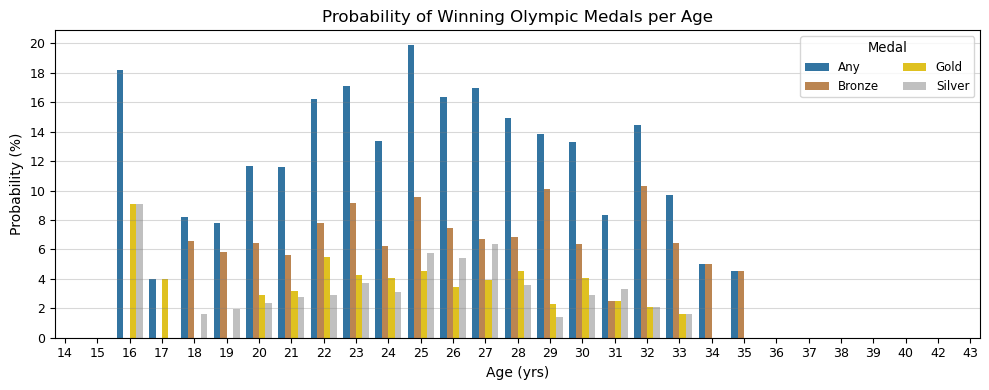

In [92]:
#reorganize the "judo_age_medal" data to make it better for plotting
judo_age_medal_reorg = judo_age_medal.melt(id_vars=['age','Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations'], 
        value_vars=['Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], var_name='Medal', 
        value_name='Prob. (%)').sort_values('Prob. (%)', ascending=False)
#get 5 highest probabilities per age for each distinct medal
for i in ['Bronze','Silver','Gold','Medal']:
    display(judo_age_medal_reorg[judo_age_medal_reorg['Medal'].str.contains(i)].sort_values(
        'Prob. (%)',ascending=False).reset_index(drop=True).head(5))

#make a plot indicating the probability of winning medals per age
plt.figure(figsize=(10,4))
ax1 = sns.barplot(data=judo_age_medal_reorg, x='age', y='Prob. (%)', hue='Medal', 
                  palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'])

#edit plot details
ax1.set(xlim=(-0.3,28.3))
plt.title('Probability of Winning Olympic Medals per Age')
plt.xticks(fontsize=9)
plt.xlabel('Age (yrs)')
plt.ylabel('Probability (%)')
plt.yticks(fontsize=9, ticks=range(0,21,2))
ax1_leg = ax1.get_legend_handles_labels()
plt.legend(handles=ax1_leg[0], labels=['Any','Bronze','Gold','Silver'], title='Medal', title_fontsize=9.5, 
           fontsize=8.5, ncols=2, loc='upper right')
plt.grid(axis='y',alpha=0.3,color='gray')
plt.tight_layout();


The plot above illustrates the probability of winning Olympic medals per age among judo athletes. This data is not normalized based on the number of observations per age which is important to keep in mind (e.g. judo athletes aged 16 won two medals in 11 attempts which is the second largest probability of winning any Olympic medal among judo athletes). No judo athlete aged less than 16 or above 35 years won any medals, so their probabilities of winning medals are zero. Some prominent findings are listed below:
- The five ages with the largest probability of winning bronze medals for judo athletes are 32, 29, 25, 23, & 22 years.
- The five ages with the largest probability of winning silver medals for judo athletes are 16, 27, 25, 26 & 23 years.
- The five ages with the largest probability of winning gold medals for judo athletes are 16, 22, 28, 25, & 23 years.
- The five ages with the largest probability of winning any Olympic medal for judo athletes are 25, 16, 23, 27, & 26 years.

### Age Ranges
Instead of 29 unique age values, 22 age ranges were defined spanning 14-43 years.

In [93]:
#reorganize the "judo_Arange_medal" data to make it better for plotting
judo_Arange_medal_reorg = judo_Arange_medal.melt(id_vars=['Age Range','Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations'], 
        value_vars=['Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], var_name='Medal', 
        value_name='Prob. (%)').sort_values('Prob. (%)', ascending=False).sort_values('Age Range')

#need to change the 'Medal' column to a categorical data type & sort the values specifically so that they are reflected ...
    #consistently in the plot
judo_Arange_medal_reorg['Medal'] = pd.Categorical(judo_Arange_medal_reorg['Medal'], ordered=True,
                                        categories=['Medal Prob. (%)','Bronze Prob. (%)','Gold Prob. (%)','Silver Prob. (%)'])


,Age Range,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,32,2,2,10,14,83,97,Bronze Prob. (%),10.31
1,29,5,3,22,30,187,217,Bronze Prob. (%),10.14
2,25,18,23,38,79,318,397,Bronze Prob. (%),9.57
3,23,15,13,32,60,290,350,Bronze Prob. (%),9.14
4,22,17,9,24,50,258,308,Bronze Prob. (%),7.79


,Age Range,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,14-16,1,1,0,2,11,13,Silver Prob. (%),7.69
1,27,11,18,19,48,235,283,Silver Prob. (%),6.36
2,25,18,23,38,79,318,397,Silver Prob. (%),5.79
3,26,12,19,26,57,292,349,Silver Prob. (%),5.44
4,23,15,13,32,60,290,350,Silver Prob. (%),3.71


,Age Range,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,14-16,1,1,0,2,11,13,Gold Prob. (%),7.69
1,22,17,9,24,50,258,308,Gold Prob. (%),5.52
2,28,14,11,21,46,262,308,Gold Prob. (%),4.55
3,25,18,23,38,79,318,397,Gold Prob. (%),4.53
4,23,15,13,32,60,290,350,Gold Prob. (%),4.29


,Age Range,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,25,18,23,38,79,318,397,Medal Prob. (%),19.90
1,23,15,13,32,60,290,350,Medal Prob. (%),17.14
2,27,11,18,19,48,235,283,Medal Prob. (%),16.96
3,26,12,19,26,57,292,349,Medal Prob. (%),16.33
4,22,17,9,24,50,258,308,Medal Prob. (%),16.23


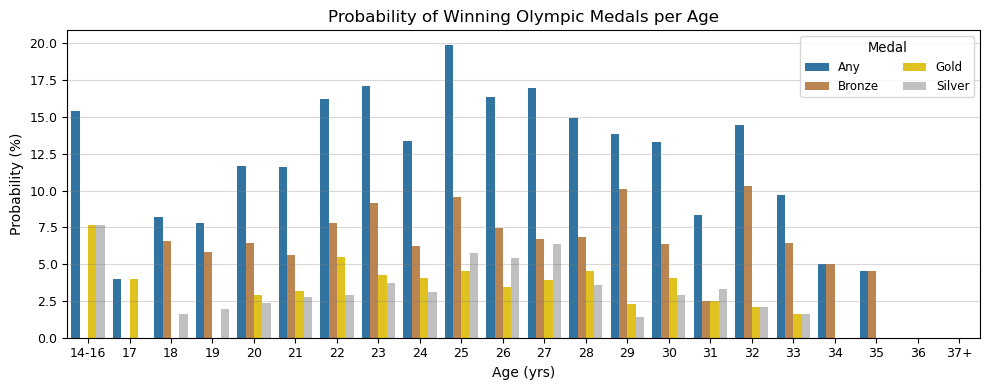

In [94]:
#Get 5 highest probabilities per age-range for each distinct medal & plot probabilities
for i in ['Bronze','Silver','Gold','Medal']:
    display(judo_Arange_medal_reorg[judo_Arange_medal_reorg['Medal'].str.contains(i)].sort_values(
        'Prob. (%)',ascending=False).reset_index(drop=True).head(5))

#make a plot indicating the probability of winning medals per age-range
plt.figure(figsize=(10,4))
ax1 = sns.barplot(data=judo_Arange_medal_reorg, x='Age Range', y='Prob. (%)', hue='Medal', 
                  palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'])

#edit plot details
#ax1.set(xlim=(-0.3,27.3))
plt.title('Probability of Winning Olympic Medals per Age')
plt.xticks(fontsize=9)
plt.xlabel('Age (yrs)')
plt.ylabel('Probability (%)')
plt.yticks(fontsize=9)
ax1_leg = ax1.get_legend_handles_labels()
plt.legend(handles=ax1_leg[0], labels=['Any','Bronze','Gold','Silver'], title='Medal', title_fontsize=9.5, 
           fontsize=8.5, ncols=2, loc='upper right')
plt.grid(axis='y',alpha=0.3,color='gray')
plt.tight_layout();


The plot above illustrates the probability of winning Olympic medals per age among judo athletes. This data is not normalized based on the number of observations per age which is important to keep in mind. Some prominent findings are listed below:
- The five ages with the largest probability of winning bronze medals for judo athletes are 32, 29, 25, 23, & 22 years.
- The five ages with the largest probability of winning silver medals for judo athletes are 14-16, 27, 25, 26, & 23 years.
- The five ages with the largest probability of winning gold medals for judo athletes are 14-16, 22, 28, 25, & 23 years.
- The five ages with the largest probability of winning any Olympic medal for judo athletes are 25, 23, 27, 26, & 22 years.

Between these findings listed above & those of the previous plot (displaying data for each unique age), there are only six differences, one of which is major.

### Height
There are too many unique height values to include them all in a single plot as was done for age. An alternative could be to exclude values in which no medals were won & therefore have medal-winning probabilities of zero, make multiple plots to include more height values & have the plots be legible, enforce a cutoff point to determine the highest probablities, or select the heights which have the most interesting probability data.

In [95]:
#reorganize the "judo_height_medal" data to make it better for plotting
judo_height_medal_reorg = judo_height_medal.melt(id_vars=['height','Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations'], 
        value_vars=['Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], var_name='Medal', 
        value_name='Prob. (%)').sort_values('Prob. (%)', ascending=False)

#need to change the 'Medal' column to a categorical data type & sort the values specifically so that they are reflected ...
    #consistently in the plot
judo_height_medal_reorg['Medal'] = pd.Categorical(judo_height_medal_reorg['Medal'], ordered=True,
                                        categories=['Medal Prob. (%)','Bronze Prob. (%)','Gold Prob. (%)','Silver Prob. (%)'])


,height,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,203,2,0,3,5,1,6,Bronze Prob. (%),50.00
1,197,1,0,2,3,5,8,Bronze Prob. (%),25.00
2,159,1,0,7,8,21,29,Bronze Prob. (%),24.14
3,146,2,2,1,5,0,5,Bronze Prob. (%),20.00
4,161,1,2,7,10,28,38,Bronze Prob. (%),18.42


,height,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,146,2,2,1,5,0,5,Silver Prob. (%),40.00
1,194,0,2,1,3,8,11,Silver Prob. (%),18.18
2,153,0,2,0,2,11,13,Silver Prob. (%),15.38
3,154,2,2,2,6,12,18,Silver Prob. (%),11.11
4,198,0,2,0,2,16,18,Silver Prob. (%),11.11


,height,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,146,2,2,1,5,0,5,Gold Prob. (%),40.00
1,203,2,0,3,5,1,6,Gold Prob. (%),33.33
2,196,3,0,2,5,13,18,Gold Prob. (%),16.67
3,197,1,0,2,3,5,8,Gold Prob. (%),12.50
4,158,6,2,2,10,40,50,Gold Prob. (%),12.00


,height,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,146,2,2,1,5,0,5,Medal Prob. (%),100.00
1,203,2,0,3,5,1,6,Medal Prob. (%),83.33
2,197,1,0,2,3,5,8,Medal Prob. (%),37.50
3,154,2,2,2,6,12,18,Medal Prob. (%),33.33
4,196,3,0,2,5,13,18,Medal Prob. (%),27.78


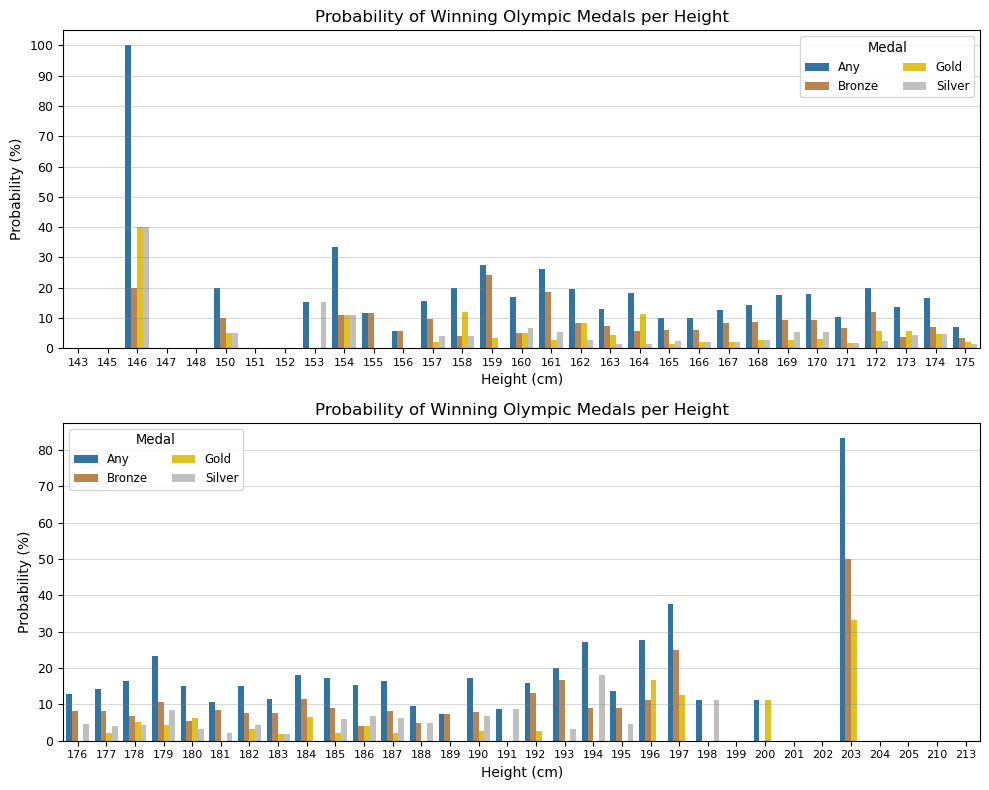

In [96]:
#Get 5 highest probabilities per height for each distinct medal & plot probabilities
for i in ['Bronze','Silver','Gold','Medal']:
    display(judo_height_medal_reorg[judo_height_medal_reorg['Medal'].str.contains(i)].sort_values(
        'Prob. (%)',ascending=False).reset_index(drop=True).head(5))

#need to make multiple plots to make them more legible & easier to analyze
fig, axes = plt.subplots(nrows=2, figsize=(10,8))

#make a plot indicating the probability of winning medals per height
ax1 = sns.barplot(data=judo_height_medal_reorg[judo_height_medal_reorg['height'] < 176], x='height', y='Prob. (%)', hue='Medal', 
                  palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[0])
ax2 = sns.barplot(data=judo_height_medal_reorg[judo_height_medal_reorg['height'] > 175], x='height', y='Prob. (%)', hue='Medal', 
                  palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[1])

#ax1.set(xlim=(-0.3,28.3))
#edit plot details
for key, v in {'1':[0, 101,10], '2':[1, 86,10]}.items():
    plt.sca(axes[v[0]])
    plt.title('Probability of Winning Olympic Medals per Height')
    plt.xticks(fontsize=8)
    plt.xlabel('Height (cm)')
    plt.ylabel('Probability (%)')
    plt.yticks(fontsize=9, ticks=range(0,v[1],v[2]))
    ax1_leg = ax1.get_legend_handles_labels()
    plt.legend(handles=ax1_leg[0], labels=['Any','Bronze','Gold','Silver'], title='Medal', title_fontsize=9.5, 
           fontsize=8.5, ncols=2)
    plt.grid(axis='y',alpha=0.3,color='gray')
    plt.tight_layout();


The plots above illustrate the probability of winning Olympic medals per height among judo athletes. Note that the ranges of the vertical axes across the two plots are not the same. This data is not normalized based on the number of observations per height which is important to keep in mind. Heights with no data/bars indicate that that no medals were won of judo athletes with such heights, implying that those heights have a probability of zero of winning Olympic medals. Some prominent findings are listed below:
- The five heights with the largest probability of winning bronze medals for judo athletes are 203, 197, 159, 146, & 161 centimeters (cm).
- The five heights with the largest probability of winning silver medals for judo athletes are 146, 194, 153, 154, & 198 cm.
- The five heights with the largest probability of winning gold medals for judo athletes are 146, 203, 196, 197, & 158 cm.
- The five heights with the largest probability of winning any Olympic medal for judo athletes are 146, 203, 197, 154, & 196 cm.

### Height Ranges
Instead of 63 unique height values, 49 height ranges were defined spanning 143-213 centimeters.

In [97]:
#reorganize the "judo_Hrange_medal" data to make it better for plotting
judo_Hrange_medal_reorg = judo_Hrange_medal.melt(id_vars=['Height Range','Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations'], 
        value_vars=['Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], var_name='Medal', 
        value_name='Prob. (%)').sort_values('Prob. (%)', ascending=False).sort_values('Height Range')

#need to change the 'Medal' column to a categorical data type & sort the values specifically so that they are reflected ...
    #consistently in the plot
judo_Hrange_medal_reorg['Medal'] = pd.Categorical(judo_Hrange_medal_reorg['Medal'], ordered=True,
                                        categories=['Medal Prob. (%)','Bronze Prob. (%)','Gold Prob. (%)','Silver Prob. (%)'])


,Height Range,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,159,1,0,7,8,21,29,Bronze Prob. (%),24.14
1,161,1,2,7,10,28,38,Bronze Prob. (%),18.42
2,193,0,1,5,6,24,30,Bronze Prob. (%),16.67
3,201+,2,0,3,5,17,22,Bronze Prob. (%),13.64
4,192,1,0,5,6,32,38,Bronze Prob. (%),13.16


,Height Range,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,143-148,2,2,1,5,4,9,Silver Prob. (%),22.22
1,194,0,2,1,3,8,11,Silver Prob. (%),18.18
2,152-153,0,2,0,2,16,18,Silver Prob. (%),11.11
3,154,2,2,2,6,12,18,Silver Prob. (%),11.11
4,191,0,2,0,2,21,23,Silver Prob. (%),8.70


,Height Range,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,143-148,2,2,1,5,4,9,Gold Prob. (%),22.22
1,196,3,0,2,5,13,18,Gold Prob. (%),16.67
2,158,6,2,2,10,40,50,Gold Prob. (%),12.00
3,164,8,1,4,13,58,71,Gold Prob. (%),11.27
4,154,2,2,2,6,12,18,Gold Prob. (%),11.11


,Height Range,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,143-148,2,2,1,5,4,9,Medal Prob. (%),55.56
1,154,2,2,2,6,12,18,Medal Prob. (%),33.33
2,196,3,0,2,5,13,18,Medal Prob. (%),27.78
3,159,1,0,7,8,21,29,Medal Prob. (%),27.59
4,194,0,2,1,3,8,11,Medal Prob. (%),27.27


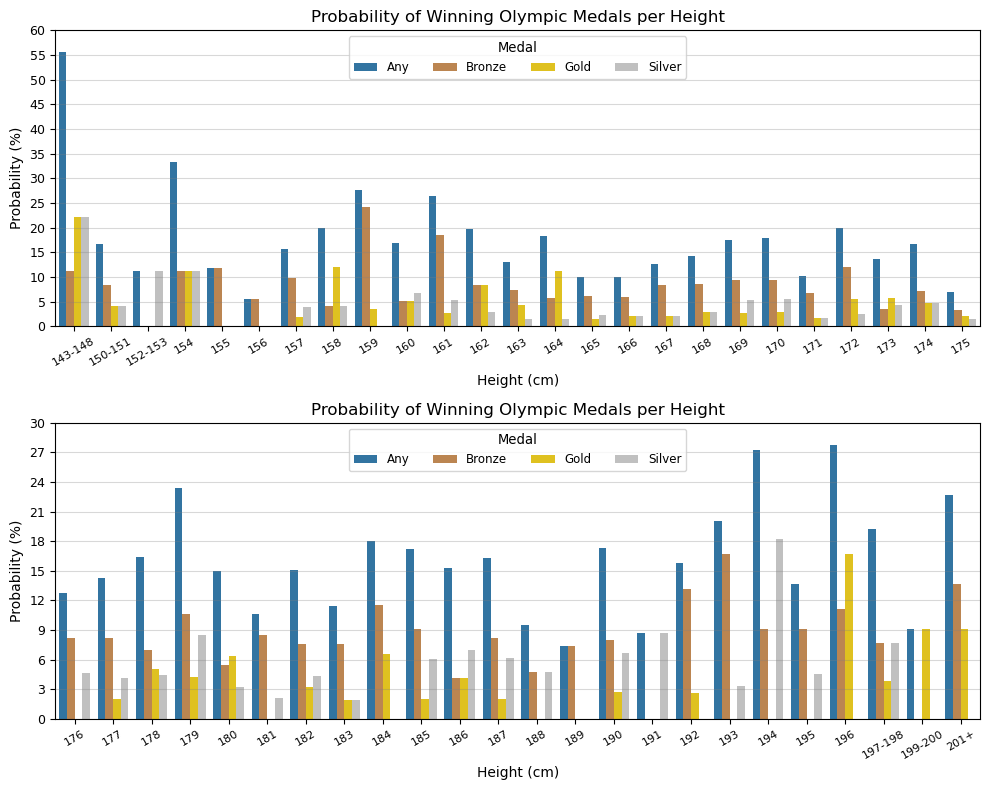

In [98]:
#Get 5 highest probabilities per height-range for each distinct medal & plot probabilities
for i in ['Bronze','Silver','Gold','Medal']:
    display(judo_Hrange_medal_reorg[judo_Hrange_medal_reorg['Medal'].str.contains(i)].sort_values(
        'Prob. (%)',ascending=False).reset_index(drop=True).head(5))

#need to make multiple plots to make them more legible & easier to analyze
fig, axes = plt.subplots(nrows=2, figsize=(10,8))

#make a plot indicating the probability of winning medals per height-range
ax1_heights = judo_Hrange_medal_reorg.reset_index(drop=True).loc[:99,:]['Height Range'].values
ax1 = sns.barplot(data=judo_Hrange_medal_reorg[judo_Hrange_medal_reorg['Height Range'].isin(ax1_heights)], x='Height Range', y='Prob. (%)', hue='Medal', 
                  palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[0])
ax2_heights = judo_Hrange_medal_reorg.reset_index(drop=True).loc[100:,:]['Height Range'].values
ax2 = sns.barplot(data=judo_Hrange_medal_reorg[judo_Hrange_medal_reorg['Height Range'].isin(ax2_heights)], x='Height Range', y='Prob. (%)', hue='Medal', 
                  palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[1])

#edit plot details
ax1.set(xlim=(-0.5,24.5))
ax2.set(xlim=(-0.5,23.5))
for key, v in {'1':[0, 61,5], '2':[1, 31,3]}.items():
    plt.sca(axes[v[0]])
    plt.title('Probability of Winning Olympic Medals per Height')
    plt.xticks(fontsize=8, rotation=30)
    plt.xlabel('Height (cm)')
    plt.ylabel('Probability (%)')
    plt.yticks(fontsize=9, ticks=range(0,v[1],v[2]))
    ax1_leg = ax1.get_legend_handles_labels()
    plt.legend(handles=ax1_leg[0], labels=['Any','Bronze','Gold','Silver'], title='Medal', title_fontsize=9.5, 
           fontsize=8.5, ncols=4, loc='upper center')
    plt.grid(axis='y',alpha=0.3,color='gray')
    plt.tight_layout();


The plot above illustrates the probability of winning Olympic medals per age among judo athletes. Note that the ranges of the vertical axes across the two plots are not the same. This data is not normalized based on the number of observations per height which is important to keep in mind. Some prominent findings are listed below:
- The five heights with the largest probability of winning bronze medals for judo athletes are 159, 161, 193, 201+, & 192 centimeters (cm).
- The five heights with the largest probability of winning silver medals for judo athletes are 143-148, 194, 152-153, 154, & 191 cm.
- The five heights with the largest probability of winning gold medals for judo athletes are 143-148, 196, 158, 164, & 154 cm.
- The five heights with the largest probability of winning any Olympic medal for judo athletes are 143-148, 154, 196, 159, & 194 cm.

Between these findings listed above & those of the previous plot (displaying data for each unique height), there are multiple considerable differences.

### Weight
There are too many unique weight values to include them all in a single plot as was done for age. An alternative could be to exclude values in which no medals were won & therefore have medal-winning probabilities of zero, make multiple plots to include more weight values & have the plots be legible, enforce a cutoff point to determine the highest probablities, or select the weights which have the most interesting probability data.

In [99]:
#reorganize the "judo_weight_medal" data to make it better for plotting
judo_weight_medal_reorg = judo_weight_medal.melt(id_vars=['weight','Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations'], 
        value_vars=['Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], var_name='Medal', 
        value_name='Prob. (%)').sort_values('Prob. (%)', ascending=False)

#need to change the 'Medal' column to a categorical data type & sort the values specifically so that they are reflected ...
    #consistently in the plot
judo_weight_medal_reorg['Medal'] = pd.Categorical(judo_weight_medal_reorg['Medal'], ordered=True,
                                        categories=['Medal Prob. (%)','Bronze Prob. (%)','Gold Prob. (%)','Silver Prob. (%)'])


,weight,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,160.0,0,0,2,2,0,2,Bronze Prob. (%),100.0
1,175.0,0,0,1,1,0,1,Bronze Prob. (%),100.0
2,113.0,0,0,1,1,0,1,Bronze Prob. (%),100.0
3,116.0,0,0,3,3,2,5,Bronze Prob. (%),60.0
4,109.5,0,0,1,1,1,2,Bronze Prob. (%),50.0


,weight,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,126.0,1,1,0,2,0,2,Silver Prob. (%),50.00
1,135.0,0,4,1,5,10,15,Silver Prob. (%),26.67
2,101.0,0,2,2,4,6,10,Silver Prob. (%),20.00
3,104.0,1,3,3,7,10,17,Silver Prob. (%),17.65
4,127.0,1,1,1,3,5,8,Silver Prob. (%),12.50


,weight,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,143.0,2,0,0,2,0,2,Gold Prob. (%),100.00
1,126.0,1,1,0,2,0,2,Gold Prob. (%),50.00
2,139.0,2,0,1,3,1,4,Gold Prob. (%),50.00
3,124.0,1,0,1,2,1,3,Gold Prob. (%),33.33
4,97.0,1,0,0,1,2,3,Gold Prob. (%),33.33


,weight,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,113.0,0,0,1,1,0,1,Medal Prob. (%),100.0
1,175.0,0,0,1,1,0,1,Medal Prob. (%),100.0
2,126.0,1,1,0,2,0,2,Medal Prob. (%),100.0
3,160.0,0,0,2,2,0,2,Medal Prob. (%),100.0
4,143.0,2,0,0,2,0,2,Medal Prob. (%),100.0


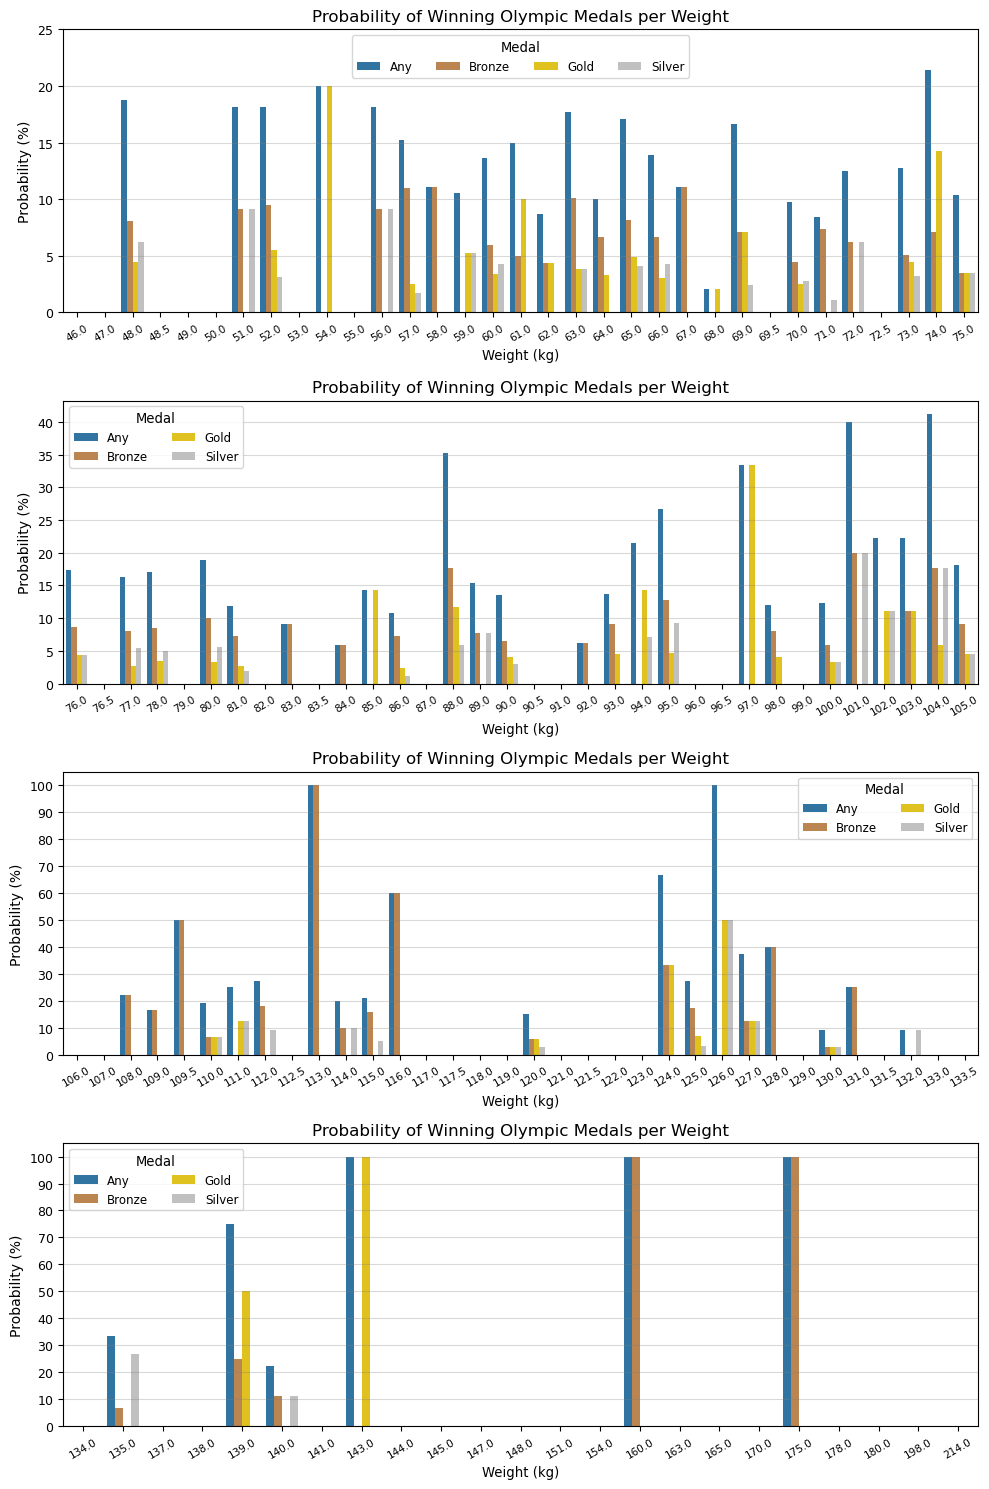

In [100]:
#Get 5 highest probabilities per weight for each distinct medal & plot probabilities
for i in ['Bronze','Silver','Gold','Medal']:
    display(judo_weight_medal_reorg[judo_weight_medal_reorg['Medal'].str.contains(i)].sort_values(
        'Prob. (%)',ascending=False).reset_index(drop=True).head(5))

#need to make multiple plots to make them more legible & easier to analyze
fig, axes = plt.subplots(nrows=4, figsize=(10,15))

#make a plot indicating the probability of winning medals per weight
ax1 = sns.barplot(data=judo_weight_medal_reorg[judo_weight_medal_reorg['weight'] < 76], x='weight', y='Prob. (%)', hue='Medal', 
                  palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[0])
ax2 = sns.barplot(data=judo_weight_medal_reorg[(judo_weight_medal_reorg['weight'] > 75) & (judo_weight_medal_reorg['weight'] < 106)], x='weight', y='Prob. (%)', hue='Medal', 
                  palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[1])
ax3 = sns.barplot(data=judo_weight_medal_reorg[(judo_weight_medal_reorg['weight'] > 105) & (judo_weight_medal_reorg['weight'] < 134)], x='weight', y='Prob. (%)', hue='Medal', 
                  palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[2])
ax4 = sns.barplot(data=judo_weight_medal_reorg[judo_weight_medal_reorg['weight'] >= 134], x='weight', y='Prob. (%)', hue='Medal', 
                  palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[3])

#edit plot details
#ax1.set(xlim=(-0.3,28.3))
for key, v in {'1':[0, 26,5, 4,'upper center'], '2':[1, 45,5, 2,'upper left'], '3':[2, 101,10, 2,'upper right'],
               '4':[3, 101,10, 2,'upper left']}.items():
    plt.sca(axes[v[0]])
    plt.title('Probability of Winning Olympic Medals per Weight')
    plt.xticks(fontsize=7.5, rotation=30)
    plt.xlabel('Weight (kg)', fontsize=9.5)
    plt.ylabel('Probability (%)')
    plt.yticks(fontsize=9, ticks=range(0,v[1],v[2]))
    ax1_leg = ax1.get_legend_handles_labels()
    plt.legend(handles=ax1_leg[0], labels=['Any','Bronze','Gold','Silver'], title='Medal', title_fontsize=9.5, 
           fontsize=8.5, ncols=v[3], loc=v[4])
    plt.grid(axis='y',alpha=0.3,color='gray')
    plt.tight_layout();


The plots above illustrate the probability of winning Olympic medals per weight among judo athletes. Note that the ranges of the vertical axes across the four plots are not the same. This data is not normalized based on the number of observations per weight which is important to keep in mind. Weights with no data/bars indicate that that no medals were won of judo athletes with such weights, implying that those weights have a probability of zero of winning Olympic medals. Some prominent findings are listed below:
- The five weights with the largest probability of winning bronze medals for judo athletes are 160, 175, 113, 116, & 109.5 kilograms (kg).
- The five weights with the largest probability of winning silver medals for judo athletes are 126, 135, 101, 104, & 127 kg.
- The five weights with the largest probability of winning gold medals for judo athletes are 143, 126, 139, 124, & 97 kg.
- The five weights with the largest probability of winning any Olympic medal for judo athletes are 113, 175, 126, 160, & 143 kg.

### Weight Ranges
Instead of 124 unique weight values, 48 weight ranges were defined spanning 46-214 kilograms.

In [101]:
#reorganize the "judo_Wrange_medal" data to make it better for plotting
judo_Wrange_medal_reorg = judo_Wrange_medal.melt(id_vars=['Weight Range','Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations'], 
        value_vars=['Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], var_name='Medal', 
        value_name='Prob. (%)').sort_values('Prob. (%)', ascending=False).sort_values('Weight Range').reset_index(drop=True)

#Need to sort 'Weight Range' because it is currently sorted as an object when it needs to be sorted numerically.
#go through each value of 'Weight Range' & determine how many characters to extract which are necessary for sorting
for i in judo_Wrange_medal_reorg.index:
    #for indices 0-23, 28-39, 44-59, 68-91, get first 3 characters
    if ((i <= 23) or (i >= 28 and i <= 39) or (i >= 44 and i <= 59) or (i >= 68 and i <= 91)):
        judo_Wrange_medal_reorg.loc[i,'weight'] = judo_Wrange_medal_reorg.loc[i,'Weight Range'][:3]
    
    #for indices 24-27, 40-43, 60-67, get first 5 characters
    elif ((i >= 24 and i <= 27) or (i >= 40 and i <= 43) or (i >= 60 and i <= 67)):
        judo_Wrange_medal_reorg.loc[i,'weight'] = judo_Wrange_medal_reorg.loc[i,'Weight Range'][:5]
    
    #for indices 92-155, 160-167, 172-183, 188-207, 212-235, 240-263, get first 2 characters
    elif ((i >= 92 and i <= 155) or (i >= 160 and i <= 167) or (i >= 172 and i <= 183) or (i >= 188 and i <= 207) or 
          (i >= 212 and i <= 235) or (i >= 240)):
        judo_Wrange_medal_reorg.loc[i,'weight'] = judo_Wrange_medal_reorg.loc[i,'Weight Range'][:2]
    
    #for indices 156-159, 168-171, 184-187, 208-211, 236-239, get first 4 characters
    elif ((i >= 156 and i <= 159) or (i >= 168 and i <= 171) or (i >= 184 and i <= 187) or (i >= 208 and i <= 211) or 
          (i >= 236 and i <= 239)):
        judo_Wrange_medal_reorg.loc[i,'weight'] = judo_Wrange_medal_reorg.loc[i,'Weight Range'][:4]
    
    #include measure in case code doesn't work properly
    else:
        judo_Wrange_medal_reorg.loc[i,'weight'] = 'PROBLEM'

#convert the 'weight' column, used to order the 'Weight Range' values, to a numerical data type
judo_Wrange_medal_reorg['weight'] = pd.to_numeric(judo_Wrange_medal_reorg['weight'])

#sort the reorganized dataset by 'weight' & BY 'Medal' -- more effective to make 'Medal' a categorical column
judo_Wrange_medal_reorg = judo_Wrange_medal_reorg.sort_values('weight').reset_index(drop=True)
judo_Wrange_medal_reorg['Medal'] = pd.Categorical(judo_Wrange_medal_reorg['Medal'], ordered=True, 
                                            categories=['Medal Prob. (%)','Bronze Prob. (%)','Gold Prob. (%)','Silver Prob. (%)'])


In [102]:
#verify the loop above works & that it can be sorted on a numerical basis -- GOOD
    #display(judo_Wrange_medal_reorg.sample(10))


,Weight Range,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%),weight
0,115-117,0,1,6,7,18,25,Bronze Prob. (%),24.00,115.0
1,127-128,1,1,3,5,8,13,Bronze Prob. (%),23.08,127.0
2,151-165,0,0,2,2,7,9,Bronze Prob. (%),22.22,151.0
3,101.0,0,2,2,4,6,10,Bronze Prob. (%),20.00,101.0
4,113-114,0,1,2,3,8,11,Bronze Prob. (%),18.18,113.0


,Weight Range,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%),weight
0,101.0,0,2,2,4,6,10,Silver Prob. (%),20.00,101.0
1,133.5-135,0,4,1,5,16,21,Silver Prob. (%),19.05,133.5
2,104.0,1,3,3,7,10,17,Silver Prob. (%),17.65,104.0
3,56.0,0,2,2,4,18,22,Silver Prob. (%),9.09,56.0
4,113-114,0,1,2,3,8,11,Silver Prob. (%),9.09,113.0


,Weight Range,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%),weight
0,137-139,2,0,1,3,7,10,Gold Prob. (%),20.00,137.0
1,94.0,2,1,0,3,11,14,Gold Prob. (%),14.29,94.0
2,85.0,3,0,0,3,18,21,Gold Prob. (%),14.29,85.0
3,74.0,2,0,1,3,11,14,Gold Prob. (%),14.29,74.0
4,143-148,2,0,0,2,12,14,Gold Prob. (%),14.29,143.0


,Weight Range,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%),weight
0,104.0,1,3,3,7,10,17,Medal Prob. (%),41.18,104.0
1,101.0,0,2,2,4,6,10,Medal Prob. (%),40.00,101.0
2,127-128,1,1,3,5,8,13,Medal Prob. (%),38.46,127.0
3,88.0,2,1,3,6,11,17,Medal Prob. (%),35.29,88.0
4,123-126,4,2,6,12,25,37,Medal Prob. (%),32.43,123.0


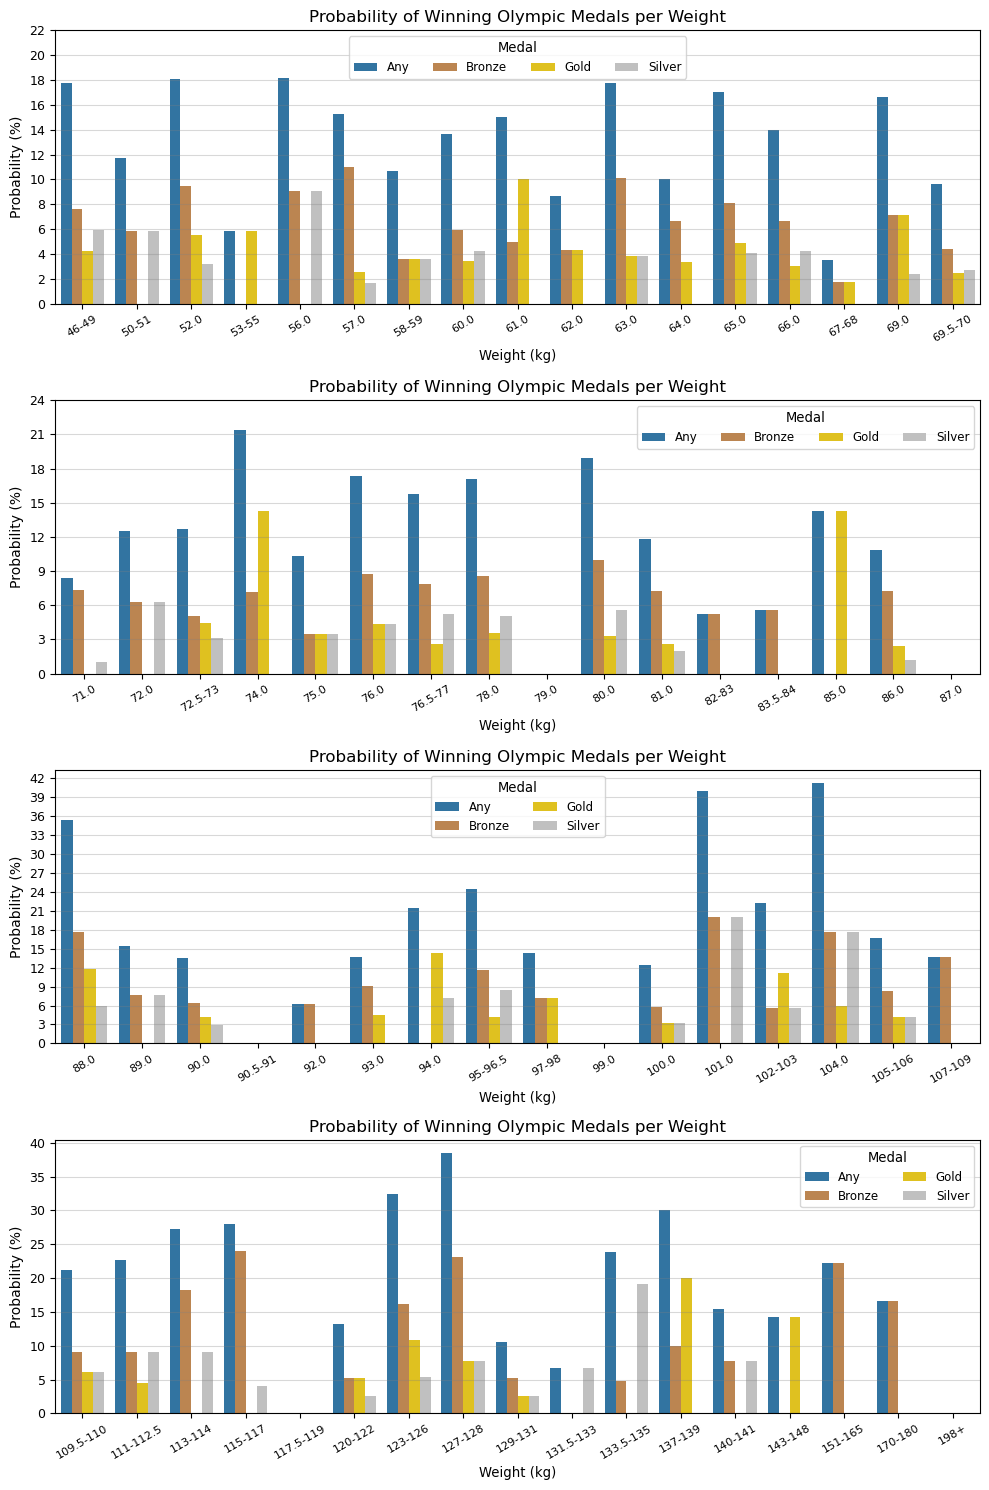

In [103]:
#Get 5 highest probabilities per weight-range for each distinct medal & plot probabilities
for i in ['Bronze','Silver','Gold','Medal']:
    display(judo_Wrange_medal_reorg[judo_Wrange_medal_reorg['Medal'].str.contains(i)].sort_values(
        'Prob. (%)',ascending=False).reset_index(drop=True).head(5))

#need to make multiple plots to make them more legible & easier to analyze
fig, axes = plt.subplots(nrows=4, figsize=(10,15))

#make a plot indicating the probability of winning medals per weight-range
ax1 = sns.barplot(data=judo_Wrange_medal_reorg[judo_Wrange_medal_reorg['weight'] < 71], x='Weight Range', y='Prob. (%)', hue='Medal', 
                  palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[0])
ax2 = sns.barplot(data=judo_Wrange_medal_reorg[(judo_Wrange_medal_reorg['weight'] > 70) & (judo_Wrange_medal_reorg['weight'] < 88)], x='Weight Range', y='Prob. (%)', hue='Medal', 
                  palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[1])
ax3 = sns.barplot(data=judo_Wrange_medal_reorg[(judo_Wrange_medal_reorg['weight'] > 87) & (judo_Wrange_medal_reorg['weight'] <= 109)], x='Weight Range', y='Prob. (%)', hue='Medal', 
                  palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[2])
ax4 = sns.barplot(data=judo_Wrange_medal_reorg[judo_Wrange_medal_reorg['weight'] > 109], x='Weight Range', y='Prob. (%)', hue='Medal', 
                  palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[3])

#edit plot details
for key, v in {'1':[0, 23,2, 4,'upper center'], '2':[1, 25,3, 4,'upper right'], '3':[2, 45,3, 2,'upper center'],
               '4':[3, 41,5, 2,'upper right']}.items():
    plt.sca(axes[v[0]])
    plt.title('Probability of Winning Olympic Medals per Weight')
    plt.xticks(fontsize=8, rotation=30)
    plt.xlabel('Weight (kg)', fontsize=9.5)
    plt.ylabel('Probability (%)')
    plt.yticks(fontsize=9, ticks=range(0,v[1],v[2]))
    ax1_leg = ax1.get_legend_handles_labels()
    plt.legend(handles=ax1_leg[0], labels=['Any','Bronze','Gold','Silver'], title='Medal', title_fontsize=9.5, 
           fontsize=8.5, ncols=v[3], loc=v[4])
    plt.grid(axis='y',alpha=0.3,color='gray')
    plt.tight_layout();


The plot above illustrates the probability of winning Olympic medals per weight among judo athletes. Note that the ranges of the vertical axes across the four plots are not the same. This data is not normalized based on the number of observations per weight which is important to keep in mind. Some prominent findings are listed below:
- The five weights with the largest probability of winning bronze medals for judo athletes are 115-117, 127-128, 151-165, 101, & 113-114 kilograms (kg).
- The five weights with the largest probability of winning silver medals for judo athletes are 101, 133.5-135, 104, 56, & 113-114 kg.
- The five weights with the largest probability of winning gold medals for judo athletes are 137-139, 85, 143-148, 94, & 74 kg.
- The five weights with the largest probability of winning any Olympic medal for judo athletes are 104, 101, 127-128, 88, & 123-126 kg.

Between these findings listed above & those of the previous plot (displaying data for each unique weight), there are multiple considerable differences.

### Nationality / National Olympic Committee (NOC)
There are too many unique noc values to include them all in a single plot as was done for age. An alternative could be to exclude values in which no medals were won & therefore have medal-winning probabilities of zero, make multiple plots to include more noc values & have the plots be legible, enforce a cutoff point to determine the highest probablities, or select the noc's which have the most interesting probability data.

In [104]:
#reorganize the "judo_noc_medal" data to make it better for plotting
judo_noc_medal_reorg = judo_noc_medal.melt(id_vars=['noc','Gold','Silver','Bronze','Medals Won','Medals Not Won','# Observations'], 
        value_vars=['Gold Prob. (%)','Silver Prob. (%)','Bronze Prob. (%)','Medal Prob. (%)'], var_name='Medal', 
        value_name='Prob. (%)').sort_values('Prob. (%)', ascending=False)

#need to change the 'Medal' column to a categorical data type & sort the values specifically so that they are reflected ...
    #consistently in the plot
judo_noc_medal_reorg['Medal'] = pd.Categorical(judo_noc_medal_reorg['Medal'], ordered=True,
                                        categories=['Medal Prob. (%)','Bronze Prob. (%)','Gold Prob. (%)','Silver Prob. (%)'])


,noc,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,URS,5,5,13,23,8,31,Bronze Prob. (%),41.94
1,EST,0,0,3,3,6,9,Bronze Prob. (%),33.33
2,GDR,1,2,6,9,12,21,Bronze Prob. (%),28.57
3,NED,4,2,17,23,61,84,Bronze Prob. (%),20.24
4,JPN,39,19,26,84,45,129,Bronze Prob. (%),20.16


,noc,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,URS,5,5,13,23,8,31,Silver Prob. (%),16.13
1,FRG,1,4,3,8,18,26,Silver Prob. (%),15.38
2,CUB,6,14,16,36,58,94,Silver Prob. (%),14.89
3,JPN,39,19,26,84,45,129,Silver Prob. (%),14.73
4,SVK,0,1,0,1,6,7,Silver Prob. (%),14.29


,noc,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,KOS,1,0,0,1,1,2,Gold Prob. (%),50.00
1,JPN,39,19,26,84,45,129,Gold Prob. (%),30.23
2,URS,5,5,13,23,8,31,Gold Prob. (%),16.13
3,EUN,2,0,2,4,9,13,Gold Prob. (%),15.38
4,FRA,14,10,25,49,86,135,Gold Prob. (%),10.37


,noc,Gold,Silver,Bronze,Medals Won,Medals Not Won,# Observations,Medal,Prob. (%)
0,URS,5,5,13,23,8,31,Medal Prob. (%),74.19
1,JPN,39,19,26,84,45,129,Medal Prob. (%),65.12
2,KOS,1,0,0,1,1,2,Medal Prob. (%),50.00
3,GDR,1,2,6,9,12,21,Medal Prob. (%),42.86
4,CUB,6,14,16,36,58,94,Medal Prob. (%),38.30


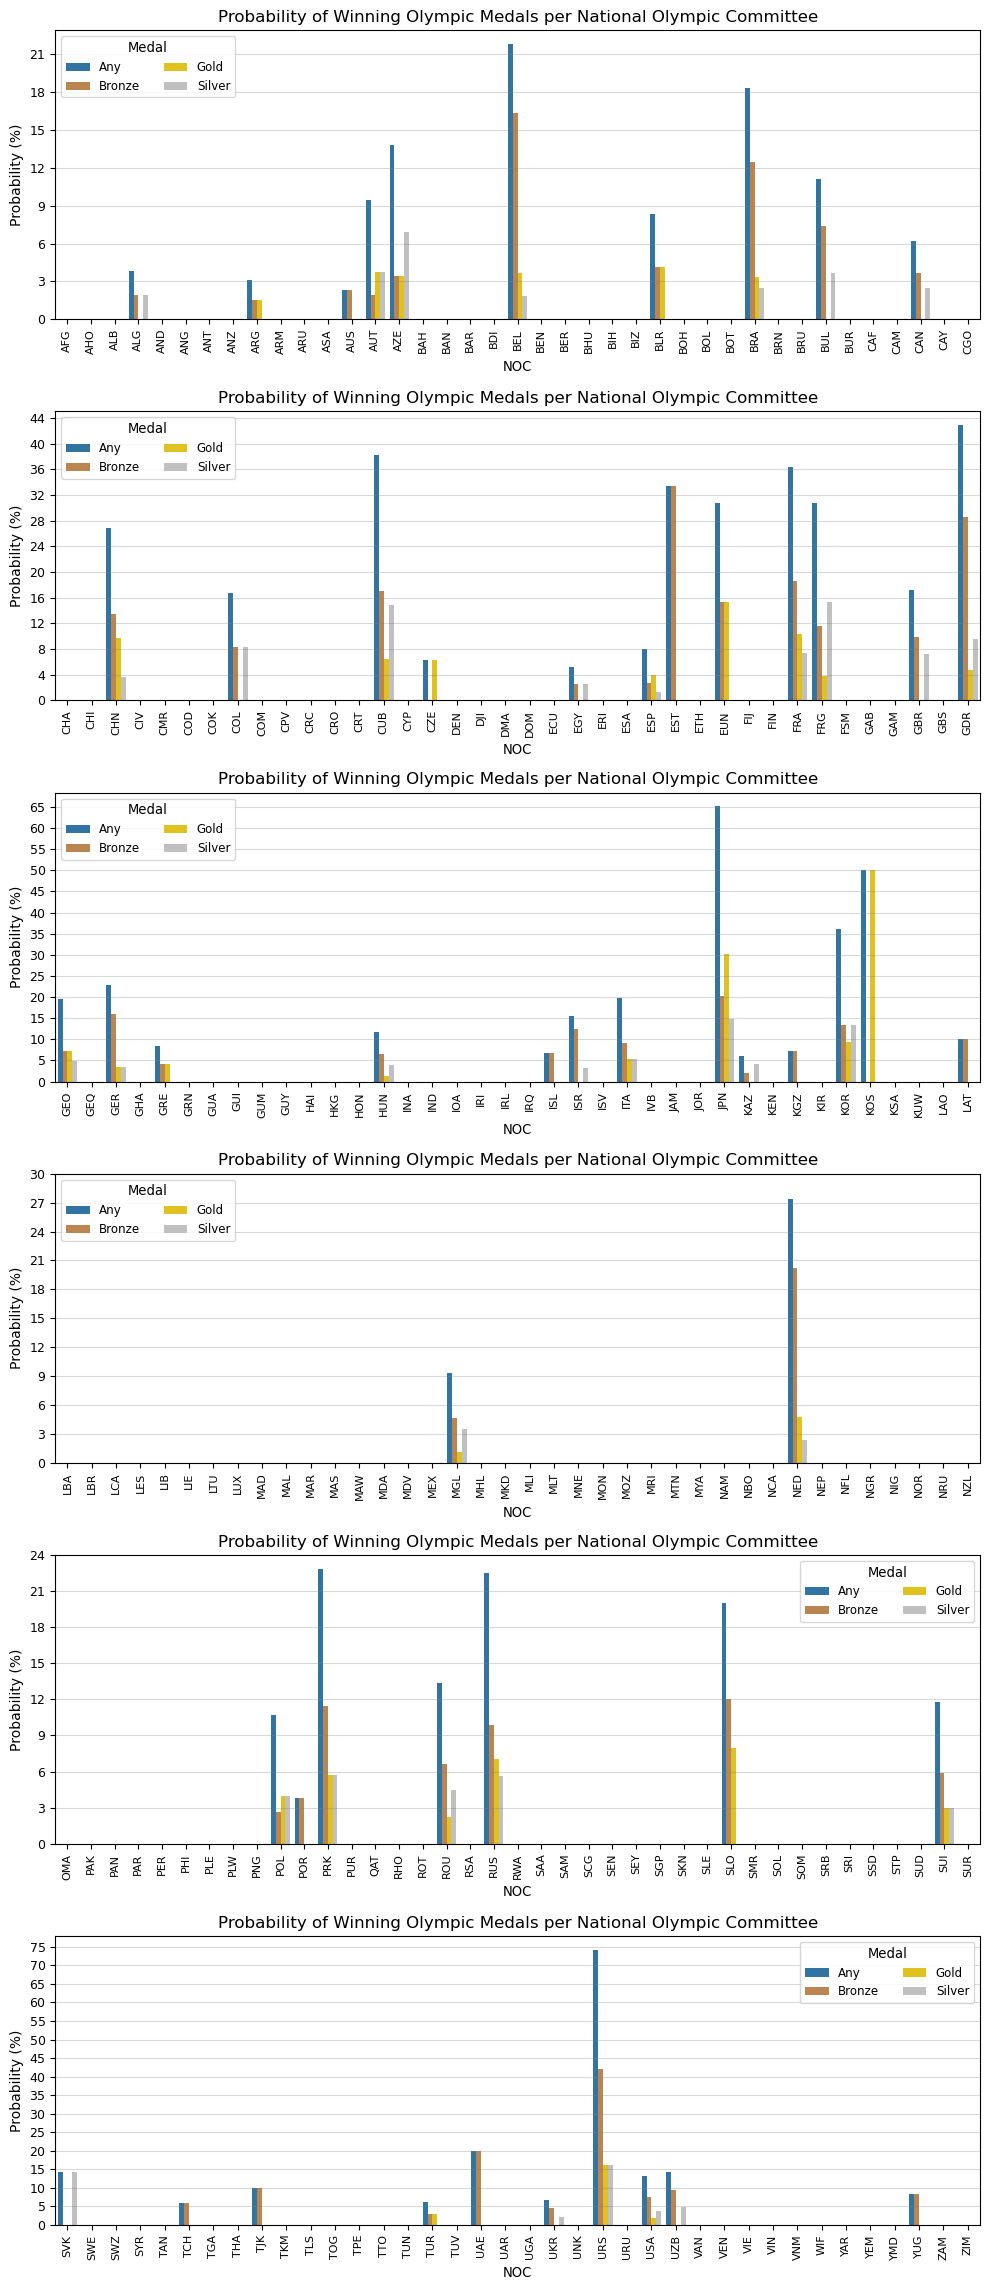

In [105]:
#Get 5 highest probabilities per noc for each distinct medal & plot probabilities
for i in ['Bronze','Silver','Gold','Medal']:
    display(judo_noc_medal_reorg[judo_noc_medal_reorg['Medal'].str.contains(i)].sort_values(
        'Prob. (%)',ascending=False).reset_index(drop=True).head(5))

#need to make multiple plots to make them more legible & easier to analyze
fig, axes = plt.subplots(nrows=6, figsize=(10,23))

#make a plot indicating the probability of winning medals per noc
ax1_nocs = judo_noc_medal.loc[:38,:]['noc'].values
ax1 = sns.barplot(data=judo_noc_medal_reorg[judo_noc_medal_reorg['noc'].isin(ax1_nocs)],
                  x='noc', y='Prob. (%)', hue='Medal', palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[0])
ax2_nocs = judo_noc_medal.loc[39:76,:]['noc'].values
ax2 = sns.barplot(data=judo_noc_medal_reorg[judo_noc_medal_reorg['noc'].isin(ax2_nocs)],
                  x='noc', y='Prob. (%)', hue='Medal', palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[1])
ax3_nocs = judo_noc_medal.loc[77:114,:]['noc'].values
ax3 = sns.barplot(data=judo_noc_medal_reorg[judo_noc_medal_reorg['noc'].isin(ax3_nocs)],
                  x='noc', y='Prob. (%)', hue='Medal', palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[2])
ax4_nocs = judo_noc_medal.loc[115:152,:]['noc'].values
ax4 = sns.barplot(data=judo_noc_medal_reorg[judo_noc_medal_reorg['noc'].isin(ax4_nocs)],
                  x='noc', y='Prob. (%)', hue='Medal', palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[3])
ax5_nocs = judo_noc_medal.loc[153:191,:]['noc'].values
ax5 = sns.barplot(data=judo_noc_medal_reorg[judo_noc_medal_reorg['noc'].isin(ax5_nocs)],
                  x='noc', y='Prob. (%)', hue='Medal', palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[4])
ax6_nocs = judo_noc_medal.loc[192:,:]['noc'].values
ax6 = sns.barplot(data=judo_noc_medal_reorg[judo_noc_medal_reorg['noc'].isin(ax6_nocs)],
                  x='noc', y='Prob. (%)', hue='Medal', palette=[sns.color_palette()[0], 'peru', 'gold', 'silver'], ax=axes[5])

#edit plot details
ax1.set(xlim=(-0.5,38.5))
ax2.set(xlim=(38.5,76.5))
ax3.set(xlim=(76.5,114.5))
ax4.set(xlim=(114.5,152.5))
ax5.set(xlim=(152.5,191.5))
ax6.set(xlim=(191.5,229.5))
for key, v in {'1':[0, 22,3, 'upper left'], '2':[1, 45,4, 'upper left'], '3':[2, 66,5, 'upper left'],
               '4':[3, 31,3, 'upper left'], '5':[4, 26,3, 'upper right'], '6':[5, 76,5, 'upper right']}.items():
    plt.sca(axes[v[0]])
    plt.title('Probability of Winning Olympic Medals per National Olympic Committee')
    plt.xticks(fontsize=8, rotation=90)
    plt.xlabel('NOC', fontsize=9.5)
    plt.ylabel('Probability (%)')
    plt.yticks(fontsize=9, ticks=range(0,v[1],v[2]))
    ax1_leg = ax1.get_legend_handles_labels()
    plt.legend(handles=ax1_leg[0], labels=['Any','Bronze','Gold','Silver'], title='Medal', title_fontsize=9.5, fontsize=8.5,
              ncols=2, loc=v[3])
    plt.grid(axis='y',alpha=0.3,color='gray')
    plt.tight_layout();


The plots above illustrate the probability of winning Olympic medals per noc among judo athletes. Note that the ranges of the vertical axes across the six plots are not the same. This data is not normalized based on the number of observations per noc which is important to keep in mind. National Olympic Committees with no data/bars indicate that that no medals were won of judo athletes that competed under that noc, implying that those Olympic committees have a probability of zero of winning Olympic medals. Some prominent findings are listed below:
- The five nocs with the largest probability of winning bronze medals for judo athletes are **URS** (the Union of Soviet Socialist Republics, a.k.a. the Soviet Union), **EST** (Estonia), **GDR** (the Germany Democratic Republic, a.k.a. East Germany), **NED** (the Netherlands), & **JPN** (Japan).
- The five nocs with the largest probability of winning silver medals for judo athletes are **URS** (the Soviet Union), **FRG** (the Federal Republic of Germany, a.k.a. West Germany), **CUB** (Cuba), **JPN** (Japan), & **SVK** (Slovakia).
- The five nocs with the largest probability of winning gold medals for judo athletes are **KOS** (Kosovo), **JPN** (Japan), **URS** (the Soviet Union), **EUN** (the Unified Team -- the name used for the sports team of the former Soviet Union (except the Baltic states) at the 1992 Winter & Summer Olympic Games. The IOC country code was EUN, after the French name, Équipe unifiée.), & **FRA** (France).
- The five nocs with the largest probability of winning any Olympic medal for judo athletes are **URS** (the Soviet Union), **JPN** (Japan), **KOS** (Kosovo), **GDR** (East Germany), & **CUB** (Cuba).

There is certainly a lot that can be unpacked here across the various noc's that are listed above. Some still exist & compete in the Olympics currently, but many do not including URS, GDR, FRG, & EUN. Of course, external research could add more context to this information, such as the suspicion that East Germany's Olympic success may have been in relation to doping (taking steroids to enhance a competitor's performance), but this process extends beyond what is involved in the primary objectives of this section.

Note that the 'noc' variable is the national Olympic committee in which an athlete competed for, so it doesn't necessarily imply that it is that athlete's national origin.

## Analysis IV - Conclusions
This section constructed probabilities that a judo competitor will earn an Olympic medal based on their height, weight, age, & national origin. Of the approximately 270,000 data points in the main dataset, about 3,800 of them pertain to judo-related events.

A simple understanding of probability is all that is necessary in order to compute such calculations based on between one & four different parameters, which in this case include the variables 'age,' 'height,' 'weight,' & 'noc' ('noc' is the best indicator in the dataset of an athlete's national origin). When multiple events occur, the probability of these combined events can be calculated by finding their product assuming that the events are independent. Independent events are events for which the outcome of one event does not affect the outcome of a second event. For example, if an athlete who is 25 years old competes in one Olympic event on two separate occasions, the outcome of the second competition is independent from the outcome of the first competition.

For example, an athlete who is 22 years old, 170 cm in height, 100 kg in weight, & from France ("FRA" noc), the probability of such an athlete winning a medal can be calculated by finding the probability of each of the four scenarios occurring:
1) The percentage in which a 22-year-old athlete has won a medal,
2) The percentage in which a 170-centimeter-tall athlete has won a medal,
3) The percentage in which a 100-kilogram-weight athlete has won a medal, &
4) The percentage in which an athlete from France has won a medal.

After determining these four probabilities, their product would yield the overall probability of such an athlete winning a medal. If the probability of the four points above are 20%, 10%, 8%, & 15% respectively, the probability of this hypothetical athlete winning a medal would be: 0.2 * 0.1 * 0.08 * 0.15 = 0.00024 or 0.024%. 
This same process can be done in terms of winning a medal generally, but also for winning a specific medal (i.e. Gold, Silver, Bronze). Of course, other parameters can be incorporated into this analysis for judo athletes such as their 'sex' & the host 'city.' Also, these probabilities can be measured over time to see how they evolve.

Though these scenarios are straightforward enough to calculate, they proved to be computationally intensive. Analyzing the distributions of the age, height, weight, & noc parameters of the judo data revealed that there were 29 unique ages, 63 unique heights, 124 unique weights, & 230 unique noc values. If the data of each unique combination across these four parameters was compiled, it would result in over 52 million data points. Multiple methods were trialed in the attempt to compile all of these probabilities including using the `pandas.groupby()` function, creating a nested for loop that goes through every value of each of the four parameters & calculates probabilities, & calculating the probabilities for each value of each parameter separately & then merging the four datasets together from which point the necessary columns would be multiplied to get a total probability for each unique combination of age, height, weight, & noc. Ultimately, these methods proved too strenuous & intensive.

As a result, the process which was used involved calculating the medal-winning probabilities for each unique value of age, height, weight, & noc separately. Then, depending on the values of interest, the probabilities & accompanying data points for each value could be accessed & the probabilities of each could be multiplied together to get a total probability as described in the example above. The four dataframes used were defined as the variables: "judo_age_medal," "judo_height_medal," etc. Each contained several columns that indicated per age/height/weight/noc the number of gold, silver, bronze, & total medals won, the total number of medals not won, the number of observations (data points), & the probabilities (as percentages) of winning a gold, silver, bronze, or any medal.

Furthermore, it was found that this process can be slightly tedious especially for a user who is unfamiliar with the data & code involved. As such, a function was created "judo_athlete_probabilities" to make this process easier. One simply can input an age, height, weight, &/or noc value, & the corresponding data points will be returned including the total medal-winning probabilities. The user should input at least two of the four parameters for this function to be of use. Inputting one parameter would render most of this function meaningless because no calculations would have to be done. Alternatively, for a single parameter, it is only necessary to reference the variable corresponding to the dataset & variable of interest (e.g. "judo_age_medal" for probabilities for specific ages).

A drawback of the method constructed in the `judo_athlete_probabilities` function is that there were many values across the four parameters in which there was no or very little data for which medal-winning probabilities could be calculated from. An alternative could be to use & construct this data via the same method but instead of distinct values for the age, height, & weight parameters, ranges could be used for each of these parameters instead. For example, there are only a handful of judo athletes aged 40 years or older. Instead of applying the `judo_athlete_probabilities` function for a specific age value above 40, the data associated with any judo athlete aged 40 years or more can be used instead, which would produce more results to construct probabilities with. 

This alternative resulted in the `judo_athlete_ranges_probabilities` function which performs the same general function as the `judo_athlete_probabilities` function. The major difficulty when defining these ranges involved a compromise between representativeness & precision. Larger ranges may improve representativeness but will come at a cost to precision, & vice versa for smaller intervals. 
Given how the ranges of age, height, weight were defined, a couple other of functions including `extract_lower_value`, `extract_upper_value`, & `find_AHW_ranges` were created to aid in making this new function as simple to use as possible.

To use the `judo_athlete_ranges_probabilities` function, the age, height, & weight value(s) of interest need to be input into the `find_AHW_ranges` function to determine the specific ranges in which the specified age, height, &/or weight lie within. These values are used inside the `judo_athlete_ranges_probabilities` function along with whatever value of 'noc' may be input. For example, for any specified value(s) of age, height, weight, &/or noc, the code may appear like:
> `judo_athlete_ranges_probabilities(find_AHW_ranges(age, height, weight), noc)`

This function returns the same general data, calculations, & probabilities as the `judo_athlete_probabilities` function does.

Bar plots were constructed to help visualize the medal-winning probabilities of each unique value across these four parameters, for both the distinct-value & ranged-values methods as utilized in the `judo_athlete_probabilities` & `judo_athlete_ranges_probabilities` functions respectively. Some conclusions from these visualizations are listed below.
- **Bronze Medals:**
    - _Age_:
        - The five ages with the largest probability of winning bronze medals for judo athletes are 32, 29, 25, 23, & 22 years.
        - The five age-ranges with the largest probability of winning bronze medals for judo athletes are 32, 29, 25, 23, & 22 years.
    - _Height_:
        - The five heights with the largest probability of winning bronze medals for judo athletes are 203, 197, 159, 146, & 161 centimeters (cm).
        - The five height-ranges with the largest probability of winning bronze medals for judo athletes are 159, 161, 193, 201+, & 192 centimeters (cm).
    - _Weight_:
        - The five weights with the largest probability of winning bronze medals for judo athletes are 160, 175, 113, 116, & 109.5 kilograms (kg).
        - The five weight-ranges with the largest probability of winning bronze medals for judo athletes are 115-117, 127-128, 151-165, 101, & 113-114 kilograms (kg).
    - _NOC_:
        - The five nocs with the largest probability of winning bronze medals for judo athletes are **URS** (the Soviet Union), **EST** (Estonia), **GDR** (East Germany), **NED** (the Netherlands), & **JPN** (Japan).
- **Silver Medals:**
    - _Age_:
        - The five ages with the largest probability of winning silver medals for judo athletes are 16, 27, 25, 26 & 23 years.
        - The five age-ranges with the largest probability of winning silver medals for judo athletes are 14-16, 27, 25, 26, & 23 years.
    - _Height_:
        - The five heights with the largest probability of winning silver medals for judo athletes are 146, 194, 153, 154, & 198 cm.
        - The five height-ranges with the largest probability of winning silver medals for judo athletes are 143-148, 194, 152-153, 154, & 191 cm.
    - _Weight_:
        - The five weights with the largest probability of winning silver medals for judo athletes are 126, 135, 101, 104, & 127 kg.
        - The five weight-ranges with the largest probability of winning silver medals for judo athletes are 101, 133.5-135, 104, 56, & 113-114 kg.
    - _NOC_:
        - The five nocs with the largest probability of winning silver medals for judo athletes are **URS** (the Soviet Union), **FRG** (West Germany), **CUB** (Cuba), **JPN** (Japan), & **SVK** (Slovakia).
- **Gold Medals:**
    - _Age_:
        - The five ages with the largest probability of winning gold medals for judo athletes are 16, 22, 28, 25, & 23 years.
        - The five age-ranges with the largest probability of winning gold medals for judo athletes are 14-16, 22, 28, 25, & 23 years.
    - _Height_:
        - The five heights with the largest probability of winning gold medals for judo athletes are 146, 203, 196, 197, & 158 cm.
        - The five height-ranges with the largest probability of winning gold medals for judo athletes are 143-148, 196, 158, 164, & 154 cm.
    - _Weight_:
        - The five weights with the largest probability of winning gold medals for judo athletes are 143, 126, 139, 124, & 97 kg.
        - The five weight-ranges with the largest probability of winning gold medals for judo athletes are 137-139, 85, 143-148, 94, & 74 kg.
    - _NOC_:
        - The five nocs with the largest probability of winning gold medals for judo athletes are **KOS** (Kosovo), **JPN** (Japan), **URS** (the Soviet Union), **EUN** (the Unified Team / Équipe unifiée -- the name used for the sports team of the former Soviet Union (except the Baltic states) at the 1992 Winter & Summer Olympic Games), & **FRA** (France).
- **Any Medal:**
    - _Age_:
        - The five ages with the largest probability of winning any Olympic medal for judo athletes are 25, 16, 23, 27, & 26 years.
        - The five age-ranges with the largest probability of winning any Olympic medal for judo athletes are 25, 23, 27, 26, & 22 years.
    - _Height_:
        - The five heights with the largest probability of winning any Olympic medal for judo athletes are 146, 203, 197, 154, & 196 cm.
        - The five height-ranges with the largest probability of winning any Olympic medal for judo athletes are 143-148, 154, 196, 159, & 194 cm.
    - _Weight_:
        - The five weights with the largest probability of winning any Olympic medal for judo athletes are 113, 175, 126, 160, & 143 kg.
        - The five weight-ranges with the largest probability of winning any Olympic medal for judo athletes are 104, 101, 127-128, 88, & 123-126 kg.
    - _NOC_:
        - The five nocs with the largest probability of winning any Olympic medal for judo athletes are **URS** (the Soviet Union), **JPN** (Japan), **KOS** (Kosovo), **GDR** (East Germany), & **CUB** (Cuba).


Another important point of consideration to keep in mind is that for the final probabilities, they are calculated across two to four different parameters. Therefore, it is two-to-four times more likely that there is a zero probability in that calculation which would result in the final probability being zero. Such cases, even if they follow the appropriate mathematical calculations, can sometimes be misleading. If one of the specified parameters has very little data, it is more likely that there weren't any instances in which a medal was won. As a result, it will produce a probability of zero & no matter how high the probabilities may be for the other specified parameters, this zero will still cause the final probability to also be zero. On the other hand, if the value of each specified parameter has a considerably representative number of data points yet no medals were won, then the final probability of zero is likely more genuine & realistic.

An example was highlighted earlier in the project (just before the "Illustrate some probabilities" header/section) demonstrating this dilemma. This example simply emphasized that probabilities are statistics & reflective of what has happened in the past. They are not always indicative of what could happen in the future.

These calculations & analyses could be expanded upon by utilizing more features in the main dataset such as athletes' 'sex' & the host 'city.' Also, these probabilities can be measured over time to see how they evolve. The data could also be filtered for athletes that have competed in multiple judo events or multiple Olympic games.

## Research Links
- [How to handle missing values](https://www.linkedin.com/pulse/when-how-handle-missing-inaccurate-values-dataset-machine-abdallah)
- [Symmetrical/Asymmetrical Distributions & Skew](https://www.abs.gov.au/statistics/understanding-statistics/statistical-terms-and-concepts/measures-shape)
- [Olympics - Host Cities](https://en.wikipedia.org/wiki/List_of_Olympic_Games_host_cities)
- [Olympics - 1956](https://en.wikipedia.org/wiki/1956_Summer_Olympics)
- [Judo](https://en.wikipedia.org/wiki/Judo)
- [Olympics - Judo](https://olympics.com/en/news/paris-2024-judo-weight-categories)